O artigo *Rebound in epidemic control: How misaligned vaccination timing amplifies infection peaks* (disponível em https://rdcu.be/d8h0f), publicado em 06/11/2024, versa sobre o rebote do número de infectados em epidemias e a relação disso com a forma como as campanhas de vacinação são realizadas. Utilizando o modelo SIRS, o texto apresenta previsões de rebotes mais acentuados após campanhas que ocorrem dentro de certas janelas de tempo.

Aqui pretendo reproduzir os dados do artigo resolvendo as equações diferenciais numericamente, e também usando modelo de agentes, verificando a validade dos resultados apresentados.

# 1 - Inicializar

## 1.1 - Importando pacotes

In [ ]:
#!pip install os zipfile

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib as mpl
import mpltern
import plotly.express as px
import numpy as np
import pandas as pd
from scipy.optimize import newton, bisect, curve_fit
from scipy.integrate import simpson, odeint, solve_ivp
from scipy.signal import find_peaks, find_peaks_cwt
from scipy.stats import pearsonr
from logging import log
#import ipywidgets as wg
from datetime import datetime, timezone
#import os
from zipfile import ZipFile
import matplotlib.animation as animation
from tqdm.auto import tqdm
import numba as nb

# Gerador de números aleatórios
rng = np.random.default_rng()

## 1.2 - Modelo SIRS

O diferencial do modelo SIRS em comparação com o modelo SIR mais simples, é a possibilidade de reinfecção. Ao longo do tempo, indivídos que já estavam no grupo dos removidos passaram podem voltar ao grupo dos Suscetíveis. Isso é refletido através do term $\delta R$ nas equações do modelo, tal como abaixo

$$ \frac{dS}{dt} = -\beta S I + \delta R $$

$$ \frac{dI}{dt} = \beta S I - \gamma I $$

$$ \frac{dR}{dt} = \gamma I - \delta R $$

Onde $S$, $I$ e $R$ são os grupos de Suscetíveis, infectados e removidos, e $\beta$, $\gamma$ e $\delta$ são a taxa de contato, recuperação e e perda de imunidade, respectivamente. Segundo o artigo, todas as suas operações com as equações acima foram feitas com $\beta > \gamma$, pois do contrário o sistema evolui rapidamente para a erradicação da doença. Também considera-se que o tamanho da população está normalizado, e se concerva segunda a expressão

$$ S(t) + I(t) + R(t) = 1 $$

Uma campanha de vacinação nesse sistema adiciona um termo $\alpha(t)$ nas equações das derivadas de $S$ e $R$, refletindo o efeito da vacina em retirar indivíduos do grupo de Suscetíveis, indo para o grupo dos removidos sem passar pelo estágio de infectado. As equações ficam então da seguinte forma:

$$ \frac{dS}{dt} = -\beta S I + \delta R - \alpha (t) $$

$$ \frac{dI}{dt} = \beta S I - \gamma I $$

$$ \frac{dR}{dt} = \gamma I - \delta R + \alpha (t) $$

O elemento $\alpha(t)$ pode ardquirir diferentes formas. Em um caso mais simples, como uma campanha de vacinação que inicia em um tempo $t_{start}$, se extende até um tempo $t_{stop}$, e durante este período apresenta uma taxa de vacinação da população $\alpha$ (constante), temos a seguinte expressão

$$\alpha(t) = \left\{ \begin{array}{rcl} \alpha & \mbox{para} & t \in [t_{start}, t_{stop}] \\
0 & \mbox{para} & t \notin [t_{start}, t_{stop}] \\ \end{array}\right.$$

Abaixo são definidas as funções do modelo SIRS com campanha de vacinação. Lembrando que para desconsiderar a campanha de vacinação basta devinir o parametro "alpha" como igual a zero.

### 1.2.1 - Funções para simulações

In [ ]:
# Funções com as taxas de variações temporal dos grupos S, I e R
def dS_dt(S, I, R, beta, delta, alpha):
  return -beta*S*I + delta*R - alpha

def dI_dt(S, I, beta, gamma):
  return beta*S*I - gamma*I

def dR_dt(I, R, gamma, delta, alpha):
  return gamma*I - delta*R + alpha


# Funções para gerar valores de taxa de vacinação
def func_alpha(t, t_start, t_stop, alpha_cte):
  if t >= t_start and t <= t_stop:
    return alpha_cte
  else:
    return 0

def func_alpha_fine(t, t_start, S, S_equi, alpha_cte, current_vaccines, h):
  #print(sum([t >= t_start, S > S_equi, current_vaccines > 0]))
  #print([t >= t_start, S > S_equi, current_vaccines > 0])
  #print([S, S_equi])
  if t >= t_start and S > S_equi and current_vaccines > 0:
    return min(current_vaccines/h, alpha_cte)
  else:
    return 0


# Funções para simular epidemias via modelo SIRS (possibilitando vacinação)
# A função normaliza os valores de S, I e R
def SIRS_v(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end):

  t_i = 0
  tt = np.arange(t_i, t_end + h/2, h)

  R_i = N - S_i + I_i

  S_i = S_i/N
  I_i = I_i/N
  R_i = R_i/N

  S_v = [S_i]
  I_v = [I_i]
  R_v = [R_i]

  for j in range(len(tt)-1):

    alpha = func_alpha(tt[j], t_start, t_stop, alpha_cte)
    S_v.append(S_v[j] + dS_dt(S_v[j], I_v[j], R_v[j], beta, delta, alpha)*h)
    I_v.append(I_v[j] + dI_dt(S_v[j], I_v[j], beta, gamma)*h)
    R_v.append(R_v[j] + dR_dt(I_v[j], R_v[j], gamma, delta, alpha)*h)

  return tt, np.array(S_v), np.array(I_v), np.array(R_v)

SIRS_v_vec = np.vectorize(SIRS_v,
                          signature='(),(),(),(),(),(),(),(),(),(),()->(n),(n),(n),(n)')

# Função para simular epidemias via modelo SIRS com vacinação (ajuste fino)
def SIRS_v_fine(N, S_i, I_i, beta, gamma, delta, t_start, total_vaccines, alpha_cte, h, t_end):

  t_i = 0
  tt = np.arange(t_i, t_end + h/2, h)

  R_i = N - S_i + I_i

  S_i = S_i/N
  I_i = I_i/N
  R_i = R_i/N

  S_v = [S_i]
  I_v = [I_i]
  R_v = [R_i]

  S_equi = gamma/beta
  current_vaccines = total_vaccines
  t_stop = -1

  for j in range(len(tt)-1):

    alpha = func_alpha_fine(tt[j], t_start, S_v[j], S_equi, alpha_cte, current_vaccines, h)
    #print(alpha)
    S_v.append(S_v[j] + dS_dt(S_v[j], I_v[j], R_v[j], beta, delta, alpha)*h)
    I_v.append(I_v[j] + dI_dt(S_v[j], I_v[j], beta, gamma)*h)
    R_v.append(R_v[j] + dR_dt(I_v[j], R_v[j], gamma, delta, alpha)*h)

    current_vaccines -= alpha*h
    if current_vaccines <= 0 and t_stop < 0:
    #if current_vaccines <= 0 and 't_stop' not in locals():
        t_stop = tt[j]

  if t_stop == -1:
      t_stop = tt[-1]

  return tt, np.array(S_v), np.array(I_v), np.array(R_v), t_stop
    

# Diferente da função anterior, esta só muda os valores de uma lista já criada
def SIRS_v2(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end):

  t_i = 0
  tt = np.arange(t_i, t_end + h/2, h)
  tt_len = len(tt)

  R_i = N - S_i + I_i

  S_i = S_i/N
  I_i = I_i/N
  R_i = R_i/N

  S_v = [S_i]*tt_len
  I_v = [I_i]*tt_len
  R_v = [R_i]*tt_len

  for j in range(tt_len-1):

    alpha = func_alpha(tt[j], t_start, t_stop, alpha_cte)
    S_v[j+1] = (S_v[j] + dS_dt(S_v[j], I_v[j], R_v[j], beta, delta, alpha)*h)
    I_v[j+1] = (I_v[j] + dI_dt(S_v[j], I_v[j], beta, gamma)*h)
    R_v[j+1] = (R_v[j] + dR_dt(I_v[j], R_v[j], gamma, delta, alpha)*h)

  return tt, S_v, I_v, R_v


def SIRS_v3(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end):

  t_i = 0
  tt = np.arange(t_i, t_end + h/2, h)

  R_i = N - S_i - I_i

  S_i = S_i/N
  I_i = I_i/N
  R_i = R_i/N

  #Listas para valores do modelo sem campanha de vacinação
  S = [S_i]
  I = [I_i]
  R = [R_i]

  #Listas para valores do modelo com campanha de vacinação
  S_v = [S_i]
  I_v = [I_i]
  R_v = [R_i]

  for j in range(np.shape(tt)[0]-1):
    S.append(S[j] + dS_dt(S[j], I[j], R[j], beta, delta, 0.0)*h)
    I.append(I[j] + dI_dt(S[j], I[j], beta, gamma)*h)
    R.append(R[j] + dR_dt(I[j], R[j], gamma, delta, 0.0)*h)

    alpha = func_alpha(tt[j], t_start, t_stop, alpha_cte)
    S_v.append(S_v[j] + dS_dt(S_v[j], I_v[j], R_v[j], beta, delta, alpha)*h)
    I_v.append(I_v[j] + dI_dt(S_v[j], I_v[j], beta, gamma)*h)
    R_v.append(R_v[j] + dR_dt(I_v[j], R_v[j], gamma, delta, alpha)*h)

  #Transformar listas em arrays
  S, I, R = np.array(S), np.array(I), np.array(R)
  S_v, I_v, R_v = np.array(S_v), np.array(I_v), np.array(R_v)

  return tt, S, I, R, S_v, I_v, R_v

# Função que guardar em um lugar só todas as derivadas. Necessária para a função scipy.odeint
def deriv(t, y, beta, gamma, delta, t_start, t_stop, alpha_cte):
  S, I, R = y
  alpha = func_alpha(t, t_start, t_stop, alpha_cte)
  dsdt = dS_dt(S, I, R, beta, delta, alpha)
  didt = dI_dt(S, I, beta, gamma)
  drdt = dR_dt(I, R, gamma, delta, alpha)
  return dsdt, didt, drdt

# Função para calcular valores de S, I e R após t_stop pelos métodos analíticos
def analitic_post_vac(tt, S_v, I_v, R_v, beta, gamma, delta, t_stop):

  #Encontrar valor de Suscetíveis, infectados e removidos em t_stop
  t_stop_condition = (tt >= t_stop)
  tt_stop_end = tt[t_stop_condition]
  S_stop = S_v[t_stop_condition][0]
  I_stop = I_v[t_stop_condition][0]
  R_stop = R_v[t_stop_condition][0]

  term1 = -delta*(tt_stop_end - t_stop)

  #Calcular série dos infectados
  I_stop_end = I_stop * np.exp((beta-gamma) * (tt_stop_end - t_stop) - (beta*R_stop/delta)*(1-np.exp(term1)))

  #Limitar os próximos calculos ao tempo t_p
  break_condition = (I_stop_end <= (1 - gamma/beta))
  tt_stop_end = tt_stop_end[break_condition]
  I_stop_end = I_stop_end[break_condition]
  term1 = -delta*(tt_stop_end - t_stop)
  t_p = tt_stop_end[-1]

  #Calcular R
  integral_values = np.array([simpson(np.exp(term1[:i+1])*I_stop_end[:i+1], x=tt_stop_end[:i+1]) for i in range(len(tt_stop_end))])
  estim_dif_R =  gamma * integral_values
  R_stop_end = R_stop * np.exp(term1) + estim_dif_R

  #Calcular S
  estim_dif_S = - (I_stop_end + estim_dif_R)
  S_stop_end = 1- R_stop * np.exp(term1) + estim_dif_S

  return tt_stop_end, S_stop_end, I_stop_end, R_stop_end

def stationary(beta, gamma, delta):

  S_stat = gamma/beta
  I_stat = (1 - gamma/beta)*(delta/(gamma+delta))
  R_stat = (1 - gamma/beta)*(gamma/(gamma+delta))

  return S_stat, I_stat, R_stat

def alpha_erradication(R_0, delta):
    return (1-1/R_0)*delta

# Função realizar de várias simulações via metodo de euler
def func_sim_euler(N, S_i, I_i, params, h, t_end):

  N_sims = len(params)
  N_steps = int(t_end/h + 1)

  S_list = np.empty((N_sims, N_steps), dtype=np.float64)
  I_list = np.empty((N_sims, N_steps), dtype=np.float64)
  R_list = np.empty((N_sims, N_steps), dtype=np.float64)

  for i in tqdm(range(N_sims)):

      b, r_0, d, t_sa, t_so, a, n = params[i]
      g = b/r_0

      # Coletar arrays da simulação e adicionar na lista
      tt, S, I, R = SIRS_v(N, S_i, I_i, b, g, d, t_sa, t_so, a, h, t_end)

      S_list[i, :] = S
      I_list[i, :] = I
      R_list[i, :] = R

  return params, S_list, I_list, R_list

# Função realizar de várias simulações via metodo de euler
# simulações com ajuste fino de campanha de vacinação
def func_sim_euler_fine(N, S_i, I_i, params, h, t_end):

  N_sims = len(params)
  N_steps = int(t_end/h + 1)

  S_list = np.empty((N_sims, N_steps), dtype=np.float64)
  I_list = np.empty((N_sims, N_steps), dtype=np.float64)
  R_list = np.empty((N_sims, N_steps), dtype=np.float64)
  t_stop_list = np.empty(N_sims, dtype=np.float64)

  for i in tqdm(range(N_sims)):

      b, r_0, d, t_sa, tot_v, a, n = params[i]
      g = b/r_0

      # Coletar arrays da simulação e adicionar na lista
      tt, S, I, R, t_so = SIRS_v_fine(N, S_i, I_i, b, g, d, t_sa, tot_v, a, h, t_end)

      S_list[i, :] = S
      I_list[i, :] = I
      R_list[i, :] = R
      t_stop_list[i] = t_so

  return params, S_list, I_list, R_list, t_stop_list


# Função realizar de várias simulações com a função odeint
def func_sim_odeint(N, S_i, I_i, params, h, t_end):

  N_sims = len(params)
  N_steps = int(t_end/h + 1)

  S_list = np.empty((N_sims, N_steps), dtype=np.float64)
  I_list = np.empty((N_sims, N_steps), dtype=np.float64)
  R_list = np.empty((N_sims, N_steps), dtype=np.float64)

  # Set variables to odeint case
  tt = np.linspace(0, t_end, N_steps)
  R_i = N - S_i - I_i
  S_i, I_i, R_i = S_i/N, I_i/N, R_i/N
  y0 = S_i, I_i, R_i

  for i in tqdm(range(N_sims)):

      b, r_0, d, t_sa, t_so, a, n = params[i]
      g = b/r_0

      # Coletar arrays da simulação e adicionar na lista
      S, I, R = odeint(deriv, y0, tt, args=(b, g, d, t_sa, t_so, a), tfirst=True, atol = 1e-30).T

      S_list[i, :] = S
      I_list[i, :] = I
      R_list[i, :] = R

  return params, S_list, I_list, R_list

# Função para escolher entre metodos de geração de simulações
def func_sim(N, S_i, I_i, params, h, t_end, mode):
    match mode:
        case 'euler':
            return func_sim_euler(N, S_i, I_i, params, h, t_end)
        case 'euler_fine':
            return func_sim_euler_fine(N, S_i, I_i, params, h, t_end)
        case 'odeint':
            return func_sim_odeint(N, S_i, I_i, params, h, t_end)
        case 'agents':
            return func_sim_agents_numba(N, S_i, I_i, params, h, t_end)
        


### 1.2.2 - Modelo de agentes

In [ ]:
class model_agents():

  def __init__(self, n_agents, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha, h):
    # Create object properties
    self.n_agents = n_agents
    self.beta = beta
    self.gamma = gamma
    self.delta = delta
    self.t_start = t_start
    self.t_stop = t_stop
    self.alpha = alpha
    self.h = h

    # Create list with groups values
    R_i = n_agents - S_i - I_i
    self.S_serie = [S_i]
    self.I_serie = [I_i]
    self.R_serie = [R_i]
    self.t_serie = [0]

    # Create agents
    state = np.array(['S']*S_i + ['I']*I_i + ['R']*R_i)
    self.agents = state


  def evolve(self):

    # Get index of agents in different groups
    agents_temp = self.agents

    sus_index = np.where(agents_temp == 'S')[0]
    inf_index = np.where(agents_temp == 'I')[0]
    rem_index = np.where(agents_temp == 'R')[0]

    # Change suseptible into infected and removed
    inf_probability = self.beta * len(inf_index)/self.n_agents * self.h
    if self.t_serie[-1] > self.t_start and self.t_serie[-1] < self.t_stop:
      rem_probability = self.alpha * self.n_agents/len(sus_index) * self.h
    else:
      rem_probability = 0

    if inf_probability + rem_probability > 1:
      inf_probability = inf_probability/(inf_probability+rem_probability)
      rem_probability = 1 - inf_probability

    sus_prob_list = [inf_probability, rem_probability, 1-inf_probability-rem_probability]
    suscepted = rng.choice(['I', 'R', 'S'], size=len(sus_index), p=sus_prob_list)
    agents_temp[sus_index] = suscepted

    # Change infected into removed
    rem_probability = self.gamma * self.h
    change_condition = rng.uniform(0, 1, len(inf_index)) <= rem_probability
    infected = np.where(change_condition, 'R', 'I')
    agents_temp[inf_index] = infected

    # Change removed into suceptible
    sus_probability = self.delta * self.h
    change_condition = rng.uniform(0, 1, len(rem_index)) <= sus_probability
    removed = np.where(change_condition, 'S', 'R')
    agents_temp[rem_index] = removed

    self.agents = agents_temp


  def step(self):

    self.evolve()

    states = self.agents
    S = np.sum(states == 'S')
    I = np.sum(states == 'I')
    R = np.sum(states == 'R')

    self.S_serie.append(S)
    self.I_serie.append(I)
    self.R_serie.append(R)
    self.t_serie.append(self.t_serie[-1]+self.h)


class model_agents_gpu():

  def __init__(self, n_agents, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha, h):
    # Create object properties
    self.n_agents = n_agents
    self.beta = beta
    self.gamma = gamma
    self.delta = delta
    self.t_start = t_start
    self.t_stop = t_stop
    self.alpha = alpha
    self.h = h

    # Create list with groups values
    R_i = n_agents - S_i - I_i
    self.S_serie = [S_i]
    self.I_serie = [I_i]
    self.R_serie = [R_i]
    self.t_serie = [0]

    # Create agents
    state = cp.array([0]*S_i + [1]*I_i + [2]*R_i)
    self.agents = state


  def evolve(self):

    # Get index of agents in different groups
    agents_temp = self.agents

    sus_index = cp.where(agents_temp == 0)[0]
    inf_index = cp.where(agents_temp == 1)[0]
    rem_index = cp.where(agents_temp == 2)[0]

    # Change suseptible into infected and removed
    inf_probability = self.beta * len(inf_index)/self.n_agents * self.h
    if self.t_serie[-1] > self.t_start and self.t_serie[-1] < self.t_stop:
      rem_probability = self.alpha * self.n_agents/len(sus_index) * self.h
    else:
      rem_probability = 0
    sus_prob_list = [inf_probability, rem_probability, 1-inf_probability-rem_probability]
    suscepted = rng.choice([1, 2, 0], size=len(sus_index), p=sus_prob_list)
    agents_temp[sus_index] = suscepted

    # Change infected into removed
    rem_probability = self.gamma * self.h
    change_condition = rng.uniform(0, 1, len(inf_index)) <= rem_probability
    infected = cp.where(cp.asarray(change_condition), 2, 1)
    agents_temp[inf_index] = infected

    # Change removed into suceptible
    sus_probability = self.delta * self.h
    change_condition = rng.uniform(0, 1, len(rem_index)) <= sus_probability
    removed = cp.where(cp.asarray(change_condition), 0, 2)
    agents_temp[rem_index] = removed

    self.agents = agents_temp


  def step(self):

    self.evolve()

    states = self.agents
    S = cp.sum(states == 0)
    I = cp.sum(states == 1)
    R = cp.sum(states == 2)

    self.S_serie.append(S)
    self.I_serie.append(I)
    self.R_serie.append(R)
    self.t_serie.append(self.t_serie[-1]+self.h)


def final_state(data):
  resum = np.unique(data, return_counts=True)
  print('\nEstado final do sistema:')
  for k in range(len(resum[0])):
    print('{} = {}'.format(resum[0][k], resum[1][k]))


def get_series(system, normalized = True):

  tt = np.array(system.t_serie)

  if normalized:

    S = np.array(system.S_serie)/system.n_agents
    I = np.array(system.I_serie)/system.n_agents
    R = np.array(system.R_serie)/system.n_agents

  else:

    S = np.array(system.S_serie)
    I = np.array(system.I_serie)
    R = np.array(system.R_serie)

  return tt, S, I, R


def get_series_gpu(system, normalized = True):

  tt = np.array(system.t_serie)

  system.S_serie[0] = cp.array(system.S_serie[0])
  system.I_serie[0] = cp.array(system.I_serie[0])
  system.R_serie[0] = cp.array(system.R_serie[0])

  if normalized:

    S = cp.asnumpy(cp.array(system.S_serie))/system.n_agents
    I = cp.asnumpy(cp.array(system.I_serie))/system.n_agents
    R = cp.asnumpy(cp.array(system.R_serie))/system.n_agents

  else:

    S = np.array(system.S_serie)
    I = np.array(system.I_serie)
    R = np.array(system.R_serie)

  return tt, S, I, R




### 1.2.3 - Modelo de agentes com Numba

In [ ]:
spec = [('n_agents', nb.i8), ('S_i', nb.i8), ('I_i', nb.i8),
        ('beta', nb.f8), ('mu', nb.f8), ('delta', nb.f8),
        ('t_start', nb.f8), ('t_stop', nb.f8), ('alpha', nb.f8), ('h', nb.f8),
        ('S_serie', nb.types.ListType(nb.types.int64)),
        ('I_serie', nb.types.ListType(nb.types.int64)),
        ('R_serie', nb.types.ListType(nb.types.int64)),
        ('t_serie', nb.types.ListType(nb.types.float64)),
        ('agents', nb.i8[:])]

@nb.experimental.jitclass(spec)
class model_agents_numba():

  def __init__(self, n_agents, S_i, I_i, beta, mu, delta, t_start, t_stop, alpha, h):
    # Create object properties
    self.n_agents = n_agents
    self.beta = beta
    self.mu = mu
    self.delta = delta
    self.t_start = t_start
    self.t_stop = t_stop
    self.alpha = alpha
    self.h = h

    # Create list with groups values
    R_i = n_agents - S_i - I_i
    self.S_serie = nb.typed.List([S_i])
    self.I_serie = nb.typed.List([I_i])
    self.R_serie = nb.typed.List([R_i])
    self.t_serie = nb.typed.List([0.0])

    # Create agents
    state = np.array([0]*S_i + [1]*I_i + [2]*R_i)
    self.agents = state

  def evolve(self):

    # Get index of agents in different groups
    agents_temp = self.agents

    sus_index = np.where(agents_temp == 0)[0]
    inf_index = np.where(agents_temp == 1)[0]
    rem_index = np.where(agents_temp == 2)[0]

    # Change suseptible into infected and removed
    inf_probability = self.beta * len(inf_index)/self.n_agents * self.h
    if self.t_serie[-1] > self.t_start and self.t_serie[-1] < self.t_stop:
      rem_probability = self.alpha * self.n_agents/len(sus_index) * self.h
    else:
      rem_probability = 0
    x = np.random.uniform(0,1,len(sus_index))
    cond_list = [x <= inf_probability, x <= inf_probability + rem_probability]
    suscepted = np.where(cond_list[0], 1, np.where(cond_list[1], 2, 0))
    agents_temp[sus_index] = suscepted

    # Change infected into removed
    rem_probability = self.mu * self.h
    change_condition = np.random.uniform(0, 1, len(inf_index)) <= rem_probability
    infected = np.where(change_condition, 2, 1)
    agents_temp[inf_index] = infected

    # Change removed into suceptible
    sus_probability = self.delta * self.h
    change_condition = np.random.uniform(0, 1, len(rem_index)) <= sus_probability
    removed = np.where(change_condition, 0, 2)
    agents_temp[rem_index] = removed

    self.agents = agents_temp


  def step(self, steps):

    for _ in range(steps):

      self.evolve()

      states = self.agents

      S = np.sum(states == 0)
      I = np.sum(states == 1)
      R = np.sum(states == 2)

      self.S_serie.append(S)
      self.I_serie.append(I)
      self.R_serie.append(R)
      self.t_serie.append(self.t_serie[-1]+self.h)


  def get_series(self):

    tt = np.asarray(self.t_serie)
    SS = np.asarray(self.S_serie)/self.n_agents
    II = np.asarray(self.I_serie)/self.n_agents
    RR = np.asarray(self.R_serie)/self.n_agents

    return tt, SS, II, RR


Testar o modelo de agentes. É interessante rodar uma vez antes de começar a usar. Programas compilados com Numba costumam ser mais lentos em sua primeira execusão.

In [ ]:
# Parâmetros
n_agents, S_i = 100000, 99500
I_i = n_agents - S_i # Consequentemente, R_i = 0

beta, mu, delta = 0.5, 0.125, 0.01

h, t_end = 1.0, 1250

t_start, t_stop, alpha = 80, 160, 0.008 # Para a campanha de vacinação

# Criar sistema
teste_numba = model_agents_numba(n_agents, S_i, I_i, beta, mu, delta, t_start, t_stop, alpha, h)
# Evoluir epidemia
teste_numba.step(int(t_end/h))
# Imprimir últimos valores dos grupos, 0 = S, 1 = I, 2 = R
final_state(teste_numba.agents)

A função abaixo executa multiplas simulações, por isso é esperado que os valores dos parâmetros $\beta$, $R_0$, $\delta$, $t_{start}$, $t_{stop}$ e $\alpha$ sejam do tipo **numpy.array**. Se esses arrays tiverem multiplos valores diferentes, seram geras simulações para todas as combinações de parâmetros possíveis. Por essa razão estou trabalhando aqui com $R_0$ ao invés de $\gamma$, pois assim é simples assigurar que a maior parte das simulações levem de fato ao estabeleimento de uma epidemia, e não decaiam até a extinção logo no início da simulação sempre que $R_0 < 1$.

O parâmetro **sample_size** define quantas repetições de cada simulação serão realizadas. A função retorna quatro arrays, um com as combinações de parametros utilizadas, na orde [$\beta$, $R_0$, $\delta$, $t_{start}$, $t_{stop}$, $\alpha$, $n$], onde $n$ é o número da repetição, partindo de zero. Caso seja feita somente uma repetição para cada combinação de parêmetros, então $n = 0$ em todos os casos, para duas repetições, teremos $n = 0$ e $n = 1$, e assim por diante.

In [ ]:
@nb.jit('Tuple((f8[:,:], f8[:,:], f8[:,:], f8[:,:]))'
        '(i8, i8, i8, f8[:,:], f8, f8)',
        nopython = True, parallel = True)
def func_sim_agents_numba(N, S_i, I_i, params, h, t_end):

  N_sims = len(params)
  N_steps = int(t_end/h + 1)

  S_list = np.empty((N_sims, N_steps), dtype=np.float64)
  I_list = np.empty((N_sims, N_steps), dtype=np.float64)
  R_list = np.empty((N_sims, N_steps), dtype=np.float64)

  for i in nb.prange(N_sims):

      b, r_0, d, t_sa, t_so, a, n = params[i]
      g = b/r_0

      epi_agents_v = model_agents_numba(N, S_i, I_i, b, g, d, t_sa, t_so, a, h)

      epi_agents_v.step(int(t_end/h))

      # Coletar arrays da simulação e adicionar na lista
      tt, S, I, R = epi_agents_v.get_series()

      S_list[i, :] = S
      I_list[i, :] = I
      R_list[i, :] = R

  return params, S_list, I_list, R_list

In [ ]:
S_i, I_i, R_i = 99990, 10, 0

#beta, R_0, delta = np.linspace(0.1, 1.2, 23), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)
#beta, R_0, delta = np.array([0.1]), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)
beta, R_0, delta = np.array([0.1]), np.array([0.5]), np.array([0.01])

t_start, t_stop, alpha = np.array([400.0]), np.array([600.0]), np.array([0.003])
sample_size = 1

t_end = 1250

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                   for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

func_sim_agents_numba(N, S_i, I_i, params, h, t_end)

### 1.2.4 - Funções para gráficos

In [ ]:
def graphs1(tt, S, I, R, S_v, I_v, R_v, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h):

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
  fig.suptitle('Dados epidêmicos no modelo SIRS\n'
               + r'(h = {}, S(0) = {:.4f}, I(0) = {:.4f}, $R_{{0}}$ = {:.3f}, $\alpha_{{er}}$ = {:.4f})'.format(h, S_i/N, I_i/N, beta/gamma, (1-gamma/beta)*delta),  y=1.05)

  ax1.plot(tt, S, label="Suscetíveis", color='g')
  ax1.plot(tt, I, label="Infectados", color='r')
  ax1.plot(tt, R, label="Removidos", color='b')
  ax1.set_title('Sem vacinação')
  ax1.set(xlabel='Tempo', ylabel='Fração da população' )
  ax1.locator_params(axis='x', nbins=20)
  ax1.locator_params(axis='y', nbins=20)
  ax1.legend(loc='upper right')
  ax1.grid()

  ax2.plot(tt, S_v, label="Suscetíveis", color='g')
  ax2.plot(tt, I_v, label="Infectados", color='r')
  ax2.plot(tt, R_v, label="Removidos", color='b')
  ax2.fill_between(tt, 0, 1, where=(tt < t_stop) & (tt > t_start), color='0.85')
  ax2.set_title('Com vacinação')
  ax2.set(xlabel='Tempo', ylabel='Fração da população' )
  ax2.locator_params(axis='x', nbins=20)
  ax2.locator_params(axis='y', nbins=20)
  ax2.legend(loc='upper right')
  ax2.grid()

  plt.show()

def graphs1simple(tt, S, I, R, S_v, I_v, R_v, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h):

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

  #ax1.plot(tt, S, label="Suscetíveis", color='g')
  ax1.plot(tt, I, color='r')
  #ax1.plot(tt, R, label="Removidos", color='b')
  ax1.set_title('Sem vacinação')
  ax1.set(xlabel='Tempo', ylabel='Fração de infectados',
          yscale='log')
  ax1.locator_params(axis='x', nbins=10)
  #ax1.locator_params(axis='y', nbins=10)
  #ax1.legend(loc='upper right')
  ax1.grid()

  #ax2.plot(tt, S_v, label="Suscetíveis", color='g')
  ax2.plot(tt, I_v, color='r')
  #ax2.plot(tt, R_v, label="Removidos", color='b')
  ax2.fill_between(tt, 0, max(I), where=(tt < t_stop) & (tt > t_start), color='0.85')
  ax2.set_title('Com vacinação')
  ax2.set(xlabel='Tempo', ylabel='Fração de infectados',
          yscale='log')
  ax2.locator_params(axis='x', nbins=10)
  #ax2.locator_params(axis='y', nbins=10)
  #ax2.legend(loc='upper right')
  ax2.grid()

  plt.savefig('PrimeiraSimulacaoLog.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")
  plt.show()

def graphs1comparing(tt, S, I, R, S_v, I_v, R_v, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h):

  I_plot = [I, I_v, I_v]
  scale = ['linear', 'linear', 'log']

  fig = plt.figure(figsize=(6, 10))
  gs = fig.add_gridspec(3, 1, hspace=0.05)
  ax = gs.subplots(sharex='col')

  for i in range(3):
    ax[i].plot(tt, I_plot[i], color='r')
    ax[i].set(ylabel='Fração de infectados',
              xlabel='Tempo',
              yscale=scale[i])
    if i > 0:
      ax[i].fill_between(tt, 0, max(I), where=(tt < t_stop) & (tt > t_start), color='0.85')
    ax[i].grid()

  #fig.supylabel(r'Fração de infectados')

  for a in ax.flat:
    a.label_outer()

  plt.savefig('PrimeiraSimulacoes.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")
  plt.show()

def graphs2(tt, S, I, R, S_v, I_v, R_v, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h, lower_limit, pass_limit, logscale=False):
  fig, ax = plt.subplots(2, 2, figsize=(15, 8))
  '''
  #comandos para criar gráficos mais próximos
  fig = plt.figure(figsize = (15, 8))
  gs = fig.add_gridspec(2, 2, hspace=0.05, wspace=0.1)
  ax = gs.subplots(sharex='col', sharey='row')
  '''
  #fig.suptitle('Dados epidêmicos no modelo SIRS\n'
  #             + r'(h = {}, N = {:.0f}, S(0) = {:.4f}, I(0) = {:.4f}, $R_{{0}}$ = {:.3f}, $\alpha_{{er}}$ = {:.4f})'.format(h, N, S_i, I_i, beta/gamma, (1-gamma/beta)*delta),  y=1.0)

  ax[0,0].set_title('Sem vacinação')
  ax[0,0].plot(tt, I, label="Infectados", color='r')
  ax[0,0].set(xlabel='Tempo', ylabel='Fração da população')
  ax[0,0].locator_params(axis='x', nbins=10)
  ax[0,0].locator_params(axis='y', nbins=10)
  #ax[0,0].set_ylim(bottom = -0.02*max(I))
  ax[0,0].legend(loc='upper right')
  if logscale:
    ax[0,0].set_yscale('log')
    ax[0,0].legend(loc='lower right')
    ax[0,0].set_ylim(bottom = None)
  else:
    ax[0,0].set_ylim(bottom = 0.0)
  ax[0,0].grid()

  ax[1,0].plot(tt, S, label="Suscetíveis", color='g')
  ax[1,0].set(xlabel='Tempo', ylabel='Fração da população' )
  ax[1,0].locator_params(axis='x', nbins=10)
  ax[1,0].locator_params(axis='y', nbins=10)
  #ax[1,0].set_ylim(bottom = -0.02*max(S))
  ax[1,0].set_ylim(bottom = 0.0)
  ax[1,0].legend(loc='upper right')
  ax[1,0].grid()

  ax[0,1].set_title('Com vacinação')
  ax[0,1].plot(tt, I_v, label="Infectados", color='r')
  ax[0,1].fill_between(tt, 0, max(I_v), where=(tt < t_stop) & (tt > t_start), color='0.85')
  ax[0,1].set(xlabel='Tempo', ylabel='Fração da população' )
  ax[0,1].locator_params(axis='x', nbins=10)
  ax[0,1].locator_params(axis='y', nbins=10)
  #ax[0,1].set_ylim(bottom = -0.02*max(I_v))
  ax[0,1].legend(loc='upper right')
  if logscale:
    ax[0,1].set_yscale('log')
    ax[0,1].legend(loc='lower right')
    ax[0,1].set_ylim(bottom = None)
  else:
    ax[0,1].set_ylim(bottom = 0.0)
  ax[0,1].grid()

  ax[1,1].plot(tt, S_v, label="Suscetíveis", color='g')
  ax[1,1].fill_between(tt, 0, 1, where=(tt < t_stop) & (tt > t_start), color='0.85')
  ax[1,1].plot([], [], ls='', label="S < {}? {}".format(lower_limit, pass_limit))
  ax[1,1].set(xlabel='Tempo', ylabel='Fração da população' )
  ax[1,1].locator_params(axis='x', nbins=10)
  ax[1,1].locator_params(axis='y', nbins=10)
  #ax[1,1].set_ylim(bottom = -0.02*max(S_v))
  ax[1,1].set_ylim(bottom = 0.0)
  ax[1,1].legend(loc='upper right')
  ax[1,1].grid()

  '''
  #Remover nomes e valores nos eixos internos do mosaico
  for ax in fig.get_axes():
    ax.label_outer()
  '''

  #plt.savefig('Dados_epidemicos_replog.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")
  plt.show()

def graphs3(tt, data_sirs, data_sirs_v, data_analitic, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h, lower_limit, pass_limit, logscale=False):

  S, I, R = data_sirs
  S_v, I_v, R_v = data_sirs_v
  tt_stop_end, S_stop_end, I_stop_end, R_stop_end = data_analitic

  fig, ax = plt.subplots(3, 2, figsize=(15, 11))
  '''
  #comandos para criar gráficos mais próximos
  fig = plt.figure(figsize = (15, 10))
  gs = fig.add_gridspec(3, 2, hspace=0.05, wspace=0.1)
  ax = gs.subplots(sharex='col', sharey='row')
  '''
  fig.suptitle('Dados epidêmicos no modelo SIRS\n'
               + r'(h = {}, N = {:.0f}, S(0) = {:.4f}, I(0) = {:.4f}, $R_{{0}}$ = {:.3f}, $\alpha_{{er}}$ = {:.4f})'.format(h, N, S_i, I_i, beta/gamma, (1-gamma/beta)*delta),  y=0.95)

  ax[0,0].set_title('Sem vacinação')
  ax[0,0].plot(tt, I, label="Infectados", color='r')
  ax[0,0].set(xlabel='Tempo', ylabel='Fração da população')
  ax[0,0].locator_params(axis='x', nbins=10)
  ax[0,0].locator_params(axis='y', nbins=10)
  #ax[0,0].set_ylim(bottom = -0.02*max(I))
  ax[0,0].legend(loc='upper right')
  if logscale:
    ax[0,0].set_yscale('log')
    ax[0,0].legend(loc='lower right')
    ax[0,0].set_ylim(bottom = None)
  else:
    ax[0,0].set_ylim(bottom = 0.0)
  ax[0,0].grid()

  ax[1,0].plot(tt, S, label="Suscetíveis", color='g')
  ax[1,0].set(xlabel='Tempo', ylabel='Fração da população' )
  ax[1,0].locator_params(axis='x', nbins=10)
  ax[1,0].locator_params(axis='y', nbins=10)
  #ax[1,0].set_ylim(bottom = -0.02*max(S))
  ax[1,0].set_ylim(bottom = 0.0, top= 1.05)
  ax[1,0].legend(loc='upper right')
  ax[1,0].grid()

  ax[2,0].plot(tt, R, label="Removidos", color='b')
  ax[2,0].set(xlabel='Tempo', ylabel='Fração da população' )
  ax[2,0].locator_params(axis='x', nbins=10)
  ax[2,0].locator_params(axis='y', nbins=10)
  #ax[2,0].set_ylim(bottom = -0.02*max(S))
  ax[2,0].set_ylim(bottom = 0.0, top= 1.05)
  ax[2,0].legend(loc='upper right')
  ax[2,0].grid()

  ax[0,1].set_title('Com vacinação')
  ax[0,1].plot(tt, I_v, label="Infectados", color='r')
  ax[0,1].plot(tt_stop_end, I_stop_end, label="Infectados analítico", color='c', ls='--')
  ax[0,1].fill_between(tt, 0, max(I_v), where=(tt < t_stop) & (tt > t_start), color='0.85')
  ax[0,1].set(xlabel='Tempo', ylabel='Fração da população' )
  ax[0,1].locator_params(axis='x', nbins=10)
  ax[0,1].locator_params(axis='y', nbins=10)
  #ax[0,1].set_ylim(bottom = -0.02*max(I_v))
  ax[0,1].legend(loc='upper right')
  if logscale:
    ax[0,1].set_yscale('log')
    ax[0,1].legend(loc='lower right')
    ax[0,1].set_ylim(bottom = None)
  else:
    ax[0,1].set_ylim(bottom = 0.0)
  ax[0,1].grid()

  ax[1,1].plot(tt, S_v, label="Suscetíveis", color='g')
  ax[1,1].plot(tt_stop_end, S_stop_end, label="Suscetíveis analítico", color='m', ls='--')
  ax[1,1].fill_between(tt, 0, 1, where=(tt < t_stop) & (tt > t_start), color='0.85')
  ax[1,1].plot([], [], ls='', label="S < {}? {}".format(lower_limit, pass_limit))
  ax[1,1].set(xlabel='Tempo', ylabel='Fração da população' )
  ax[1,1].locator_params(axis='x', nbins=10)
  ax[1,1].locator_params(axis='y', nbins=10)
  #ax[1,1].set_ylim(bottom = -0.02*max(S_v))
  ax[1,1].set_ylim(bottom = 0.0, top= 1.05)
  ax[1,1].legend(loc='upper left')
  ax[1,1].grid()

  ax[2,1].plot(tt, R_v, label="Removidos", color='b')
  ax[2,1].plot(tt_stop_end, R_stop_end, label="Removidos analítico", color='y', ls='--')
  ax[2,1].fill_between(tt, 0, 1, where=(tt < t_stop) & (tt > t_start), color='0.85')
  ax[2,1].set(xlabel='Tempo', ylabel='Fração da população' )
  ax[2,1].locator_params(axis='x', nbins=10)
  ax[2,1].locator_params(axis='y', nbins=10)
  #ax[2,1].set_ylim(bottom = -0.02*max(S_v))
  ax[2,1].set_ylim(bottom = 0.0, top= 1.05)
  ax[2,1].legend(loc='upper left')
  ax[2,1].grid()

  '''
  #Remover nomes e valores nos eixos internos do mosaico
  for ax in fig.get_axes():
    ax.label_outer()
  '''

  #plt.savefig('Dados_epidemicos_analitico_replog.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")
  plt.show()


# Função para criar gráficos individuaos dos "best cases" da sessão 2
def graphs4(best_S_v, best_I_v, I, tt, t_start_domain, best_duration, peak_index, max_values, max_values_times):
  now = datetime.now()
  time_string = now.strftime("%d-%m-%Y_%Hh%Mm%Ss")
  dir_name = 'Constant_{}'.format(time_string)

  os.mkdir(dir_name)

  for i in range(len(best_I_v)):

    t_start = np.unique(t_start_domain)[i]

    # Transformar listas em arrays
    S_v, I_v = best_S_v[i], best_I_v[i]

    #Verificar se durante a campanha de vacinação a razão de Suscetíveis cai abaixo de 0.005
    lower_limit = 0.005
    t_stop = t_start+best_duration[i]
    S_vac_camp = S_v[(tt >= t_start) | (tt <= t_stop)]
    pass_limit = any((S_vac_camp[i] < S_vac_camp[i+1]) and (S_vac_camp[i+1] < lower_limit) for i in range(len(S_vac_camp)-1))

    fig, ax = plt.subplots(figsize=(8,4))
    ax.set_title('Campanha constante (n_agents = 1e+5, $t_{{start}}$= {:.0f}, $D$ = {:.0f}, $\Delta I_{{peak}}$= {:.4f})'.format(t_start, best_duration[i], best_peak_variation[i]))

    # Plotar curvas de infectados
    ax.plot(tt, I, label='Infectados', zorder = 2)
    ax.plot(tt, I_v, label='Infectados (vac)', zorder = 3)
    # Plotar picos que estão sendo comparados
    ax.scatter(max_values_times, max_values, zorder = 5)
    ax.scatter(tt[peak_index[i]], I_v[peak_index[i]], zorder = 5)

    ax.fill_between(tt, 0, max(I), where=(tt < t_stop) & (tt > t_start), color='0.85', zorder = 1)
    ax.plot([], [], ls='', label="S < {}? {}".format(lower_limit, pass_limit))
    ax.set(xlabel='Tempo, t [dias]', ylabel='Fração da população' )
    ax.legend()
    ax.grid()

    name_graph = '{}/constant_t{:.0f}_{}.png'.format(dir_name, i, time_string)
    plt.savefig(name_graph, dpi=300, bbox_inches='tight')

    plt.show()

  # Criar objeto do ZipFile
  with ZipFile('{}.zip'.format(dir_name), 'w') as zip_object:
    # iterar por todos os arquivos do diretório
    for folder_name, sub_folders, file_names in os.walk(dir_name):
        for filename in file_names:
          # Gerar localização do arquivo no diretório
          file_path = os.path.join(folder_name, filename)
          # Adicionar arquivo ao zip
          zip_object.write(file_path, os.path.basename(file_path))

# Função para criar animação dos dos "best cases" da sessão 2
def graphs4_animation(best_S_v, best_I_v, I, tt, t_start, best_duration, 
                      peak_index, max_value, max_value_time, name = 'constante'):
    
    fig, ax = plt.subplots(figsize=(8,4))
    ax.set(xlabel='Tempo, t [dias]', ylabel='Fração da população' )
    
    # Plotar curvas de infectados
    p1, = ax.plot(tt, I, label='I', zorder = 2)
    p2, = ax.plot([], [], label='I_v', zorder = 3)
    # Plotar picos que estão sendo comparados
    s1, = ax.plot([max_value_time], [max_value], 'o', zorder = 5, color='tab:blue')
    s2, = ax.plot([], [], 'o', zorder = 5, color='tab:orange')
    
    f1 = ax.fill_between([], 0, 0, where=[], color='0.85', zorder = 1)
    p3, = ax.plot([], [], ls='', label=' ')
    
    ax.grid()
    legenda = ax.legend(loc='upper right')
    
    def animation1(i):
    
      t_sa = t_start[i]
    
      # Coletar séries da epidemia
      S_v, I_v = best_S_v[i], best_I_v[i]
    
      #Verificar se durante a campanha de vacinação a razão de Suscetíveis cai abaixo de 0.005
      lower_limit = 0.005
      t_stop = t_sa+best_duration[i]
      S_vac_camp = S_v[(tt >= t_sa) | (tt <= t_stop)]
      pass_limit = any((S_vac_camp[i] < S_vac_camp[i+1]) and 
                       (S_vac_camp[i+1] < lower_limit) for i in range(len(S_vac_camp)-1))
    
      t1 = ax.set_title('Campanha {} ($t_{{start}}$= {:.0f}, $D$ = {:.0f}, $\Delta I_{{peak}}$= {:.4f})'.format(name, t_sa, best_duration[i], best_peak_variation[i]))
    
      # Plotar curva de infectados
      p2.set_data(tt, I_v)
      
      # Plotar pico que está sendo comparado
      s2.set_data([tt[peak_index[i]]], [I_v[peak_index[i]]])
    
      # Criar área sombreada
      f1.set_data(tt, 0, max(I), where=(tt < t_stop) & (tt > t_sa))
    
      # Atualizar informação de minimo de sucetíveis
      lab = "S < {}? {}".format(lower_limit, pass_limit)
      legenda.get_texts()[2].set_text(lab)
    
      return p2, p3, f1, s1, s2
    
    now = datetime.now()
    time_string = now.strftime("%d-%m-%Y_%Hh%Mm%Ss")
    
    anim = animation.FuncAnimation(fig, animation1, frames=len(best_S_v), interval=400)
    anim.save('{}_video_{}.mp4'.format(name, time_string), writer = 'ffmpeg', fps = 10)


# Função para criar gráfico de barras da sessão 2 do artigo
def graphs_bars1(best_duration, best_peak_variation, t_start, comparison_value, max_values_times):

  total_vaccines = 0.3

  # Criar valor de taxa diária de vacinação
  y = total_vaccines/best_duration
  #y = total_vaccines/np.linspace(30, 150, 121)

  # Criar vetor de cores com base no cmap "viridis revertido", escalado para o valores de y
  max_rate = 0.01
  min_rate = 0.002
  m = 1.0/(max_rate-min_rate)
  n = -m*min_rate
  colors = plt.cm.viridis_r(m*y+n)

  fig, ax = plt.subplots(figsize=(15, 5))

  # Criar plot só para inserir a barra de cores. plt.cla omite as informações impressas anteriormente
  color_plot = plt.scatter(y, y, c = y, cmap='viridis_r')
  plt.cla()
  plt.colorbar(color_plot, ax=ax, label=r'Taxa diária de vacinação, $\alpha$')

  dashed_line = np.linspace(min(best_peak_variation), max(best_peak_variation), 100)/comparison_value
  ax.plot(np.full(100, max_values_times[0]), dashed_line, ls='--', color='grey')
  ax.plot(np.full(100, max_values_times[1]), dashed_line, ls='--', color='grey')

  ax.bar(np.unique(t_start), best_peak_variation/comparison_value, color = colors)
  ax.set(xlabel='Início da campanha, Tempo [dias]', ylabel='Variação relativa do maior pico após a campanha')
  ax.grid()
  #plt.savefig('max_after_stop.png', dpi=300, bbox_inches='tight')
  plt.show()


def graphs_bars_extintions(extintions_t_start, t_start, comparison_value, max_values_times):

  fig, ax = plt.subplots(figsize=(15, 5))

  dashed_line = np.linspace(min(extintions_t_start), max(extintions_t_start), 100)
  ax.plot(np.full(100, max_values_times[0]), dashed_line, ls='--', color='grey')
  ax.plot(np.full(100, max_values_times[1]), dashed_line, ls='--', color='grey')

  ax.bar(np.unique(t_start), extintions_t_start)
  ax.set(xlabel='Início da campanha, Tempo [dias]', ylabel='Ocorrências de extinções')
  ax.grid()
  #plt.savefig('max_after_stop_extintions.png', dpi=300, bbox_inches='tight')
  plt.show()


def graphs_bars_extintions2(extintion_indexes, t_start, comparison_value, max_values_times):

  fig, ax = plt.subplots(figsize=(15, 5))

  dashed_line = np.linspace(min(extintion_indexes[1]), max(extintion_indexes[1]), 100)
  ax.plot(np.full(100, max_values_times[0]), dashed_line, ls='--', color='grey')
  ax.plot(np.full(100, max_values_times[1]), dashed_line, ls='--', color='grey')

  ax.scatter(extintion_indexes[0], extintion_indexes[1], s=10)
  ax.set(xlabel='Início da campanha, Tempo [dias]',
         ylabel='Duração da campanha (casos com extinção), [dias]')
  ax.grid()
  #plt.savefig('max_after_stop_extintions.png', dpi=300, bbox_inches='tight')
  plt.show()


def graphs_bars2(I, tt, best_duration, best_peak_variation, extintions_t_start, extintion_indexes, t_start, comparison_value, max_values_times):

  total_vaccines = 0.3

  # Criar valor de taxa diária de vacinação
  y = total_vaccines/best_duration
  #y = total_vaccines/np.linspace(30, 150, 121)

  # Criar vetor de cores com base no cmap "viridis revertido", escalado para o valores de y
  max_rate = 0.01
  min_rate = 0.002
  m = 1.0/(max_rate-min_rate)
  n = -m*min_rate
  colors = plt.cm.viridis_r(m*y+n)

  fig, ax = plt.subplots(4, figsize=(10, 12), sharex=True, layout='constrained')
  fig.suptitle('Rebotes minimos após campanha (100_000 agentes, h = 1)')

  dashed_line = np.linspace(min(I), max(I), 100)
  ax[0].plot(np.full(100, max_values_times[0]), dashed_line, ls='--', color='grey')
  ax[0].plot(np.full(100, max_values_times[1]), dashed_line, ls='--', color='grey')

  slice_condition = tt < max_values_times[1]
  ax[0].plot(tt[slice_condition], I[slice_condition], label='Infectados (sem vacinação)')
  ax[0].set(ylabel='Fração da população')
  ax[0].grid()
  ax[0].legend(loc='upper right')

  # Criar plot só para inserir a barra de cores. plt.cla omite as informações impressas anteriormente
  color_plot = plt.scatter(y, y, c = y, cmap='viridis_r')
  plt.cla()
  plt.colorbar(color_plot, ax=ax[1], label=r'Taxa diária de vacinação, $\alpha$')

  dashed_line = np.linspace(min(best_peak_variation), max(best_peak_variation), 100)/comparison_value
  ax[1].plot(np.full(100, max_values_times[0]), dashed_line, ls='--', color='grey')
  ax[1].plot(np.full(100, max_values_times[1]), dashed_line, ls='--', color='grey')

  ax[1].bar(np.unique(t_start), best_peak_variation/comparison_value, color = colors)
  ax[1].set(#xlabel='Início da campanha, Tempo [dias]',
            ylabel='Variação relativa do maior pico \n após a campanha')
  ax[1].grid()

  dashed_line = np.linspace(min(extintion_indexes[1]), max(extintion_indexes[1]), 100)
  ax[2].plot(np.full(100, max_values_times[0]), dashed_line, ls='--', color='grey')
  ax[2].plot(np.full(100, max_values_times[1]), dashed_line, ls='--', color='grey')

  ax[2].scatter(extintion_indexes[0], extintion_indexes[1], s=3)
  ax[2].set(#xlabel='Início da campanha, Tempo [dias]',
            ylabel='Duração da campanha \n (casos com extinção), [dias]',
            yticks=np.linspace(30,150,7))
  ax[2].grid()

  dashed_line = np.linspace(min(extintions_t_start), max(extintions_t_start), 100)
  ax[3].plot(np.full(100, max_values_times[0]), dashed_line, ls='--', color='grey')
  ax[3].plot(np.full(100, max_values_times[1]), dashed_line, ls='--', color='grey')

  ax[3].bar(np.unique(t_start), extintions_t_start)
  ax[3].set(xlabel='Início da campanha, Tempo [dias]',
            ylabel='Ocorrências de extinções')

  ax[3].grid()
  plt.savefig('max_after_stop_with_extintions.png', dpi=300, bbox_inches='tight')
  plt.show()



# Função para criar mapa de cor das extinções da sessão 2 do artigo
def graph_session2_extintions(sims, max_values_times):
    sample_size = int(max(sims[0][:,-1]) + 1)
    
    ext = np.apply_along_axis(identify_ext, 1, sims[2])
    ext = np.sum(ext.reshape(int(len(ext)/sample_size), sample_size), axis=1)
    ext_ratio = ext/sample_size
    
    t_start, t_stop = sims[0][::sample_size,3], sims[0][::sample_size,4]
    campaign_duration = t_stop - t_start
    
    n_t_start, n_campaign_duration = len(np.unique(t_start)), len(np.unique(campaign_duration))
    
    fig, ax = plt.subplots(figsize = (12, 4))

    dashed_line = np.linspace(np.min(campaign_duration), np.max(campaign_duration), 100)
    ax.plot(np.full(100, max_values_times[0]), dashed_line, ls='--', color='grey')
    ax.plot(np.full(100, max_values_times[1]), dashed_line, ls='--', color='grey')
    
    x = t_start.reshape(n_t_start, n_campaign_duration)
    y = campaign_duration.reshape(n_t_start, n_campaign_duration)
    z = ext_ratio.reshape(n_t_start, n_campaign_duration)

    norm = colors.Normalize(vmin = np.min(z), vmax = np.max(z))
    c = ax.pcolormesh(x, y, z, norm = norm, cmap='viridis_r', shading='nearest')
    
    colorbar_label = 'Razão de extinções'
    fig.colorbar(c, ax = ax, label = r'{}'.format(colorbar_label), fraction=0.05)

    ax.set(xlabel = 'Início da campanha, [dias]', ylabel = 'Duração da campanha, [dias]')
    ax.grid()

    plt.savefig('session2_extintion_colormap', dpi=300, format = 'jpg', bbox_inches='tight')
    plt.show()
    


def graphs_colormap(x, y, z, xlabel, ylabel, clabel, xscale, yscale):

  fig, ax = plt.subplots()

  # Criar mapa
  c = ax.pcolormesh(x, y, z,
                    norm = colors.LogNorm(vmin=np.nanmin(z), vmax=np.nanmax(z)),
                    cmap='inferno_r', shading='nearest')
  ax.set(xlabel = xlabel, ylabel = ylabel)
  ax.set(yscale = yscale, ylim=(np.min(y), None), xscale = xscale)
  # Criar barra de cor para a leitura do mapa
  fig.colorbar(c, ax = ax, label = clabel)

  #plt.savefig('second_peak_no_vac_colormap2.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")

  plt.show()



# Função para criar mapas de cor dos rebotes variando 4 parametros
def graph_rebound_colormaps(sims, rebounds, rebound_indexes, xparam, yparam, graphparam, mosaicparam, relative_to_stationary = False,
                            xscale = 'linear', yscale = 'linear', colorbarscale = 'linear', erradication_limits = False, save = False):

    # Criar lista com nome dos parametros e dicionário com parametros originais
    keys = ['beta', 'R_0', 'delta', 't_start', 't_stop', 'alpha_cte', 'n_sample']
    n_keys = len(keys)
    params = {keys[i]: sims[0][:,i] for i in range(n_keys)}

    # Criar array com tempo de extinção de cada simulação
    tt = np.arange(len(sims[2][0]), step = h)
    t_ext = np.apply_along_axis(get_ext_time, 1, sims[2], *[tt])
    condlist = [t_ext<params['t_start'], t_ext>params['t_stop'], np.isnan(t_ext)]
    choicelist = [-1, 1, np.nan]
    t_ext_class = np.select(condlist, choicelist, 0)

    
    # Reordenar vetores para serem redimencionados corretamente
    params_to_sort = [params[p] for p in [xparam, yparam, graphparam, mosaicparam]]
    ind = np.lexsort(params_to_sort)
    params_sorted = {keys[i]: sims[0][:,i][ind] for i in range(n_keys)}
    rebounds, rebound_indexes = rebounds[ind], rebound_indexes[ind]
    t_ext_class = t_ext_class[ind]

    # Encontrar número de valores únicos de cada parâmetro
    params_uniques = {keys[i]: len(np.unique(sims[0][:,i])) for i in range(n_keys)}    

    # Criar tupla com as novas dimenções para os vetores e criar dicionário para armazenar vetores recimencionados
    reshape_dim = params_uniques[mosaicparam], params_uniques[graphparam], params_uniques[yparam], params_uniques[xparam]
    params_reshaped = {keys[i]: params_sorted[keys[i]].reshape(reshape_dim) for i in range(n_keys)}
    rebounds_reshaped = rebounds.reshape(reshape_dim)
    t_ext_class_reshaped = t_ext_class.reshape(reshape_dim)

    # Criar array com valores de taxa de vacinação para erradicação 
    alpha_er = (1 - 1/params['R_0']) * params['delta']
    V_er = (1 - 1/params['R_0'])/(params['t_stop'] - params['t_start'])
    min_alpha, max_alpha = np.min(params['alpha_cte']), np.max(params['alpha_cte'])
    alpha_er = np.where((alpha_er >= min_alpha) & (alpha_er <= max_alpha), alpha_er, np.nan)
    V_er = np.where((V_er >= min_alpha) & (V_er <= max_alpha), V_er, np.nan)
    alpha_er = alpha_er[ind]
    V_er = V_er[ind]
    alpha_er_reshaped = alpha_er.reshape(reshape_dim)
    V_er_reshaped = V_er.reshape(reshape_dim)
    
    labels = ['Taxa de infecção', 'Número de reprodução básico', 'Taxa de perda de imunidade',
             'Instante inicial da vacinação', 'Instante final da vacinação', 'Taxa de vacinação',
             'Número da amostra']
    symbols = ['$\\beta$', '$R_{0}$', '$\\delta$', '$t_{start}$', '$t_{stop}$', '$\\alpha_{cte}$', '$n$']

    params_labels = {keys[i]: labels[i] for i in range(n_keys)}
    params_symbols = {keys[i]: symbols[i] for i in range(n_keys)}
    colorbar_label = 'Rebote (Fração da população)'

    # Calcular rebote relativo ao valor estacionário (caso necessário)
    if relative_to_stationary:
        I_stat_reshaped = stationary(params_reshaped['beta'], params_reshaped['beta']/params_reshaped['R_0'], params_reshaped['delta'])[1]
        I_stat_reshaped = np.where(I_stat_reshaped > 0, I_stat_reshaped, np.nan)
        relative_value_condition = (rebounds_reshaped > I_stat_reshaped) & (I_stat_reshaped > 0)
        rebounds_reshaped = np.where(relative_value_condition, (rebounds_reshaped-I_stat_reshaped)/I_stat_reshaped, np.nan)
        colorbar_label = '$\\frac{Rebote-Estacionário}{Estacionário}$'        
    
    # Determinar número de linhas e colunas em casa mosaico
    n_row = np.ceil(np.sqrt(params_uniques[graphparam])).astype(int)
    n_column_candidates = np.array([n_row, n_row-1])
    condition = (n_column_candidates * n_row) >= params_uniques[graphparam] 
    n_column = n_column_candidates[condition][-1]

    now = datetime.now()
    time_string = now.strftime("%d-%m-%Y_%Hh%Mm")
    dir_name = 'rebound_colormaps_{}'.format(time_string)

    if save:
        os.mkdir(dir_name)
    
    for j in range(params_uniques[mosaicparam]):
        
        fig, ax = plt.subplots(n_row,n_column, figsize = (n_column*2.5, n_row*5/3),
                               sharex=True, sharey='row', layout='constrained')
        
        for i in range(params_uniques[graphparam]):
         
          graph_data_index = j, i    
            
          x = params_reshaped[xparam][graph_data_index]
          y = params_reshaped[yparam][graph_data_index]
          z = rebounds_reshaped[graph_data_index]
          z_t_ext = t_ext_class_reshaped[graph_data_index]
            
          ax_index = np.unravel_index(i, (n_row, n_column))

          # Criar mapa
          vmin, vmax = np.nanmin(rebounds_reshaped[j]), np.nanmax(rebounds_reshaped[j])
          match colorbarscale:
            case 'linear':
              norm = colors.Normalize(vmin = vmin, vmax = vmax)
            case 'log':
              norm = colors.LogNorm(vmin = vmin, vmax = vmax)
        
          c = ax[ax_index].pcolormesh(x, y, z, norm = norm, cmap='inferno_r', shading='nearest')

          norm_t_ext = colors.BoundaryNorm(np.linspace(-1, 1, 4), 3)  
          cmap_t_ext = colors.ListedColormap(['green', 'cyan', 'blue'])
          c_ext = ax[ax_index].pcolormesh(x, y, z_t_ext, norm = norm_t_ext, cmap=cmap_t_ext, shading='nearest')

          if erradication_limits:
              line_alpha_er = alpha_er_reshaped[graph_data_index]
              line_V_er = V_er_reshaped[graph_data_index]
              ax[ax_index].plot(line_alpha_er, y, color='gray')
              ax[ax_index].plot(line_V_er, y, color='lightgray')  
            
          ax[ax_index].set_title(r'{} = {:.4f}'.format(params_symbols[graphparam], params_reshaped[graphparam][graph_data_index][0,0]), fontsize = 10)
          ax[ax_index].set(xscale = xscale, yscale = yscale)
          ax[ax_index].set(xticks = np.linspace(min(params[xparam]) ,max(params[xparam]), 3), 
                           yticks = np.linspace(min(params[yparam]), max(params[yparam]), 3))            

        current_mosaicparam_value = params_reshaped[mosaicparam][graph_data_index][0,0]
        
        fig.suptitle(r'{} = {:.4f}'.format(params_symbols[mosaicparam], current_mosaicparam_value), y = 1.1)
        fig.supxlabel(r'{}, {}'.format(params_labels[xparam], params_symbols[xparam]))
        fig.supylabel(r'{}, {}'.format(params_labels[yparam], params_symbols[yparam]))
        # Criar barra de cor para a leitura do mapa
        fig.colorbar(c, ax = ax, label = r'{}'.format(colorbar_label), fraction=0.05)
        #fig.colorbar(c_ext, ax = ax, format = t_ext_fmt, fraction=0.05)

        
        if erradication_limits:
            fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='o', color='green', label=r'Extinção ($t_{ext} < t_{start}$)', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='o', color='cyan', label=r'Extinção ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='o', color='blue', label=r'Extinção ($t_{ext} > t_{stop}$)', markersize=10),
                                plt.Line2D([0], [0], color='gray', label=r'Limite $\alpha_{er}$'), 
                                plt.Line2D([0], [0], color='lightgray', label=r'$\alpha$ para cumprir meta')],
                       bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=5, borderaxespad=0)
        else:
            fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='o', color='green', label=r'Extinção ($t_{ext} < t_{start}$)', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='o', color='cyan', label=r'Extinção ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='o', color='blue', label=r'Extinção ($t_{ext} > t_{stop}$)', markersize=10)],
                       bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=3, borderaxespad=0)
        
        name_graph = '{}/rebounds_{}{:.4f}_{}.jpg'.format(dir_name, mosaicparam, 
                                                     current_mosaicparam_value, time_string)

        if save:
            plt.savefig(name_graph, dpi=300, format = 'jpg', bbox_inches='tight')
        
        plt.show()

# Função para crirar animação de todas as séries temporais de infectados, marcando o local dos rebotes
def graph_rebound_animation(sims, h, rebounds, rebound_indexes, mov_ave_window_size = False, name = 'rebounds'):

    tt = np.arange(len(sims[2][0])) * h
    
    fig, ax = plt.subplots(figsize=(8,4.5), dpi=1280/8, layout='tight')
    ax.set(xlabel='Time, t', ylabel='Fraction of infectives' )
    
    # Plotar curvas de infectados

    b, r_0, d, t_sa, t_so, a, n = sims[0][0]

    #p_ode, = ax.plot([], [], label='ODE')
    #p_agents, = ax.plot([], [], label='ABM')
    p_ode, = ax.plot(tt, SIRS_v(1, 0.9999, 0.0001, b, b/r_0, d, t_sa, t_so, a, h, tt[-1])[2], label='ODE', color = 'black', zorder = 2)
    p_agents, = ax.plot(tt, sims[2][0], label='ABM', zorder = 3, color = 'red')
    if mov_ave_window_size:
        p_movave, = ax.plot([], [], label='Mov. Aver.', zorder = 4, color = 'blue')
    # Plotar picos que estão sendo comparados
    #s1, = ax.plot([max_value_time], [max_value], 'o', zorder = 5, color='tab:blue')
    s2, = ax.plot([], [], 'o', zorder = 5, color='tab:orange')
    
    f1 = ax.fill_between([], 0, 0, where=[], color='0.85', zorder = 1)
    p3, = ax.plot([], [], ls='', label=' ')
    
    ax.grid()
    legenda = ax.legend(loc='upper right')
    
    def animation1(i):
    
      b, r_0, d, t_sa, t_so, a, n = sims[0][i]
    
      # Coletar séries da epidemia
      S_agents, I_agents = sims[1][i], sims[2][i]
    
      #Verificar se durante a campanha de vacinação a razão de Suscetíveis cai abaixo de 0.005
      lower_limit = 0.005
      S_vac_camp = S_agents[(tt >= t_sa) | (tt <= t_so)]
      pass_limit = any((S_vac_camp[i] < S_vac_camp[i+1]) and 
                       (S_vac_camp[i+1] < lower_limit) for i in range(len(S_vac_camp)-1))

      # Atualizar título
      t1 = ax.set_title(r'$\beta$ = {:.2f}, $R_0$ = {:.1f}, $\delta$ = {:.3f}, $t_{{start}}$ = {:.0f}, $t_{{stop}}$ = {:.0f}, $\alpha$ = {:.4f}'.format(b, r_0, d, t_sa, t_so, a))

      # Plotar curva de infectados
      p_ode.set_data(tt, SIRS_v(1, S_agents[0], I_agents[0], b, b/r_0, d, t_sa, t_so, a, h, tt[-1])[2])
      p_agents.set_data(tt, I_agents)
      if mov_ave_window_size:
          p_movave.set_data(moving_average_with_time(I_agents, tt, mov_ave_window_size))
      
      # Plotar pico que está sendo comparado
      # Se a transformação do indice em numero inteiro falhar, não será plotado
      try:
          
        r_ind = int(rebound_indexes[i].item())
        s2.set_data([tt[r_ind]], [I_agents[r_ind]])
          
      except:
        s2.set_data([], [])          
    
      # Criar área sombreada
      n_delta, n_alpha = len((np.unique(sims[0][:2]).round(8))), len((np.unique(sims[0][:5]).round(8)))
      prod_ndelta_nalpha = n_delta * n_alpha 
      I_max = np.max(sims[2][i//prod_ndelta_nalpha * prod_ndelta_nalpha:(i+prod_ndelta_nalpha)//prod_ndelta_nalpha * prod_ndelta_nalpha])
      f1.set_data(tt, 0, I_max, where=(tt < t_so) & (tt > t_sa))
    
      # Atualizar informação de minimo de sucetíveis
      lab = "S < {}? {}".format(lower_limit, pass_limit)
      legenda.get_texts()[3].set_text(lab)

      # Ajustar escalas
      ax.set(ylim = (None, I_max))
    
      return p_ode, p_agents, p_movave, p3, f1, s2, 
    
    now = datetime.now()
    time_string = now.strftime("%d-%m-%Y_%Hh%Mm%Ss")
    
    anim = animation.FuncAnimation(fig, animation1, frames=len(sims[2]))
    anim.save('{}_video_{}.mp4'.format(name, time_string), writer = 'ffmpeg', fps = 30)

# Função para criar gráfico de diferenças de integrais de infectados e histogramas de extinções
def graph_ext_per_parameter(sims, infected_no_vac, h, relative = False, rows = ['integral', 'simple_bar', 'detail_bar'],
                            columns = ['beta', 'R_0', 'delta', 't_start', 'v_tot', 'alpha'], width_scale = 1,
                             R_0_greater_than = 0, break_at_extiction = False, save_name = None, language = 'pt'):

    R_0_condition = sims['parameters'][:,1] > R_0_greater_than

    sims_infected = sims['infected'][R_0_condition]
    infected_no_vac = infected_no_vac[R_0_condition]
    
    tt = np.arange(len(sims_infected[0])) * h

    ext = np.apply_along_axis(identify_ext, 1, sims_infected)
    t_ext = np.apply_along_axis(get_ext_time, 1, sims_infected, *[tt])

    if break_at_extiction:
        t_ext_no_vac = np.apply_along_axis(get_ext_time, 1, infected_no_vac, *[tt])
        t_ext_min = np.nanmin((t_ext, t_ext_no_vac), axis=0)
        tt_condition = ~(tt[None, :] >= t_ext_min[:, None])
        print(t_ext_min)
        print(tt_condition)

    print('t_ext calculados')

    if break_at_extiction:
        #sims_infected = np.where(tt_condition, sims_infected, 0)
        #infected_no_vac = np.where(tt_condition, infected_no_vac, 0)
        for r in tqdm(range(len(sims_infected))):
            sims_infected[r,:] = np.where(tt_condition[r,:], sims_infected[r,:], 0)
            infected_no_vac[r,:] = np.where(tt_condition[r,:], infected_no_vac[r,:], 0)
        print('Séries corrigidas para a quebra')
        infected_agents_integral = simpson(sims_infected, dx=h)
        infected_no_vac_integral = simpson(infected_no_vac, dx=h)
        print(infected_agents_integral)
        print(infected_no_vac_integral)
    
    else: 
        infected_agents_integral = simpson(sims_infected, dx=h)
        infected_no_vac_integral = simpson(infected_no_vac, dx=h)

    
    infected_integrals_difference = infected_no_vac_integral - infected_agents_integral
    if relative:
        infected_integrals_difference = (infected_no_vac_integral - infected_agents_integral)/infected_no_vac_integral

    del sims_infected
    del infected_no_vac
    del tt_condition
    
    print('integrais calculadas')

    sim_parameters = sims['parameters'][R_0_condition].copy()
    t_stop = sim_parameters[:,4].copy()
    ext_during_campaign = (t_ext >= sim_parameters[:,3]) & (t_ext <= t_stop)
    sim_parameters[:,4] = ((sim_parameters[:,4] - sim_parameters[:,3])*sim_parameters[:,5]).round(3)

    print('V_tot calculados')

    
    n_column = len(columns)
    n_row = len(rows)
    fig_width = width_scale*n_column*3/2+1
    
    fig, ax = plt.subplots(n_row, n_column, figsize = (fig_width,n_row*3+1),
                          sharey='row', layout='tight')
    
    xlabel = ['\\beta', 'R_{0}', '\\delta', 't_{start}', 'V_{total}', '\\alpha']
    
    labels = {'pt': {'integral_row': 'Integral da diferença, $\\sigma$',
                     'bar_row': 'Frequência',
                     'supxlabel': 'Parâmetro fixado',
                     'maintenance': 'Manutenção',
                     'extinction': 'Extinção'},
              'en': {'integral_row': 'Difference integral, $\\sigma$',
                     'bar_row': 'Frequency',
                     'supxlabel': 'Fixed parameter',
                     'maintenance': 'Maintenance',
                     'extinction': 'Extinction'}}
    
    scatter_opacity = 0.01
    opacity = 1
    
    for ci in range(n_column):

        param_names = ['beta', 'R_0', 'delta', 't_start', 'v_tot', 'alpha']
        i = param_names.index(columns[ci])

        print('Começando coluna {}'.format(i))

        unique_par = np.unique(sim_parameters[:,i])
        par_space = unique_par[1]-unique_par[0]

        # Calcular dados para os gráficos da integrais
        ext_data = []
        maint_data = []
        quantiles = []
        for j in unique_par:
            maint_data.append(infected_integrals_difference[(ext == 0) & (sim_parameters[:,i] == j)])
            ext_data.append(infected_integrals_difference[(ext == 1) & (sim_parameters[:,i] == j)])
            quantiles.append([0.25, 0.75])

        # Calcular dados para os gráfico para os graficos "simple_bar" e "detail_bar"
        weight = len(np.unique(sim_parameters[:,i]))/len(sim_parameters)
        bins = np.append(unique_par - par_space/2, unique_par[-1] + par_space/2)

        # Obter valores de distribuições para os graficos "simple_bar" e "detail_bar"
        count_maint, _ = np.histogram(sim_parameters[:, i][ext == 0], bins=bins)
        count_ext, _   = np.histogram(sim_parameters[:, i][ext == 1], bins=bins)
        count_maint_pos, _ = np.histogram(sim_parameters[:, i][(ext == 0) & (infected_integrals_difference >= 0)], bins=bins)
        count_maint_neg, _ = np.histogram(sim_parameters[:, i][(ext == 0) & (infected_integrals_difference < 0)], bins=bins)
        count_early, _     = np.histogram(sim_parameters[:, i][(ext == 1) & (t_ext < sim_parameters[:,3])], bins=bins)
        count_during, _    = np.histogram(sim_parameters[:, i][(ext == 1) & ext_during_campaign], bins=bins)
        count_late, _      = np.histogram(sim_parameters[:, i][(ext == 1) & (t_ext > t_stop)], bins=bins)

        count_maint, count_ext, count_maint_pos, count_maint_neg, count_early, count_during, count_late = np.array([count_maint, count_ext, count_maint_pos, count_maint_neg, 
                                                                                                                    count_early, count_during, count_late]) * weight

        for r in range(n_row):

            # Ajustar indices e outros elementos que diferenciam entre casos com um ou mais linhas na figura
            if n_row == 1:
                current_index = ci
                ylabel_index = 0
                ax[ci].set(xlabel = r'${}$'.format(xlabel[i]))
                ax[ci].set(xticks = np.linspace(min(sim_parameters[:,i]) ,max(sim_parameters[:,i]), 3))
            else:
                current_index = r, ci
                ylabel_index = r, 0
                ax[-1, ci].set(xlabel = r'${}$'.format(xlabel[i]))
                ax[r, ci].set(xticks = np.linspace(min(sim_parameters[:,i]) ,max(sim_parameters[:,i]), 3))

            match rows[r]:
            
                case 'integral':
                    
                    #ax[r, i].scatter(sim_parameters[:,i][ext == 0]+0.1*par_space, infected_integrals_difference[ext == 0], s=4, color='red', alpha=scatter_opacity)
                    #ax[r, i].scatter(sim_parameters[:,i][ext == 1]-0.1*par_space, infected_integrals_difference[ext == 1], s=4, color='blue', alpha=scatter_opacity)
            
                    parts_ext = ax[current_index].violinplot(ext_data, unique_par, 
                                        points=60, widths=par_space, showextrema=True, showmedians=True, 
                                        quantiles=quantiles, bw_method=0.5, side='high')
                    
                    parts_maint = ax[current_index].violinplot(maint_data, unique_par, 
                                        points=60, widths=par_space, showextrema=True, showmedians=True,
                                        quantiles=quantiles, bw_method=0.5, side='low')
            
                    for pc in parts_ext['bodies']:
                        pc.set_facecolor('blue')
                        pc.set_alpha(0.5)
                        
                    for pc in parts_maint['bodies']:
                        pc.set_facecolor('red')
                        pc.set_alpha(0.5)
            
                    for partname in ('cbars','cmins','cmaxes', 'cquantiles','cmedians'):
                        parts_ext[partname].set_edgecolor('blue')
                        parts_ext[partname].set_linewidth(1)
                        parts_maint[partname].set_edgecolor('red')
                        parts_maint[partname].set_linewidth(1)
            
                    ax[current_index].grid(axis='y')
                    ax[ylabel_index].set_ylabel(labels[language]['integral_row'])

                case 'simple_bar':
    
                    ax[current_index].bar(unique_par, count_maint, width=par_space, color='red', edgecolor='black', label='Maintained')
                    ax[current_index].bar(unique_par, count_ext, width=par_space, color='blue', edgecolor='black', bottom=count_maint, label='Extinct')
                    
                    ax[ylabel_index].set_ylabel(labels[language]['bar_row'])

                case 'detail_bar':
    
                    bottom = np.zeros_like(count_maint_pos)
                    ax[current_index].bar(unique_par, count_maint_pos, width=par_space, color='pink', edgecolor='grey', label='Maint +')
                    bottom += count_maint_pos
                    
                    ax[current_index].bar(unique_par, count_maint_neg, width=par_space, color='orange', edgecolor='grey', bottom=bottom, label='Maint -')
                    bottom += count_maint_neg
                    
                    ax[current_index].bar(unique_par, count_early, width=par_space, color='green', edgecolor='grey', bottom=bottom, label='Early ext')
                    bottom += count_early
                    
                    ax[current_index].bar(unique_par, count_during, width=par_space, color='cyan', edgecolor='grey', bottom=bottom, label='During camp')
                    bottom += count_during
                    
                    ax[current_index].bar(unique_par, count_late, width=par_space, color='blueviolet', edgecolor='grey', bottom=bottom, label='Late ext')

                    ax[ylabel_index].set_ylabel(labels[language]['bar_row'])

    # Criar legenda
    if n_column < 6:
        ncols_legend = 2
    else:
        ncols_legend = 4
        
    if ('detail_bar' in rows) and (fig_width >= 10):
        fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='o', color='red', label=labels[language]['maintenance'], markersize=10), 
                            plt.Line2D([0], [0], linestyle='', marker='o', color='blue', label=labels[language]['extinction'], markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='o', color='pink', label=labels[language]['maintenance']+' $\\left( \\frac{\\int I_{{ODE}} - I_{{MBA}} \\ dt}{\\int I_{{ODE}} \\ dt} \geq 0 \\right)$', markersize=10), 
                            plt.Line2D([0], [0], linestyle='', marker='o', color='green', label=labels[language]['extinction']+r' ($t_{ext} < t_{start}$)', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='o', color='orange', label=labels[language]['maintenance']+' $\\left( \\frac{\\int I_{{ODE}} - I_{{MBA}} \\ dt}{\\int I_{{ODE}} \\ dt} < 0 \\right)$', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='o', color='cyan', label=labels[language]['extinction']+r' ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                            plt.Line2D([0], [0], linestyle=''),
                            plt.Line2D([0], [0], linestyle='', marker='o', color='blueviolet', label=r'Extinction ($t_{ext} > t_{stop}$)', markersize=10)],
                   bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=ncols_legend, borderaxespad=0)
        
    elif ('detail_bar' in rows) and (fig_width < 10):
        fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='o', color='blue', label=labels[language]['extinction'], markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='o', color='green', label=labels[language]['extinction']+r' ($t_{ext} < t_{start}$)', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='o', color='cyan', label=labels[language]['extinction']+r' ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='o', color='blueviolet', label=r'Extinction ($t_{ext} > t_{stop}$)', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='o', color='red', label=labels[language]['maintenance'], markersize=10), 
                            plt.Line2D([0], [0], linestyle='', marker='o', color='pink', label=labels[language]['maintenance']+' $\\left( \\frac{\\int I_{{ODE}} - I_{{MBA}} \\ dt}{\\int I_{{ODE}} \\ dt} \geq 0 \\right)$', markersize=10), 
                            plt.Line2D([0], [0], linestyle='', marker='o', color='orange', label=labels[language]['maintenance']+' $\\left( \\frac{\\int I_{{ODE}} - I_{{MBA}} \\ dt}{\\int I_{{ODE}} \\ dt} < 0 \\right)$', markersize=10)],
                   bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=ncols_legend, borderaxespad=0)
        
    else:
        fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='o', color='red', label=labels[language]['maintenance'], markersize=10), 
                            plt.Line2D([0], [0], linestyle='', marker='o', color='blue', label=labels[language]['extinction'], markersize=10)],
                   bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=2, borderaxespad=0)
    
    fig.supxlabel(labels[language]['supxlabel'])
    fig.tight_layout(w_pad=0.01) # Ajusta espaçamento esntre os subplots
    
    if save_name != None:
        plt.savefig(save_name, dpi=300, format = 'jpg', bbox_inches='tight')
        
    plt.show()

    sim_parameters[:,4] = t_stop


# Função para crirar animação de todas as séries temporais de infectados, apresentando a diferença das integrais
def graph_integral_diference_animation(sims, h, infected_ode, name = 'integral_diference'):

    sims_parameters = sims['parameters']
    sims_infected = sims['infected']
    
    infected_agents_integral = simpson(sims_infected, dx=h)
    infected_ode_integral = simpson(infected_ode, dx=h)
    infected_integrals_difference = (infected_ode_integral - infected_agents_integral)/infected_ode_integral
    
    ext = np.apply_along_axis(identify_ext, 1, sims_infected)
    ext_bool = ext.astype(bool)
    
    tt = np.arange(len(sims_infected[0]))*h
    
    fig, ax = plt.subplots(figsize=(8,4.5), dpi=1280/8, layout='tight')
    ax.set(xlabel='Time, $t$', ylabel='Fraction of infectives, $I$' )
    
    # Plotar curvas de infectados
    b, r_0, d, t_sa, t_so, a, n = sims_parameters[0]
    
    p_ode, = ax.plot(tt, SIRS_v(1, 0.9999, 0.0001, b, b/r_0, d, 0, 0, 0, h, tt[-1])[2], label='ODE (no vaccination)', color = 'black', zorder = 2)
    p_agents, = ax.plot(tt, sims_infected[0], label='ABM (with vaccination)', zorder = 3, color = 'red')
    # Plotar picos que estão sendo comparados
    
    f1 = ax.fill_between([], 0, 0, where=[], color='0.85', zorder = 1)
    p3, = ax.plot([], [], ls='', label=' ')
    
    ax.grid()
    legenda = ax.legend(loc='upper right', ncol=1)
    
    def animation1(i):
    
      b, r_0, d, t_sa, t_so, a, n = sims_parameters[i]
      v_t = (t_so - t_sa)*a
    
      # Coletar séries da epidemia
      I_agents = sims_infected[i]

      # Atualizar título
      t1 = ax.set_title(r'$\beta$ = {:.2f}, $R_0$ = {:.1f}, $\delta$ = {:.3f}, $t_{{start}}$ = {:.0f}, $V_{{total}}$ = {:.1f}, $t_{{stop}}$ = {:.0f}, $\alpha$ = {:.4f}'.format(b, r_0, d, t_sa, v_t, t_so, a))

      # Plotar curva de infectados
      p_ode.set_data(tt, infected_ode[i])
      p_agents.set_data(tt, I_agents)
    
      # Criar área sombreada
      I_max_window = 9*6*5*10
      I_max = np.max(sims_infected[i//I_max_window * I_max_window:(i+I_max_window)//I_max_window * I_max_window])
      f1.set_data(tt, 0, I_max, where=(tt < t_so) & (tt > t_sa))
    
      # Atualizar informação de minimo de sucetíveis
      lab = 'Extinction? {}\n $\\frac{{\\int I_{{ODE}} - I_{{MBA}} \\ dt}}{{\\int I_{{ODE}} \\ dt}} = {:.3f}$'.format(ext_bool[i], infected_integrals_difference[i])
      legenda.get_texts()[2].set_text(lab)

      # Ajustar escalas
      ax.set(ylim = (None, I_max))
    
      return p_ode, p_agents, p3, f1,
    
    now = datetime.now()
    time_string = now.strftime("%d-%m-%Y_%Hh%Mm%Ss")
    
    anim = animation.FuncAnimation(fig, animation1, frames=len(sims_infected))
    anim.save('{}_video_{}.mp4'.format(name, time_string), writer = 'ffmpeg', fps = 30)


# Função para criar gráficos ternários de correlações entre séries sem vacinação
def graph_tern_series_correl(sims, color_data, rightparam, leftparam, topparam, save_name = False):
    
    # Criar lista com nome dos parametros e dicionário com parametros originais
    keys = ['beta', 'R_0', 'delta', 't_start', 't_stop', 'alpha_cte', 'n_sample']
    n_keys = len(keys)
    params = {keys[i]: sims[0][:,i].round(10) for i in range(n_keys)}
    params_norm = {keys[i]: params[keys[i]]/max(params[keys[i]]) for i in range(n_keys)}

    symbol_list = ['$\\beta$', '$R_{0}$', '$\\delta$', '$t_{start}$', '$t_{stop}$', '$\\alpha_{cte}$', '$n$']
    label_list = ['$\\beta/\\beta_{max}$', '$R_{0}/R_{0 \ max}$', '$\\delta/\\delta_{max}$', 
                  '$t_{start}/t_{start \ max}$', '$t_{stop}/t_{stop max}$', '$\\alpha_{cte}/\\alpha_{cte max}$', '$n/n_{max}$']
    symbols = {keys[i]: symbol_list[i] for i in range(n_keys)}
    labels = {keys[i]: label_list[i] for i in range(n_keys)}

    ext_condition = np.apply_along_axis(identify_ext, 1, sims[2]) == 1
    
    fig = plt.figure(layout='constrained')    
    ax = fig.add_subplot(projection='ternary')
    
    top, left, right, col_dat = params_norm[topparam], params_norm[leftparam], params_norm[rightparam], color_data
    
    vmin = np.nanmin(col_dat)
    vmax = np.nanmax(col_dat)

    c_ext = ax.scatter(top[ext_condition], left[ext_condition], right[ext_condition], s=8, alpha=1/2, marker='s', color = "blue", edgecolors='black', linewidths=0.1)
    cs = ax.scatter(top[~ext_condition], left[~ext_condition], right[~ext_condition], c=col_dat[~ext_condition], vmin=vmin, vmax=vmax, cmap='spring_r', s=8, alpha=1/2, edgecolors='black', linewidths=0.1)
    
    ax.set(tlabel=r'{}'.format(labels[topparam]), 
           llabel=r'{}'.format(labels[leftparam]), 
           rlabel=r'{}'.format(labels[rightparam]))
    ax.taxis.set_ticks_position('tick1')
    ax.laxis.set_ticks_position('tick1')
    ax.raxis.set_ticks_position('tick1')
    ax.taxis.set_label_position('tick1')
    ax.laxis.set_label_position('tick1')
    ax.raxis.set_label_position('tick1')

    ax.grid()
    
    cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
    colorbar = fig.colorbar(cs, cax=cax)
    colorbar.set_label('Coeficiente de correlação de Pearson, $r$', rotation=270, va='baseline')

    fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='s', color='blue', label=r'Extinção', markersize=10)],
               bbox_to_anchor=(0., 1.02, 1., .102), loc='lower right', ncols=1, borderaxespad=0)

    if save_name:
        plt.savefig('color_scatter_correl_{}'.format(save_name), dpi=600, bbox_inches='tight')
    
    plt.show()

# Função para criar gráficos ternários de correlação entre as séries do MBA e ODE no caso com vacinação
def graph_tern_series_correl_vac(sims, color_data, h, rightparam, leftparam, topparam, fixedparam, 
                                 serie_name = 'infected', erradication_limit = False, save = False):
    # Criar lista com nome dos parametros e dicionário com parametros originais
    keys = ['beta', 'R_0', 'delta', 't_start', 't_stop', 'alpha_cte', 'n_sample']
    n_keys = len(keys)
    params = {keys[i]: sims['parameters'][:,i].round(10) for i in range(n_keys)}
    params_norm = {keys[i]: params[keys[i]]/max(params[keys[i]]) for i in range(n_keys)}
    alpha_er = params['delta']*(1-1/params['R_0'])/max(params['alpha_cte'])

    symbol_list = ['$\\beta$', '$R_{0}$', '$\\delta$', '$t_{start}$', '$t_{stop}$', '$\\alpha_{cte}$', '$n$']
    label_list = ['$\\beta/\\beta_{max}$', '$R_{0}/R_{0 \ max}$', '$\\delta/\\delta_{max}$', 
                  '$t_{start}/t_{start \ max}$', '$t_{stop}/t_{stop max}$', '$\\alpha_{cte}/\\alpha_{cte max}$', '$n/n_{max}$']
    symbols = {keys[i]: symbol_list[i] for i in range(n_keys)}
    labels = {keys[i]: label_list[i] for i in range(n_keys)}

    fixedparam_uniques = np.unique(params[fixedparam])
    n_fixedparam = len(fixedparam_uniques)

    tt = np.arange(len(sims[serie_name][0]), step = h)
    t_ext = np.apply_along_axis(get_ext_time, 1, sims['infected'], *[tt])
    condlist = [t_ext<sims['parameters'][:,3], t_ext>sims['parameters'][:,4], np.isnan(t_ext)]
    choicelist = [-1, 1, np.nan]
    t_ext_class = np.select(condlist, choicelist, 0)

    color_data_no_ext = np.where(np.isnan(t_ext), color_data, np.nan)

    norm_t_ext = colors.BoundaryNorm(np.linspace(-1, 1, 4), 3)  
    cmap_t_ext = colors.ListedColormap(['green', 'cyan', 'blue'])

    now = datetime.now()
    time_string = now.strftime("%d-%m-%Y_%Hh%Mm")
    dir_name = 'correl_ternary_graph_{}'.format(time_string)

    if save:
        os.mkdir(dir_name)

    for i in range(n_fixedparam):

        current_fixedparam_value = fixedparam_uniques[i]
        cut_condition = params[fixedparam] == current_fixedparam_value
        
        fig = plt.figure(figsize=(12, 5), layout='constrained')    
        ax = fig.add_subplot(projection='ternary')
        
        top, left, right, col_dat = params_norm[topparam][cut_condition], params_norm[leftparam][cut_condition], params_norm[rightparam][cut_condition], color_data_no_ext[cut_condition]
        a_er = alpha_er[cut_condition]

        t_ext_class_cut = t_ext_class[cut_condition]
        t_ext_condition_before = t_ext_class_cut < 0
        t_ext_condition_after = t_ext_class_cut > 0
        t_ext_condition_while = t_ext_class_cut == 0
        
        vmin = np.nanmin(col_dat)
        vmax = np.nanmax(col_dat)

        
        c_ext = ax.scatter(top[t_ext_condition_before], left[t_ext_condition_before], right[t_ext_condition_before], s=8, alpha=1/2, marker='^', color = "green", edgecolors='black', linewidths=0.1)
        c_ext = ax.scatter(top[t_ext_condition_while], left[t_ext_condition_while], right[t_ext_condition_while], s=8, alpha=1/2, marker='P', color = "cyan", edgecolors='black', linewidths=0.1)
        c_ext = ax.scatter(top[t_ext_condition_after], left[t_ext_condition_after], right[t_ext_condition_after], s=8, alpha=1/2, marker='s', color = "blue", edgecolors='black', linewidths=0.1)
        cs = ax.scatter(top, left, right, c=col_dat, vmin=vmin, vmax=vmax, cmap='spring_r', s=8, alpha=1/2, edgecolors='black', linewidths=0.1)
        
        if erradication_limit:
            ax.scatter(top, left, a_er, color='black', s=4, marker='*', linewidths=0.1)
        
        ax.set_title(r"{} = {}".format(symbols[fixedparam], current_fixedparam_value))
        ax.set(tlabel=r'{}'.format(labels[topparam]), 
               llabel=r'{}'.format(labels[leftparam]), 
               rlabel=r'{}'.format(labels[rightparam]))
        ax.taxis.set_ticks_position('tick1')
        ax.laxis.set_ticks_position('tick1')
        ax.raxis.set_ticks_position('tick1')
        ax.taxis.set_label_position('tick1')
        ax.laxis.set_label_position('tick1')
        ax.raxis.set_label_position('tick1')
    
        ax.grid()
        
        cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
        colorbar = fig.colorbar(cs, cax=cax)
        colorbar.set_label('Coef. de correlação de Pearson, $r$', rotation=270, va='baseline')

        if erradication_limit:
            fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='^', color='green', label=r'Extinção ($t_{ext} < t_{start}$)', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='P', color='cyan', label=r'Extinção ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='s', color='blue', label=r'Extinção ($t_{ext} > t_{stop}$)', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='*', color='black', label=r'Limite para $\alpha_{er}$', markersize=10)],
                       bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=2, borderaxespad=0)

        else:
            fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='^', color='green', label=r'Extinção ($t_{ext} < t_{start}$)', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='P', color='cyan', label=r'Extinção ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='s', color='blue', label=r'Extinção ($t_{ext} > t_{stop}$)', markersize=10)],
                       bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=3, borderaxespad=0)
    
        name_graph = '{}/correl_{}_{}{:.4f}_{}.jpg'.format(dir_name, serie_name, fixedparam, 
                                                         current_fixedparam_value, time_string)
    
        if save:
                plt.savefig(name_graph, dpi=600, format = 'jpg', bbox_inches='tight')
        
        plt.show()

def graph_tern_series_correl_vac_joint(sims, color_data, h, rightparam, leftparam, topparam, fixedparam, joint_shape,
                                       serie_name = 'infected', language = 'pt', erradication_limit = False, save = False):
    # Criar lista com nome dos parametros e dicionário com parametros originais
    keys = ['beta', 'R_0', 'delta', 't_start', 't_stop', 'alpha_cte', 'n_sample']
    n_keys = len(keys)
    params = {keys[i]: sims['parameters'][:,i].round(10) for i in range(n_keys)}
    params_norm = {keys[i]: params[keys[i]]/max(params[keys[i]]) for i in range(n_keys)}
    alpha_er = params['delta']*(1-1/params['R_0'])/max(params['alpha_cte'])

    symbol_list = ['$\\beta$', '$R_{0}$', '$\\delta$', '$t_{start}$', '$t_{stop}$', '$\\alpha_{cte}$', '$n$']
    label_list = ['$\\beta/\\beta_{max}$', '$R_{0}/R_{0 \ max}$', '$\\delta/\\delta_{max}$', 
                  '$t_{start}/t_{start \ max}$', '$t_{stop}/t_{stop max}$', '$\\alpha_{cte}/\\alpha_{cte max}$', '$n/n_{max}$']
    symbols = {keys[i]: symbol_list[i] for i in range(n_keys)}
    labels = {keys[i]: label_list[i] for i in range(n_keys)}

    fixedparam_uniques = np.unique(params[fixedparam])
    n_fixedparam = len(fixedparam_uniques)

    tt = np.arange(len(sims[serie_name][0]), step = h)
    t_ext = np.apply_along_axis(get_ext_time, 1, sims['infected'], *[tt])
    condlist = [t_ext<sims['parameters'][:,3], t_ext>sims['parameters'][:,4], np.isnan(t_ext)]
    choicelist = [-1, 1, np.nan]
    t_ext_class = np.select(condlist, choicelist, 0)

    color_data_no_ext = np.where(np.isnan(t_ext), color_data, np.nan)

    norm_t_ext = colors.BoundaryNorm(np.linspace(-1, 1, 4), 3)  
    cmap_t_ext = colors.ListedColormap(['green', 'cyan', 'blue'])

    now = datetime.now()
    time_string = now.strftime("%d-%m-%Y_%Hh%Mm")

    figsize = joint_shape[1]*4, joint_shape[0]*4 + 2
    fig = plt.figure(figsize=figsize, layout='constrained')

    vmin = np.nanmin(color_data_no_ext)
    vmax = np.nanmax(color_data_no_ext)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    axs = []

                
    if joint_shape[1] >= 2:
        ncols_legend = 4
        colorbar_aspect = joint_shape[1]*20
    else:
        ncols_legend = 2

    legend_labels = {'pt': {'colorbar_label': 'Coef. de correlação de Pearson, $r$',
                             'extinction': 'Extinção',
                             'lim_to': 'Limite para'},
                      'en': {'colorbar_label': 'Pearson correlation coef., $r$',
                             'extinction': 'Extinction',
                             'lim_to': 'Limit to'}}

    for i in range(n_fixedparam):

        current_fixedparam_value = fixedparam_uniques[i]
        cut_condition = params[fixedparam] == current_fixedparam_value
        
        ax = fig.add_subplot(joint_shape[0], joint_shape[1], i+1, projection='ternary')
    
        top, left, right, col_dat = params_norm[topparam][cut_condition], params_norm[leftparam][cut_condition], params_norm[rightparam][cut_condition], color_data_no_ext[cut_condition]
        a_er = alpha_er[cut_condition]
    
        t_ext_class_cut = t_ext_class[cut_condition]
        t_ext_condition_before = t_ext_class_cut < 0
        t_ext_condition_after = t_ext_class_cut > 0
        t_ext_condition_while = t_ext_class_cut == 0
        
        c_ext = ax.scatter(top[t_ext_condition_before], left[t_ext_condition_before], right[t_ext_condition_before], s=8, alpha=1/2, marker='^', color = "green", edgecolors='black', linewidths=0.1)
        c_ext = ax.scatter(top[t_ext_condition_while], left[t_ext_condition_while], right[t_ext_condition_while], s=8, alpha=1/2, marker='P', color = "cyan", edgecolors='black', linewidths=0.1)
        c_ext = ax.scatter(top[t_ext_condition_after], left[t_ext_condition_after], right[t_ext_condition_after], s=8, alpha=1/2, marker='s', color = "blue", edgecolors='black', linewidths=0.1)
        cs = ax.scatter(top, left, right, c=col_dat, vmin=vmin, vmax=vmax, cmap='spring_r', s=8, alpha=1/2, edgecolors='black', linewidths=0.1)
        
        if erradication_limit:
            ax.scatter(top, left, a_er, color='black', s=4, marker='*', linewidths=0.1)
        
        ax.set_title(r"{} = {}".format(symbols[fixedparam], current_fixedparam_value))
        ax.set(tlabel=r'{}'.format(labels[topparam]), 
               llabel=r'{}'.format(labels[leftparam]), 
               rlabel=r'{}'.format(labels[rightparam]))
        ax.taxis.set_ticks_position('tick1')
        ax.laxis.set_ticks_position('tick1')
        ax.raxis.set_ticks_position('tick1')
        ax.taxis.set_label_position('tick1')
        ax.laxis.set_label_position('tick1')
        ax.raxis.set_label_position('tick1')
    
        ax.grid()

        axs.append(ax)

        ax.annotate(
            chr(97+i)+')', xy=(0., 1.), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top')
    
    #cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
    colorbar = fig.colorbar(cs, ax=axs, location='top', aspect = colorbar_aspect)
    colorbar.set_label(legend_labels[language]['colorbar_label'])

    if erradication_limit:
        fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='^', color='green', label=legend_labels[language]['extinction']+r' ($t_{ext} < t_{start}$)', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='P', color='cyan', label=legend_labels[language]['extinction']+r' ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='s', color='blue', label=legend_labels[language]['extinction']+r' ($t_{ext} > t_{stop}$)', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='*', color='black', label=legend_labels[language]['lim_to']+r' $\alpha_{er}$', markersize=10)],
                   bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=ncols_legend, borderaxespad=0)

    else:
        fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='^', color='green', label=legend_labels[language]['extinction']+r' ($t_{ext} < t_{start}$)', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='P', color='cyan', label=legend_labels[language]['extinction']+r' ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='s', color='blue', label=legend_labels[language]['extinction']+r' ($t_{ext} > t_{stop}$)', markersize=10)],
                   bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=3, borderaxespad=0)

    name_graph = 'correl_joint_{}_{}{:.4f}_{}.jpg'.format(serie_name, fixedparam, 
                                                         current_fixedparam_value, time_string)

    if save:
            plt.savefig(name_graph, dpi=600, format = 'jpg', bbox_inches='tight')
    
    plt.show()

### 1.2.5 - Outras funções

In [ ]:
# Encontrar primeiro pico após campanha de vacinação pelo método dos três pontos
def three_point_peak(a, tt, t_stop, after_stop=False, peak_order=0):
  if after_stop:
    peak = a[1:-1][(a[:-2] < a[1:-1]) & (a[1:-1] > a[2:]) & (tt[1:-1] > t_stop)]
  else:
    peak = a[1:-1][(a[:-2] < a[1:-1]) & (a[1:-1] > a[2:])]
  try:
    return peak[peak_order]
  except:
    return np.nan

def three_point_peak_and_index(a, tt, t_stop, after_stop=False, peak_order=0):
  if after_stop:
    condition = (a[:-2] < a[1:-1]) & (a[1:-1] > a[2:]) & (tt[1:-1] > t_stop)
  else:
    condition = (a[:-2] < a[1:-1]) & (a[1:-1] > a[2:])

  index_all = np.where(condition)[0]

  try:
    index = index_all[peak_order] + 1
    peak = a[index]
    return peak, float(index)
  except:
    return np.nan, np.nan

def three_point_peak_big_small(a, tt, t_stop, after_stop=False, big_small='big'):
  if after_stop:
    condition = (a[:-2] < a[1:-1]) & (a[1:-1] > a[2:]) & (tt[1:-1] > t_stop)
  else:
    condition = (a[:-2] < a[1:-1]) & (a[1:-1] > a[2:])

  index_all = np.where(condition)[0]  + 1

  try:
    if big_small == 'big':
      index_temp = np.argmax(a[index_all])
    elif big_small == 'small':
      index_temp = np.argmin(a[index_all])
    peak = a[index_all][index_temp]
    index = index_all[index_temp]
    return peak, index
  except:
    return np.nan, np.nan

def three_point_valley_and_index(a, tt, t_stop, after_stop=False, valley_order=0):
  if after_stop:
    condition = (a[:-2] > a[1:-1]) & (a[1:-1] < a[2:]) & (tt[1:-1] > t_stop)
  else:
    condition = (a[:-2] > a[1:-1]) & (a[1:-1] < a[2:])

  index_all = np.where(condition)[0]

  try:
    index = index_all[valley_order] + 1
    valley = a[index]
    return valley, int(index)
  except:
    return np.nan, np.nan


def moving_average(a, w_size):
  return np.convolve(a, np.ones(w_size), "valid")/w_size


def moving_average_with_time(a, tt, w_size):
    
    a_movave = moving_average(a, w_size)
    index_correction = int((w_size + 1)/2) - 1
    tt_movave = tt[index_correction:-index_correction]
    
    return tt_movave, a_movave
    

def find_rebound(a, tt, t_stop, ode_or_agents, window_size, beta, gamma, delta):

    index_correction = 0
    
    # As operações no modo 'agents' ocorrem somente se o tamanho da janela para média móvel for impar
    if ode_or_agents == 'agents' and (window_size % 2) != 0:
        # Fazer da série uma média móvel
        a = moving_average(a, window_size)
        # Recortar vetor do tempo
        index_correction = int((window_size + 1)/2) - 1
        tt = tt[index_correction:-index_correction]

    rebound, index = three_point_peak_and_index(a, tt, t_stop, after_stop = True)
    
    if ode_or_agents == 'agents':
        try:
            rebound = a[int(index + index_correction)]
        except:
            pass

    peak_order = 1
    while(rebound < stationary(beta, gamma, delta)[1]):
        
        rebound, index = three_point_peak_and_index(a, tt, t_stop, after_stop = True, peak_order = peak_order)
        
        if ode_or_agents == 'agents':
            try:
                rebound = a[int(index + index_correction)]
            except:
                pass

        peak_order += 1
         
    return rebound, index + index_correction

find_rebound_vec = np.vectorize(find_rebound, signature='(n),(n),(),(),(),(),(),()->(),()')

def identify_ext(infected_serie):
    if infected_serie[-1] == 0:
        return 1
    else:
        return 0

def get_ext_index(infected):
    indexes = np.where(infected == 0)[0]
    if len(indexes) > 0:
        return indexes[0]
    else:
        return np.nan

def get_ext_time(infected, tserie):
    indexes = np.where(infected == 0)[0]
    if len(indexes) > 0:
        return tserie[indexes[0]]
    else:
        return np.nan

def get_index_of_sequence(sequence, array):
    return np.where((array == sequence).all(axis=1))[0]

# Função para salvar dados das simulações de epidemias
def save_sim(sim, name, file_format):
    
    match file_format:
        case 'npz':
            np.savez_compressed(name,
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

        case 'csv':
            df = pd.DataFrame({'beta': sim[0][:,0], 'r_0': sim[0][:,1], 'delta': sim[0][:,2], 't_start': sim[0][:,3],
                               't_stop': sim[0][:,4], 'alpha_cte': sim[0][:,5], 'n_sample': sim[0][:,6],
                               'suceptible': sim[1].tolist(), 'infected': sim[2].tolist(), 'removed': sim[3].tolist()})
            df.to_csv('{}.csv'.format(name), index=False)
            
# Função para carrega dados salvos das simulações de epidemias
def load_sim(name, exclude_removed=False):

    # Obter formato do arquivo
    dot_index = name.rfind('.')
    file_format = name[dot_index + 1:]

    # Diferentes formas de carregar o arquivo, a depender do formato
    match file_format:
        case 'npz':
            loaded = np.load(name)
            sims = [loaded[k] for k in loaded.files]
            
        case 'csv':
            df = pd.read_csv(name, sep=',')
            
            params = df.values[:,:-3].astype(float)
            
            # Transformar strings em listas de floats
            susceptible = np.array([sus[1:-1].split(', ') for sus in df.values[:,-3]], dtype=float)
            infected = np.array([inf[1:-1].split(', ') for inf in df.values[:,-2]], dtype=float)
            removed = np.array([rem[1:-1].split(', ') for rem in df.values[:,-1]], dtype=float)
            sims = params, susceptible, infected, removed

    if exclude_removed:
        return sims[:-1]
    else:
        return sims


def join_sims(npz_names, npy_names, return_mean = False):

    # Importar dados sem vacinação a serem unidos
    sims = []
    for y_name in npy_names:

        data = []
        for z_names in npz_names:
            data.append(np.load(z_names)[y_name])

        sims.append(np.vstack(data))
    
    # arredondar valores dos parametros para evitar erros de impressisão computacional
    sims[0] = sims[0].round(8)
    
    # Criar array com indices para reordenar 
    sort_index = np.lexsort(sims[0][:,::-1].T)
    for i in range(len(npy_names)):
        sims[i] = sims[i][sort_index]

    un_data, un_indexes, un_counts = np.unique(sims[0][:,:-1], axis=0, return_index=True, return_counts=True)

    # Retornar vetor de parametros sem repetições, e calcular médias das séries temporais
    if return_mean:
        sims_mean = [[]]*len(npy_names)
        sims_mean[0] = np.hstack((un_data, un_counts.reshape((len(un_counts), 1))))
        for i in range(1, len(npy_names)):
            sims_mean[i] = np.empty((len(un_data), len(sims[i][0])))
            for j in range(len(un_indexes)):
                sims_mean[i][j] = np.mean(sims[i][un_indexes[j]: un_indexes[j]+un_counts[j]], axis=0)
        
        return sims_mean
        
    # Crirar novo array para o número das amostras
    new_n_sample = np.empty(len(sims[0]))
    for i in range(len(un_indexes)):
        new_n_sample[un_indexes[i]: un_indexes[i]+un_counts[i]] = np.arange(un_counts[i])

    sims[0][:,-1] = new_n_sample

    return sims

# 2 - Uma palavra sobre diferentes implementações do modelo SIRS

Na Sessão 1 abaixo eu escrevi que as simulações que fiz estavam bastante próximas porém com diferenças claras em relação aos gráficos do artigo analisado. Depois de alguns meses descobri que a função **scipy.integrate.odeint**, utilizada para resolver numericamente sistemas de equações diferenciais ordinárias, oferece um resultado ainda mais próximo do artigo. Estes detalhes podem ser bem observados nos valores de tempo e fração da população dos picos e vales dos gráficos de Suscetíveis e infectados.  

Estou encorajado a acreditar que os autores do artigo de fato utilizaram a função **odeint**, uma vez que ela gera as simulações em um tempo significativamente menor do que um método de Euler escrito localmente, como os que eu vinha aplicando. Contudo, há outra função ponta que pode ser utilizada, a **scipy.integrate.solve_ivp**. Utilizar esta função com os mesmos parâmetros da **odein** e especificando o uso do método DOP853 para resolução do sistema produz uma simulações praticamente igual à obtida com a **odeint**, embora na documentação do scipy esteja dito que esta última usa o método LSODA. Curiosamente, usar a função **solve_ivp** com o método LSODA gerou um resultado diferente da **odeint**. De qualquer forma, se no artigo foi utilizada usada uma dessas duas funções do scipy, eu invoco o mesmo argumento do tempo de execussão para dizer que **odeint** deve ter sido utilizada, por ser um pouco mais rápida que **solve_ivp** para os parâmetros utilizados.

Detectei um problema na utilização de ambas a funções do scipy. Caso não seja explicitada uma tolerancia de erro suficientemente pequena, a solução do sistema com $\alpha = 0,008$ apresentado no artigo apresenta divergência nos dados ao se aproximar de valores de infectados menores que $10^{-6}$ ou $10^{-8}$ (aproximadamente), que são as tolerância de erro padrões das funções **odeint** e **solve_ivp**. Definir a tolerância em $10^{-30}$ resolveu o problema, pois o vale mais profundo é da ordem de $10^{-22}$. Esta correção faz com que os dados gerados por ambas as funções fiquem bastante próximos, independente do método definido para **solve_ivp**, e também faz com que fiquem muito diferentes das simulações geradas pelas mesmas funções sem a correções, ou mesmo do método de Euler. Enfim, as simulações com a correção tem claras diferenças com os os dados apresentados no artigo, o que me faz acreditar ainda que, se a função **odeint** (ou **solve_ivp**) foi utilizada, isso foi feito sem considerar tal correção.

In [ ]:
# Parâmetros
N, S_i = 10000, 9900
I_i = N - S_i # Consequentemente, R_i = 0

beta, gamma, delta = 1, 0.5, 0.01

h, t_end = 0.01, 1250

t_start, t_stop, alpha_cte = 400, 600, 0.008

y0 = S_i/N, I_i/N, 0
t = np.arange(0, t_end, h)

sim1 = SIRS_v(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end)
sim2 = SIRS_v2(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end)
sim3 = odeint(deriv, y0, t, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), tfirst=True).T
sim4 = solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=t, atol = 1e-30, method='RK45')

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
#ax.plot(sim1[0], sim1[1], label='S Euler')
ax.plot(sim1[0], sim1[2], label='I Euler')
#ax.plot(sim1[0], sim1[3], label='R Euler')
#ax.plot(sim2[0], sim2[1], label='S Euler')
#ax.plot(sim2[0], sim2[2], label='I Euler')
#ax.plot(sim2[0], sim2[3], label='R Euler')
#ax.plot(t, sim3[0], label='S odeint (LSODA)')
ax.plot(t, sim3[1], label='I odeint (LSODA)')
#ax.plot(t, sim3[2], label='R odeint (LSODA)')
#ax.plot(sim4.t, sim4.y[0], label='S solve_ivp')
ax.plot(sim4.t, sim4.y[1], label='I solve_ivp')
#ax.plot(sim4.t, sim4.y[2], label='R solve_ivp')
ax.set_xticks(np.linspace(0,1250, 6))
ax.set(ylabel='Fração de infectados', xlabel='Tempo')
ax.grid()
ax.legend()

Abaixo apresento uma sobreposição das curvas de simulações criadas por mim (com o método de Euler e funções do Scipy) e aquela apresentada no artigo analisado. Percebe-se que a curva do artigo se aproxima bastante daquela gerada pela função **odeint**, contanto que utilizemos a tolerância de erro padrão dessa função.

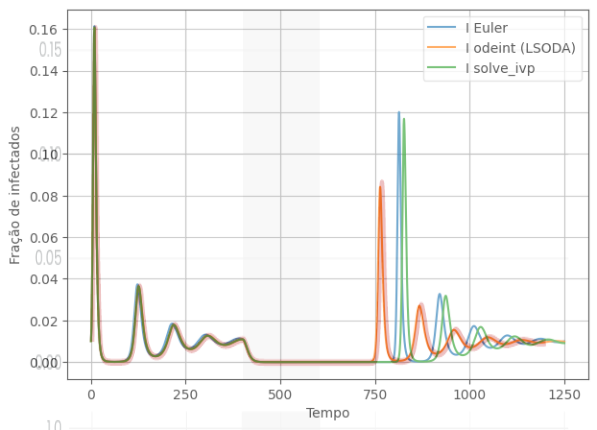

In [ ]:
print('Funções próprias')
%timeit SIRS_v(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end)
%timeit SIRS_v2(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end)
%timeit SIRS_v3(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end)

print('\nscipy.odeint')
%timeit odeint(deriv, y0, t, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), tfirst=True).T
print('Tolerância ajustada')
%timeit odeint(deriv, y0, t, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), tfirst=True, atol = 1e-30).T

print('\nscipy.solve_ivp')
%timeit solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=t)
%timeit solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=t, method='DOP853')
print('Tolerância ajustada')
%timeit sim4 = solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=t, atol = 1e-30, method='RK45')
%timeit sim4 = solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=t, atol = 1e-30, method='RK23')
%timeit sim4 = solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=t, atol = 1e-30, method='DOP853')
%timeit sim4 = solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=t, atol = 1e-30, method='Radau')
%timeit sim4 = solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=t, atol = 1e-30, method='BDF')
%timeit sim4 = solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=t, atol = 1e-30, method='LSODA')

# 3 - Testes iniciais do modelo SIRS com campanha de vacinação

Crio abaixo uma plotagem interativa ara testar pouco as funções criadas. Os valores de $S$, $I$ e $R$ são calculados a partir do método de Euler, e o passo de tempo utilizado foi $h = 0.01$, sendo o parâmetro mais relevante mantido fixo. Seu valor foi escolhido por produzir os dados em cerca de um décimo do tempo utilizado por $h = 0.001$, mas em um tempo muito similar a $h = 0.1$. Certamente, para $h > 0.01$ o tempo de geração das figuras consome a maior parte do tempo de execução dos programas, ao menos para os limites de tempo utilizados neste trabalho.

Apesar dos cálculos serem feitos utilizando valores relativos de $S$, $I$ e $R$, mantive os valores iniciais destas variáveis como valores absolutos de população, porque isso acrescenta algum sentido a mais nos dados para mim. Esses valores iniciais são expressos explicitamente em termos relativos da população logo abaixo do título principal. Outros valores expressos alí são o passo de tempo $h$, a população total em termos absolutos $N$, o número de reprodução básico $R_{0}$, e a taxa de vacinação teórica para erradicação da doença ($\alpha_{er}$). Esta taxa de vacinação é definida como aquela que faz com que o estado de equilíbrio de $I$ tenda a zero para um período suficientemente grande de tempo, e é expressa por

$$\alpha_{er} = \left( 1 - \frac{1}{R_{0}}\right)\delta$$

Vale mencionar também a existência da taxa de vacinação para imunidade total da população ($\alpha_{ti}$), que é expressa através de

$$\alpha_{ti} = \delta$$

Este valor, ou um maior, para $\alpha$ significa um fluxo maior de pessoas para o grupo dos Suscetíveis para os removidos do que o inverso.

In [ ]:
@wg.interact(N = wg.FloatSlider(value=1e3, min=0, max=1e5, step=1, readout_format='.0f'),
             S_i = wg.FloatSlider(value=990, min=0, max=1e4, step=1, readout_format='.0f'),
             I_i = wg.FloatSlider(value=10, min=0, max=1e2, step=1, readout_format='.0f'),
             beta = wg.FloatSlider(value=1, min=1e-2, max=10, step=1e-2, readout_format='.2f'),
             gamma = wg.FloatSlider(value=0.5, min=1e-2, max=1, step=1e-2, readout_format='.2f'),
             delta = wg.FloatSlider(value=0.01, min=1e-3, max=1e-1, step=1e-3, readout_format='.3f'),
             t_start = wg.FloatSlider(value=400, min=0, max=2e3, step=1, readout_format='.0f'),
             t_stop = wg.FloatSlider(value=600, min=0, max=2e3, step=1, readout_format='.0f'),
             alpha_cte = wg.FloatSlider(value=0.008, min=0.001, max=0.1, step=0.001, readout_format='.3f'),
             t_end = wg.FloatSlider(value=1250, min=0, max=2e3, step=1, readout_format='.0f'))
def plotar(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, t_end):

  h = 1e-2

  # SIRS_v3 retorna os valores de tempo e simulações com e sem vacinação.
  # A função também normaliza os valores de S_i e I_i
  sim_data = SIRS_v3(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end)

  graphs1(*sim_data, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h)

In [ ]:
@wg.interact(N = wg.FloatSlider(value=1e3, min=0, max=1e5, step=1, readout_format='.0f'),
             S_i = wg.FloatSlider(value=990, min=0, max=1e4, step=1, readout_format='.0f'),
             I_i = wg.FloatSlider(value=10, min=0, max=1e2, step=1, readout_format='.0f'),
             beta = wg.FloatSlider(value=1, min=1e-2, max=10, step=1e-2, readout_format='.2f'),
             gamma = wg.FloatSlider(value=0.5, min=1e-2, max=1, step=1e-2, readout_format='.2f'),
             delta = wg.FloatSlider(value=0.01, min=1e-3, max=1e-1, step=1e-3, readout_format='.3f'),
             t_start = wg.FloatSlider(value=400, min=0, max=2e3, step=1, readout_format='.0f'),
             t_stop = wg.FloatSlider(value=600, min=0, max=2e3, step=1, readout_format='.0f'),
             alpha_cte = wg.FloatSlider(value=0.008, min=0.001, max=0.1, step=0.001, readout_format='.3f'),
             t_end = wg.FloatSlider(value=1250, min=0, max=2e3, step=1, readout_format='.0f'))
def plotar(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, t_end):

  h = 1e-2
  t_i = 0
  tt = np.arange(t_i, t_end, h)

  R_i = N - S_i - I_i

  S_i = S_i/N
  I_i = I_i/N
  R_i = R_i/N

  y0 = S_i, I_i, R_i

  S, I, R = odeint(deriv, y0, tt, args=(beta, gamma, delta, 0, 0, 0), tfirst=True).T
  S_v, I_v, R_v = odeint(deriv, y0, tt, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), atol=1e-30, tfirst=True).T

  graphs1(tt, S, I, R, S_v, I_v, R_v, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h)

Abaixo apresento os valores estacionario de suscetiveis, infectados e removidos em função dos parâmetros $\beta$, $\gamma$ e $\delta$, no caso sem campanha de vacinação.

$$ S^{*} = \frac{1}{R_{0}} = \frac{\gamma}{\beta}$$

$$ I^{*} = \left( 1 - \frac{1}{R_{0}} \right) \frac{\delta}{\gamma + \delta} $$

$$ R^{*} = \left( 1 - \frac{1}{R_{0}} \right) \frac{\gamma}{\gamma + \delta} $$

Enquanto o valor de um dos parâmetros estiver sendo variado, os demais são fixos em $\beta = 1$, $\gamma = 0.5$ e $\delta = 0.01$

In [ ]:
sample_size = 201
beta_domain = np.linspace(0.5, 10, sample_size)
gamma_domain = np.linspace(0.001, 1, sample_size)
delta_domain = np.linspace(0.001, 0.1, sample_size)

beta, gamma, delta = 1, 0.5, 0.01

S_beta, I_beta, R_beta = stationary(beta_domain, gamma, delta)
S_gamma, I_gamma, R_gamma = stationary(beta, gamma_domain, delta)
S_delta, I_delta, R_delta = stationary(beta, gamma, delta_domain)

fig, ax = plt.subplots(3,1, figsize = (5,8),
                       layout='tight')

ax[0].plot(beta_domain, S_beta, label='S$^{*}$')
ax[0].plot(beta_domain, I_beta, label='I$^{*}$')
ax[0].plot(beta_domain, R_beta, label='R$^{*}$')
ax[0].set(xlabel='Beta', ylabel='Fração da população')
ax[0].grid()
ax[0].legend()

ax[1].plot(gamma_domain, S_gamma, label='S$^{*}$')
ax[1].plot(gamma_domain, I_gamma, label='I$^{*}$')
ax[1].plot(gamma_domain, R_gamma, label='R$^{*}$')
ax[1].set(xlabel='Gamma', ylabel='Fração da população')
ax[1].grid()
ax[1].legend()

ax[2].plot(delta_domain, np.full(len(delta_domain), S_delta), label='S$^{*}$')
ax[2].plot(delta_domain, I_delta, label='I$^{*}$$^{*}$')
ax[2].plot(delta_domain, R_delta, label='R$^{*}$')
ax[2].set(xlabel='Delta', ylabel='Fração da população')
ax[2].grid()
ax[2].legend()

plt.show()

# 4 - Reproduzindo dados do artigo

## 4.1 - Sessão 1: *The rebound effect of misaligned vaccination*

### Primeiros gráficos

Castorini et al. dizem ter cuidado para que as campanhas de vacinação simuladas não reduzissem o valor relatívo de Suscetíveis para além de 0.005, pois isso seria um evento irreal. Eu não sei exatamente se isso significa que foram utilizados somente parâmetros que mantivessem o valor de Suscetíveis acima de tal limite; se a simulação é interrompida no caso de $S$ alcançar o limite estabelecido, ou os valores são reajustados pra que continue obedecendo o limite. Imagino que seja o primeiro caso.

Abaixo busco reproduzir os primeiros gráficos do artigo, que mostram a o efeito de uma campanha de vacinação representada por uma taxa de vacinação

$$\alpha(t) = \left\{ \begin{array}{rcl} \alpha & \mbox{para} & t \in [t_{start}, t_{stop}] \\
0 & \mbox{para} & t \notin [t_{start}, t_{stop}] \\ \end{array}\right.$$

já apresentada acima. Os valores para $\alpha$ aplicados no artigo foram de $\alpha = 0.003$ e $\alpha = 0.008$, levando o sistema para condições de coexistência e erradicação da doença respectivamente.

Estando incerto quanto a aplicaçõa do limite para proporção de Suscetíveis descrito acima, busquei identificar quando o limite é ultrapassado, porém sem interferir nos cálculos da evolução do sistema. Se a fração de Suscetíveis estiver diminuindo dentro do período da campanha de vacinação, e durante essa queda a fração ficar menor que o valor limite estabelecido, então será impresso "True" na legenda do gráfico inferior direito. Do contrário, será impresso "False".

Os valores padrões dos parâmetros no gráfico interativo são os mesmos indicados no artigo, e optei por $\alpha = 0.008$ como o valor padrão de $\alpha$ por ser um caso mais chamativo. Para testar outros valores, basta interagir com os seletores interativos.

Diferente do artigo, criei simulações do sistema com os mesmos parâmetros, porém sem campanha de vacinação, para comparar com a evolução quando temos vacinação.

In [ ]:
@wg.interact(N = wg.FloatSlider(value=1e3, min=0, max=1e5, step=1, readout_format='.0f'),
             S_i = wg.FloatSlider(value=990, min=0, max=1e4, step=1, readout_format='.0f'),
             I_i = wg.FloatSlider(value=10, min=0, max=1e2, step=1, readout_format='.0f'),
             beta = wg.FloatSlider(value=1, min=1e-2, max=10, step=1e-2, readout_format='.2f'),
             gamma = wg.FloatSlider(value=0.5, min=1e-2, max=1, step=1e-2, readout_format='.2f'),
             delta = wg.FloatSlider(value=0.01, min=1e-3, max=1e-1, step=1e-3, readout_format='.3f'),
             t_start = wg.FloatSlider(value=400, min=0, max=2e3, step=1, readout_format='.0f'),
             t_stop = wg.FloatSlider(value=600, min=0, max=2e3, step=1, readout_format='.0f'),
             alpha_cte = wg.FloatSlider(value=0.008, min=0.0001, max=0.1, step=0.0001, readout_format='.4f'),
             t_end = wg.FloatSlider(value=1250, min=0, max=2e3, step=1, readout_format='.0f'))

def plotar(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, t_end):

  h = 1e-2

  # SIRS_v3 retorna os valores de tempo e simulações com e sem vacinação.
  # A função também normaliza os valores de S_i e I_i
  sim_data = SIRS_v3(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end)
  tt, S, I, R, S_v, I_v, R_v = sim_data

  # Verificar se a razão de Suscetíveis cai abaixo de 0.005 durante a campanha de vacinação
  lower_limit = 0.005
  S_vac_camp = S_v[(tt >= t_start) | (tt <= t_stop)]
  pass_limit = any((S_vac_camp[i] < S_vac_camp[i+1]) and (S_vac_camp[i+1] < lower_limit) for i in range(len(S_vac_camp)-1))

  # Verificar valor de infectados ao dinal da campanha de vacinação
  I_stop = np.array(I_v)[(tt < t_stop) & (tt > t_start)]
  print('\n A fração de infectados ao final da campanha de vacinação é: {:.2e}'.format(I_stop[-1]))

  graphs2(*sim_data, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h, lower_limit, pass_limit, logscale=True)


Os gráficos montados desta forma se assemelham muito com aqueles presentes no artigo. Contudo, no caso $\alpha = 0.008$, algumas diferenças são facilmente notáveis nos picos de Suscetíveis e infectados após o fim da campanha de vacinação.

Em minhas simulação, o primeiro pico de Suscetíveis após a campanha ultrapassa o valor de 0.8 com uma boa margem, enquanto que no artigo este pico ultrapassa 0.8 com uma margem muito menor. Arrisco a dizer que o segundo pico apresenta o mesmo comportamento, e que o primeiro vale de minha simulações é mais profundo do que no caso do artigo, embora isso seja seja menos evidente.  

O primeiro pico de infectados que encontrei, após a campanha de vacinação, também é maior que o respectivo pico no artigo, calcançando quase o valor de 0.12, quanto no artigo o valor fica abaixo de 0.10.

Até o momento não encontrei a razão para essas diferenças com o artigo. Mantendo inalterados os parâmetros explicitos no artigo, testei simulações com diferentes valores de passo de tempo, e também diferentes valores de de $S$ e $I$ iniciais que mantivessem as razões iniciais de 0.99 e 0.1 respectivamente, porém nada disso teve resultados mais próximos aos do artigo.


### Relação entre parâmetros e rebotes

Aqui verifico o tamanho do rebote após a campanha de vacinação na medida em que mudo o valor dos parâmetros $\beta$, $\gamma$, e $\delta$. O rebote no número de infectados é avaliado comparando o primeiro pico após a campanha de vacinação com o valor de infectados ao fim da campanha de vacinação, e também com o valor de infectados no regime estacionário sem campanha de vacinação, que é dado por

$$ I^{*} = \left( 1 - \frac{1}{R_{0}} \right) \frac{\delta}{\gamma + \delta} $$

Para iniciar tais verificações, escolho os mesmos valores de parâmetros utilizado no artigo de Castioni *et al.* para criar seus primeiros gráficos: $\beta=1$, $\gamma=0.5$, e $\delta=0.01$. Tem-se o cuidade de não permitir que a ração entre $\beta$ e $\gamma$, também conhecida como o número de reprodução básico ($R_{0}$), será sempre maior que 1. O parametro $\alpha$ será fixado em 0.008, e a duração da campanha de vacinação será fixada em 200 dias.

In [ ]:
sample_size = 100
beta_domain = np.linspace(0.60, 6, sample_size)
gamma_domain = np.linspace(0.008, 0.8, sample_size)
delta_domain = np.linspace(0.008, 0.1, sample_size)

# Parâmetros
N, S_i = 1000, 990
I_i = N - S_i # Consequentemente, R_i = 0

beta, gamma, delta = 1, 0.5, 0.01

h, t_end = 0.01, 2000

t_start, t_stop, alpha_cte = 400, 600, 0.003 # Para a campanha de vacinação

# Condições iniciais
tt = np.arange(0, t_end, h)

R_i = N - S_i - I_i

S_i = S_i/N
I_i = I_i/N
R_i = R_i/N

y0 = S_i, I_i, R_i

In [ ]:
sim_beta = []
sim_gamma = []
sim_delta = []
sim_R_0 = []

for i in range(sample_size):
  sim_beta.append(odeint(deriv, y0, tt, args=(beta_domain[i], gamma, delta, t_start, t_stop, alpha_cte), tfirst=True, atol = 1e-30).T)
  sim_gamma.append(odeint(deriv, y0, tt, args=(beta, gamma_domain[i], delta, t_start, t_stop, alpha_cte), tfirst=True, atol = 1e-30).T)
  sim_delta.append(odeint(deriv, y0, tt, args=(beta, gamma, delta_domain[i], t_start, t_stop, alpha_cte), tfirst=True, atol = 1e-30).T)
  sim_R_0.append(odeint(deriv, y0, tt, args=(2*gamma_domain[i], gamma_domain[i], delta, t_start, t_stop, alpha_cte), tfirst=True, atol = 1e-30).T)

I_all = np.array([np.array(sim_beta)[:,1],
                  np.array(sim_gamma)[:,1],
                  np.array(sim_delta)[:,1],
                  np.array(sim_R_0)[:,1]])

In [ ]:
rebounds = np.apply_along_axis(three_point_peak, 2, I_all, *[tt, t_stop], **{'after_stop': True})
I_stop = I_all[:, :, tt >= t_stop][:, :, 0]
I_stat = [stationary(beta_domain, gamma, delta)[1],
          stationary(beta, gamma_domain, delta)[1],
          stationary(beta, gamma, delta_domain)[1],
          stationary(2*gamma_domain, gamma_domain, delta)[1]]

In [ ]:
par_domain = [beta_domain, gamma_domain, delta_domain, gamma_domain]

title = [r'$\gamma = {}, \ \delta = {}, \ \alpha = {}$'.format(gamma, delta, alpha_cte),
         r'$\beta = {}, \ \delta = {}, \ \alpha = {}$'.format(beta, delta, alpha_cte),
         r'$\beta = {}, \ \gamma = {}, \ \alpha = {}$'.format(beta, gamma, alpha_cte),
         r'$R_{{0}} = {}, \ \delta = {}, \ \alpha = {}$'.format(2, delta, alpha_cte)]

xlabel = [r'Taxa de infecção, $\beta$',
          r'Taxa de remoção, $\gamma$',
          r'Taxa de perda de imunidade, $\delta$',
          r'Taxa de remoção, $\gamma$',]

fig, ax = plt.subplots(2,2, figsize=(8,5),
                       layout = 'tight')

fig.suptitle('Variando Parâmetros', y=1.05)

for i in range(4):
  a = ax[np.unravel_index(i, (2,2))]
  a.plot(par_domain[i], rebounds[i], label = 'Rebote')
  a.plot(par_domain[i], I_stat[i], label = 'I$^{*}$')
  a.plot(par_domain[i], I_stop[i], label = 'I(t$_{stop}$)')
  a.set(xlabel=xlabel[i], ylabel = 'Fração de infectados')
  a.set_title(title[i], fontsize=10)
  a.grid()

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.01))

Utilizando um argumento que poderia ser usada para explicar o valor do estado estacionário de infectados, faz sentido que o rebote tenha um valor maior quando a taxa de infecção é maior, pois isso significa um maior fluxo de indivíduos para o grupo de infectados. Um raciocínio análogo pode ser feito para entender o porque do rebote ser menor quando a taxa de remoção é maior. O aumento do rebote quando aumentamos a taxa de perda de imunidade também parece plausível, pois o que esta taxa faz é aumentar o fluxo para o grupo dos sucetíveis, e sabemos que tanto maior o número de sucetíveis mais cresce o grupo de infectados.

Estas curvas me fizeram perceber algo importante, que apesar do valor do rebote ser maior para valores pequenos de $\gamma$ estes valores não são muito grandes quando comparados à epidemia como um todo, pois nestes casos mesmo o estado estacionário tem um valor mais alto. Em outras palavras, os rebotes são mais "claros" quanto maior for a taxa de remoção. Nos gráficos das simulações de epidemias que podem ser vistos em outras sessões deste notebook, podem-se observar esta proporcionalidade. Em um primeiro momento parece que o pico do rebote "aumenta", mas na verdade ele esta diminuindo, esteja atento à escala do eixo vertical para se convencer disso. O que acontece é que o pico do rebote fica maior em comparação com o restante da epidemia onde se encontra.

Abaixo deixo um gráfico da razão do número de infectados no rebote e o valor de infectados no estado estacionário, em função da taxa de remoção.

In [ ]:
fig, ax = plt.subplots(figsize=(6,3))

ax.plot(gamma_domain, rebounds[1]/I_stat[1], label=r'$\frac{Rebote}{I^{*}}$')
ax.set_title(r'$\beta = {}, \ \delta = {}, \ \alpha = {}$'.format(beta, delta, alpha_cte))
ax.set(xlabel=r'Taxa de remoção, $\gamma$')
#ax.set(yscale='log')
ax.grid()
ax.legend()

### Modelo analítico do pós-campanha

Testamos também as expressões analíticas para a evolução da epidemia após o término da campanha de vacinação, caso a fração de infectados tome um valor próximo de zero.

Neste modelo analítico, o número de infectados, removidos e Suscetíveis são dado por

$$ I(t) = I(t_{stop}) \exp \left[ (\beta - \gamma) (t - t_{stop}) - \frac{\beta R (t_{stop})}{\delta} (1 - e^{-\delta(t-t_{stop})})\right] $$

$$ R(t) = R(t_{stop})e^{-\delta (t - t_{stop})} + \widetilde{\Delta R}(I(t), t) $$

$$ S(t) = 1 - R(t_{stop})e^{-\delta (t - t_{stop})} + \widetilde{\Delta S}(I(t), t) $$

onde $\widetilde{\Delta R}$ e $\widetilde{\Delta S}$ são estimativas para $\Delta R$ e $\Delta S$, as diferenças entre valores de $R$ e $S$, no mesmo tempo $t$, previstas pelo modelo numérico já apresentado e pelo modelo que considera $I(t_{stop})=0$ de fato. Este outro modelo descrito pelas equações abaixo

$$ S_{I0}(t) = 1 - R(t_{stop})e^{-\delta (t - t_{stop})}$$
$$ R_{I0}(t) = R(t_{stop})e^{-\delta (t - t_{stop})}$$
$$ S_{I0} + R_{I0} = 1 $$

Então demos as definições

$$ \Delta S \equiv S(t) - S_{I0}(t) $$
$$ \Delta R \equiv R(t) - R_{I0}(t) $$

As estimativas dessas diferenças são dadas elas expressões

$$ \widetilde{\Delta R}(I(t), t) = \Delta R(t_{stop}) e^{-\delta (t - t_{stop})} + \gamma \int_{t_{stop}}^{t} e^{-\delta(t - u)} I(u) \ dt$$

$$ \widetilde{\Delta S}(I(t), t) = -[I(t) + \widetilde{\Delta R}(I(t), t)]$$

In [ ]:
@wg.interact(N = wg.FloatSlider(value=1e3, min=0, max=1e5, step=1, readout_format='.0f'),
             S_i = wg.FloatSlider(value=990, min=0, max=1e4, step=1, readout_format='.0f'),
             I_i = wg.FloatSlider(value=10, min=0, max=1e2, step=1, readout_format='.0f'),
             beta = wg.FloatSlider(value=1, min=1e-2, max=10, step=1e-2, readout_format='.2f'),
             gamma = wg.FloatSlider(value=0.5, min=1e-2, max=1, step=1e-2, readout_format='.2f'),
             delta = wg.FloatSlider(value=0.01, min=1e-3, max=1e-1, step=1e-3, readout_format='.3f'),
             t_start = wg.FloatSlider(value=400, min=0, max=2e3, step=1, readout_format='.0f'),
             t_stop = wg.FloatSlider(value=600, min=0, max=2e3, step=1, readout_format='.0f'),
             alpha_cte = wg.FloatSlider(value=0.008, min=0.001, max=0.1, step=0.001, readout_format='.3f'),
             t_end = wg.FloatSlider(value=1250, min=0, max=2e3, step=1, readout_format='.0f'))

def plotar(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, t_end):

  h = 1e-2

  # SIRS_v3 retorna os valores de tempo e simulações com e sem vacinação.
  # A função também normaliza os valores de S_i e I_i
  sim_data = SIRS_v3(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h, t_end)
  tt, S, I, R, S_v, I_v, R_v = sim_data

  data_sirs = S, I, R
  data_sirs_v = S_v, I_v, R_v

  #Verificar se durante a campanha de vacinação a razão de Suscetíveis cai abaixo de 0.005
  lower_limit = 0.005
  S_vac_camp = S_v[(tt >= t_start) | (tt <= t_stop)]
  pass_limit = any((S_vac_camp[i] < S_vac_camp[i+1]) and (S_vac_camp[i+1] < lower_limit) for i in range(len(S_vac_camp)-1))

  # Calcular valores pós vacinação pelo método analítico
  data_analitic = analitic_post_vac(tt, S_v, I_v, R_v, beta, gamma, delta, t_stop)

  I_stop = np.array(I_v)[(tt < t_stop) & (tt > t_start)]
  print('\n A fração de infectados ao final da campanha de vacinação é: {:.2e}'.format(I_stop[-1]))

  graphs3(tt, data_sirs, data_sirs_v, data_analitic, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h, lower_limit, pass_limit, logscale=True)


## 4.2 - Sessão 2: *Timing as a fundamental feature to avoid the rebound*

Nesta sessão simulações são realizadas para encontrar valores ótimos do momento de início da campanha de vacinação, da taxa de vacinação constante e do tempo de duração da campanha de vacinação para um dado dia de início. O foco está na diminuição do "maior pico subsequente" de infectados de uma epidemia simulada inicialmente sem campanha de vacinação.

Esse critério de otimização não me pareceu muito claro. Qual seria o pico subsequente? Considerando que o objetivo desta estratégia é conter o rebote da epidemia, seria os "picos subsequentes" aqueles que ocorrem após início da campanha de vacinação, ou aqueles que ocorrem após o término da campanha? Ou seriam quaisquer picos a partir do segundo, se contamos desde o tempo $t=0$ da epidemia?

Não me parece que se trate do maior pico após i início ou fim da campanha de vacinação, porque nesse caso os resultados ótimos presentes no artigo não fazerm sentido, pois indicam campanhas que terminariam antes mesmo do primeiro pico acontecer. Uma vez que valor do segundo pico da epidemia base é utilizado como parâmetro para verificar a "variação do pico", pensei que estariamos focando de fato no segundo pico a partir de $t=0$, porém isso trás o seguinte problema, na medida em que o início da campanha de vacinação avança, ultrapassando o primeiro pico e estando antes do segundo, surge um novo pico nos dados com campanha de vacinação. Esse pico parece acontecer logo antes ou durante a campanha de vacinação.

Em uma nota de rotapé se comenta que o "próximo maior pico" é muitas vezes o segundo (no caso a partir do tempo $t=0$), mas a depender de como ocorre a campanha de vacinação pode ser mesmo o terceiro pico.

Estaria falando do segundo pico após o início da campanha de vacinação? Ou do primeiro pico após a campanha de vacinação cuja ascenção não tenha iniciado durante a campanha?

Para estabelecer alguns limites na busca dos parâmetros, o número total de vacinas disponível foi limitado a 30% da população, e a taxa máxima de vacinação foi estabelecida como 1% ao dia. A extensão da campanha de vacinação deve estar entre 30 e 150 dias. Tenho duvidas se é suposto que todas as vacinas devem ser gastas ao final da campanha de vacinação, mas vou considerar que seja o caso pois no início dessa sessão é dito que a duração da campanha é inversamente proporcional à taxa de vacinação ($\alpha$). Digamos, se $D$ for a duração da campanha, e $V$ a quantidade de total vacinas em relação à população, temos

$$ \alpha = \frac{V}{D} $$



 ao mesmo tempo que o texto diz que as cores das figuras 4.b e 4.c indicam a duração da campanha, a legenda da figura diz que as cores refletem a taxa de vacinação.

### Campanha de vacinação constante - Partindo das Simulações

In [ ]:
# Definir parâmetros para a simulação sem vacinação
S_i, I_i, R_i = 99990, 10, 0
beta, gamma, delta = 0.4, 0.2, 0.01

t_end, h = 450, 1e-1

N = S_i + I_i + R_i

tt, S, I, R = SIRS_v(N, S_i, I_i, beta, gamma, delta, 0, 0, 0, h, t_end)

# Encontrar valor dos picos de infectados
max_values_condition = (I[:-2] < I[1:-1]) & (I[1:-1] > I[2:])
max_values_indexes = np.where(max_values_condition)[0] + 1
max_values = I[max_values_indexes]
max_values_times = tt[max_values_indexes]

print('Máximos de infectados: {}'.format(max_values))
print('Índices dos máximos: {}'.format(max_values_indexes))
print('Tempos dos máximos: {}'.format(max_values_times))
print('Foram encontrados {} máximos'.format(len(max_values)))

In [ ]:
# Definir parâmetros referentes à vacinação
t_start = np.arange(0, max_values_times[1], 1)
total_vaccines = 0.3
camp_duration = np.linspace(30, 150, 121)
sample_size = 1

params = np.array([[beta, beta/gamma, delta, t_sa, t_sa+d, total_vaccines/d, n] 
                   for t_sa in t_start for d in camp_duration for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sims = func_sim(N, S_i, I_i, params, h, t_end, 'euler')

In [ ]:
np.savez_compressed('session2_h01_ode',
                    parameters = sims[0], susceptible = sims[1],
                    infected = sims[2], removed = sims[3])

In [ ]:
loaded = np.load('session2_h01_ode.npz')
sims = [loaded[k] for k in loaded.files]

In [ ]:
Suceptible = sims[1]
Infected = sims[2]
rebound_values = np.array([three_point_peak_big_small(Infected[i], tt, params[i,4], after_stop=True, big_small='big') 
                           for i in range(len(Infected))]).T

max_values_v_greatest = rebound_values[0]
max_values_v_indexes = rebound_values[1].astype(int)
max_values_v_times = tt[max_values_v_indexes]

# Calcular variações dos maiores picos pós campanha com o segundo
# pico do caso sem vacinação
peak_variation = max_values_v_greatest - max_values[1]

# Para cada valor de t_start, encontrar o caso em que a variação do
# pico é mais negativa
n_t_start = len(np.unique(t_start))
n_camp_duration =  len(np.unique(camp_duration))
min_index = np.nanargmin(peak_variation.reshape(n_t_start, n_camp_duration), axis=1)

best_peak_variation = peak_variation.reshape(n_t_start, n_camp_duration)[np.arange(n_t_start), min_index]
best_duration = camp_duration[min_index]
peak_index = max_values_v_indexes.reshape(n_t_start, n_camp_duration)[np.arange(n_t_start), min_index]

best_S_v = Suceptible.reshape(n_t_start, n_camp_duration, np.shape(Suceptible)[1])[np.arange(n_t_start), min_index]
best_I_v = Infected.reshape(n_t_start, n_camp_duration, np.shape(Infected)[1])[np.arange(n_t_start), min_index]
#best_R_v = Removed.reshape(n_t_start, n_camp_duration, np.shape(Removed)[1])[np.arange(n_t_start), min_index]

### Gráficos "best cases" individuais

In [ ]:
graphs4(best_S_v, best_I_v, I, tt, t_start, best_duration, peak_index, max_values[1], max_values_times[1])

### Gráfico animado

In [ ]:
graphs4_animation(best_S_v, best_I_v, I, tt, t_start, best_duration, peak_index, max_values[1], max_values_times[1])

### Gráfico de barras (da variação do pico)

In [ ]:
graphs_bars1(best_duration, best_peak_variation, t_start, max_values[1], max_values_times)

No gráfico abaixo é representada a diferença entre a altura do maior pico após o final da campanha de vacinação (isso significa não necessariamente o segundo pico) e o segundo pico previsto na simulação sem campanha de vacinação. Os valores de parâmetros utilizados foram $\beta$ = 0.4, $\gamma$ = 0.2, $\delta$ = 0.01, $S(0)$ = 0.9999, $I(0)$ = 0.0001

Apesar da forma lembrar muito o gráfico presente no artigo, nosso gráfico toma um comportamento claramente diferente para maiores valores de dia inicial da campanha. Este comportamente está associado à detecção do terceiro pico como o maior após o final da campanha de vacinação. No artigo, as barras do gráfico diminuem até se anularem nas proximidades do tempo correspondente ao segundo pico (sem vacinação), o que parece indicar que o pico de interesse no caso com vacinação é o mesmo pico, porém isso significa que o "maior pico subsequente" pode ocorrer ainda durante a campanha de vacinação, pois o tempo mínimo de duração da campanha é 30 dias.

Percebi que no programa que criei, o método para determinar a variação do pico compara, na verdade diferentes picos. As barras mais à esquerda tratam de variações do segundo pico da epidemia, pois eu estava na prática escolhendo o sistema que entregasse um menor valor de pico, e muito provavelmente em todos os casos analisados o primeiro pico era sempre maior caso fosse um cadidato.

max_after_stop.png

### Campanha de vacinação com "ajuste fino"

In [ ]:
# Definir parâmetros para a simulação sem vacinação
S_i, I_i, R_i = 99990, 10, 0
beta, gamma, delta = 0.4, 0.2, 0.01

t_end, h = 1250, 1e-1

N = S_i + I_i + R_i

tt, S, I, R = SIRS_v(N, S_i, I_i, beta, gamma, delta, 0, 0, 0, h, t_end)

# Encontrar valor dos picos de infectados
max_values_condition = (I[:-2] < I[1:-1]) & (I[1:-1] > I[2:])
max_values_indexes = np.where(max_values_condition)[0] + 1
max_values = I[max_values_indexes]
max_values_times = tt[max_values_indexes]

print('Máximos de infectados: {}'.format(max_values))
print('Índices dos máximos: {}'.format(max_values_indexes))
print('Tempos dos máximos: {}'.format(max_values_times))
print('Foram encontrados {} máximos'.format(len(max_values)))

In [ ]:
# Definir parâmetros referentes à vacinação
t_start = np.arange(0, max_values_times[1], 1)
total_vaccines = 0.3
alpha_cte = np.linspace(0.002, 0.01, 121)
sample_size = 1

params = np.array([[beta, beta/gamma, delta, t_sa, total_vaccines, a, n] 
                   for t_sa in t_start for a in alpha_cte for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sims_fine = func_sim(N, S_i, I_i, params, h, t_end, 'euler_fine')

In [ ]:
fig, ax = plt.subplots()
ax.scatter(sims_fine[0][::121,3], sims_fine[4][::121] - sims_fine[0][::121,3])
ax.set(xlabel='Duração da campanha',
      ylabel='Final da campanha')
ax.grid()

In [ ]:
fig, ax = plt.subplots()
ax.hist(sims_fine[4])
ax.set_xlabel('Momento final da campanha')

In [ ]:
np.savez_compressed('session2_h01_euler_fine',
                    parameters = sims_fine[0], susceptible = sims_fine[1],
                    infected = sims_fine[2], removed = sims_fine[3], t_stop = sims_fine[4])

In [ ]:
params[:,4] = sims_fine[4]
camp_duration = params[:,4] - params[:,3]

In [ ]:
Suceptible = sims_fine[1]
Infected = sims_fine[2]
rebound_values = np.array([three_point_peak_big_small(Infected[i], tt, params[i,4], after_stop=True, big_small='big') 
                           for i in range(len(Infected))]).T

max_values_v_greatest = rebound_values[0]
max_values_v_indexes = np.where(np.isnan(rebound_values[1]), 0, rebound_values[1].astype(int))
max_values_v_times = tt[max_values_v_indexes]

# Calcular variações dos maiores picos pós campanha com o segundo
# pico do caso sem vacinação
peak_variation = max_values_v_greatest - max_values[1]

# Para cada valor de t_start, encontrar o caso em que a variação do
# pico é mais negativa
n_t_start = len(np.unique(t_start))
n_alpha_cte =  len(np.unique(alpha_cte))
min_index = np.nanargmin(peak_variation.reshape(n_t_start, n_alpha_cte), axis=1)

best_peak_variation = peak_variation.reshape(n_t_start, n_alpha_cte)[np.arange(n_t_start), min_index]
best_alpha_cte = alpha_cte[min_index]
best_duration = camp_duration[min_index]
peak_index = max_values_v_indexes.reshape(n_t_start, n_alpha_cte)[np.arange(n_t_start), min_index]

best_S_v = Suceptible.reshape(n_t_start, n_alpha_cte, np.shape(Suceptible)[1])[np.arange(n_t_start), min_index]
best_I_v = Infected.reshape(n_t_start, n_alpha_cte, np.shape(Infected)[1])[np.arange(n_t_start), min_index]
#best_R_v = Removed.reshape(n_t_start, n_alpha_cte, np.shape(Removed)[1])[np.arange(n_t_start), min_index]

In [ ]:
now = datetime.now()
time_string = now.strftime("%d-%m-%Y_%Hh%Mm%Ss")
dir_name = 'Fine_tune_{}'.format(time_string)

os.mkdir(dir_name)

for i in range(len(best_S_v)):

  t_sa = t_start[i]
  t_so = sims_fine[4][i]

  # Transformar listas em arrays
  S_v, I_v = best_S_v[i], best_I_v[i]

  #Verificar se durante a campanha de vacinação a razão de Suscetíveis cai abaixo de 0.005
  lower_limit = 0.005
  S_vac_camp = S_v[(tt >= t_sa) | (tt <= t_so)]
  pass_limit = any((S_vac_camp[i] < S_vac_camp[i+1]) and (S_vac_camp[i+1] < lower_limit) for i in range(len(S_vac_camp)-1))

  # Criar gráfico
  fig, ax = plt.subplots(figsize=(7,3))
  ax.set_title(r'Campanha com ajuste fino ($t_{{start}}$= {:.0f}, $\alpha$ = {:.4f}, $\Delta I_{{peak}}$= {:.4f})'.format(t_sa, best_alpha_cte[i], best_peak_variation[i]))

  # Plotar curvas de infectados
  ax.plot(tt, I, label='I', zorder = 2)
  ax.plot(tt, I_v, label='I_v', zorder = 3)
  # Plotar picos que estão sendo comparados
  ax.scatter(max_values_times[1], max_values[1], zorder = 5)
  ax.scatter(tt[peak_index[i]], I_v[peak_index[i]], zorder = 5)

  ax.fill_between(tt, 0, max(I), where=(tt < t_so) & (tt > t_sa), color='0.85', zorder = 1)
  ax.plot([], [], ls='', label="S < {}? {}".format(lower_limit, pass_limit))
  ax.set(xlabel='Tempo, t [dias]', ylabel='Fração da população' )
  ax.legend()
  ax.grid()

  name_graph = '{}/fine_tune_t{:.0f}_{}.png'.format(dir_name, i, time_string)
  plt.savefig(name_graph, dpi=300, bbox_inches='tight')

  plt.show()

# Criar objeto do ZipFile
with ZipFile('{}.zip'.format(dir_name), 'w') as zip_object:
   # iterar por todos os arquivos do diretório
   for folder_name, sub_folders, file_names in os.walk(dir_name):
      for filename in file_names:
         # Gerar localização do arquivo no diretório
         file_path = os.path.join(folder_name, filename)
         # Adicionar arquivo ao zip
         zip_object.write(file_path, os.path.basename(file_path))


In [ ]:
# Criar valor de taxa diária de vacinação
y = total_vaccines/np.array(best_duration)

# Criar vetor de cores com base no cmap "viridis revertido", escalado para o valores de y
max_rate = 0.01
min_rate = 0.002
m = 1.0/(max_rate-min_rate)
n = -m*min_rate
colors = plt.cm.viridis_r(m*y+n)


fig, ax = plt.subplots(figsize=(15, 5))

# Criar plot só para inserir a barra de cores. plt.cla omite as informações impressas anteriormente
color_plot = plt.scatter(y, y, c = y, cmap='viridis_r')
plt.cla()

plt.colorbar(color_plot, ax=ax, label=r'Taxa diária de vacinação, $\alpha$')

dashed_line = np.linspace(-1, 1, 100)
ax.plot(np.full(100, max_values_times[0]), dashed_line, ls='--', color='grey')
ax.plot(np.full(100, max_values_times[1]), dashed_line, ls='--', color='grey')

ax.bar(t_start[:len(best_peak_variation)], best_peak_variation, color = colors)
ax.set(xlabel='Tempo, [dias]', ylabel='Variação do maior pico após a campanha')
ax.set_ylim(bottom = min(best_peak_variation)*1.05, top = 0.005)
ax.grid()
plt.savefig('fine_tune_max_after_stop.png', dpi=300, bbox_inches='tight')
plt.show()

# 5 - Reproduzindo dados (com Scipy)

## Sessão 1

Utilizar a função **scipy.itegrate.odeint** para resolver o sistema de equações do modelo SIRS produz dados ainda mais parecidos com aqueles do artigo. Definir valores de tolerancia muito baixos pode fazer com o que os dados fiquem diferentes daqueles do artigo.

In [ ]:
@wg.interact(N = wg.FloatSlider(value=1e3, min=0, max=1e5, step=1, readout_format='.0f'),
             S_i = wg.FloatSlider(value=990, min=0, max=1e4, step=1, readout_format='.0f'),
             I_i = wg.FloatSlider(value=10, min=0, max=1e2, step=1, readout_format='.0f'),
             beta = wg.FloatSlider(value=1, min=1e-2, max=10, step=1e-2, readout_format='.2f'),
             gamma = wg.FloatSlider(value=0.5, min=1e-3, max=1, step=1e-3, readout_format='.3f'),
             delta = wg.FloatSlider(value=0.01, min=1e-3, max=1e-1, step=1e-3, readout_format='.3f'),
             t_start = wg.FloatSlider(value=400, min=0, max=2e3, step=1, readout_format='.0f'),
             t_stop = wg.FloatSlider(value=600, min=0, max=2e3, step=1, readout_format='.0f'),
             alpha_cte = wg.FloatSlider(value=0.008, min=0.0001, max=0.1, step=0.0001, readout_format='.4f'),
             t_end = wg.FloatSlider(value=1250, min=0, max=2e3, step=1, readout_format='.0f'))

def plotar(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, t_end):

  h = 1e-2
  t_i = 0
  tt = np.arange(t_i, t_end, h)

  R_i = N - S_i - I_i

  S_i = S_i/N
  I_i = I_i/N
  R_i = R_i/N

  y0 = S_i, I_i, R_i

  #S, I, R = solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, 0, 0, 0), t_eval=tt, method='DOP853').y
  #S_v, I_v, R_v = solve_ivp(deriv, (0, t_end), y0, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), t_eval=tt, method='DOP853').y

  S, I, R = odeint(deriv, y0, tt, args=(beta, gamma, delta, 0, 0, 0), tfirst=True).T
  S_v, I_v, R_v = odeint(deriv, y0, tt, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), tfirst=True, atol = 1e-30).T

  #Verificar se a razão de Suscetíveis cai abaixo de 0.005 durante a campanha de vacinação
  lower_limit = 0.005
  S_vac_camp = S_v[(tt >= t_start) | (tt <= t_stop)]
  pass_limit = any((S_vac_camp[i] < S_vac_camp[i+1]) and (S_vac_camp[i+1] < lower_limit) for i in range(len(S_vac_camp)-1))

  I_stop = np.array(I_v)[(tt < t_stop) & (tt > t_start)]
  print('\n A fração de infectados ao final da campanha de vacinação é: {:.2e}'.format(I_stop[-1]))

  graphs2(tt, S, I, R, S_v, I_v, R_v, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h, lower_limit, pass_limit, logscale=True)


In [ ]:
@wg.interact(N = wg.FloatSlider(value=1e3, min=0, max=1e5, step=1, readout_format='.0f'),
             S_i = wg.FloatSlider(value=990, min=0, max=1e4, step=1, readout_format='.0f'),
             I_i = wg.FloatSlider(value=10, min=0, max=1e2, step=1, readout_format='.0f'),
             beta = wg.FloatSlider(value=1, min=1e-2, max=10, step=1e-2, readout_format='.2f'),
             gamma = wg.FloatSlider(value=0.5, min=1e-3, max=1, step=1e-3, readout_format='.3f'),
             delta = wg.FloatSlider(value=0.01, min=1e-3, max=1e-1, step=1e-3, readout_format='.3f'),
             t_start = wg.FloatSlider(value=400, min=0, max=2e3, step=1, readout_format='.0f'),
             t_stop = wg.FloatSlider(value=600, min=0, max=2e3, step=1, readout_format='.0f'),
             alpha_cte = wg.FloatSlider(value=0.008, min=0.0001, max=0.1, step=0.0001, readout_format='.4f'),
             t_end = wg.FloatSlider(value=1250, min=0, max=2e3, step=1, readout_format='.0f'))

def plotar(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, t_end):

  h = 1e-2
  t_i = 0
  tt = np.arange(t_i, t_end, h)

  R_i = N - S_i - I_i

  S_i = S_i/N
  I_i = I_i/N
  R_i = R_i/N

  y0 = S_i, I_i, R_i

  S, I, R = odeint(deriv, y0, tt, args=(beta, gamma, delta, 0, 0, 0), tfirst=True).T
  S_v, I_v, R_v = odeint(deriv, y0, tt, args=(beta, gamma, delta, t_start, t_stop, alpha_cte), tfirst=True, atol = 1e-30).T

  data_sirs = S, I, R
  data_sirs_v = S_v, I_v, R_v

  #Verificar se durante a campanha de vacinação a razão de Suscetíveis cai abaixo de 0.005
  lower_limit = 0.005
  S_vac_camp = S_v[(tt >= t_start) | (tt <= t_stop)]
  pass_limit = any((S_vac_camp[i] < S_vac_camp[i+1]) and (S_vac_camp[i+1] < lower_limit) for i in range(len(S_vac_camp)-1))

  data_analitic = analitic_post_vac(tt, S_v, I_v, R_v, beta, gamma, delta, t_stop)

  I_stop = np.array(I_v)[(tt < t_stop) & (tt > t_start)]
  print('\n A fração de infectados ao final da campanha de vacinação é: {:.2e}'.format(I_stop[-1]))

  graphs3(tt, data_sirs, data_sirs_v, data_analitic, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h, lower_limit, pass_limit)

## Sessão 2

In [ ]:
# Definir parâmetros para a simulação sem vacinação
S_i, I_i, R_i = 99990, 10, 0
beta, gamma, delta = 0.4, 0.2, 0.01

t_end, h = 450, 1e-1

N = S_i + I_i + R_i

tt, S, I, R = SIRS_v(N, S_i, I_i, beta, gamma, delta, 0, 0, 0, h, t_end)

# Encontrar valor dos picos de infectados
max_values_condition = (I[:-2] < I[1:-1]) & (I[1:-1] > I[2:])
max_values_indexes = np.where(max_values_condition)[0] + 1
max_values = I[max_values_indexes]
max_values_times = tt[max_values_indexes]

print('Máximos de infectados: {}'.format(max_values))
print('Índices dos máximos: {}'.format(max_values_indexes))
print('Tempos dos máximos: {}'.format(max_values_times))
print('Foram encontrados {} máximos'.format(len(max_values)))

In [ ]:
# Definir parâmetros referentes à vacinação
t_start = np.arange(0, max_values_times[1], 1)
total_vaccines = 0.3
camp_duration = np.linspace(30, 150, 121)
sample_size = 1

params = np.array([[beta, beta/gamma, delta, t_sa, t_sa+d, total_vaccines/d, n] 
                   for t_sa in t_start for d in camp_duration for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sims = func_sim_odeint(N, S_i, I_i, params, h, t_end)

In [ ]:
np.savez_compressed('session2_h01_odeint',
                    parameters = sims[0], susceptible = sims[1],
                    infected = sims[2], removed = sims[3])

In [ ]:
loaded = np.load('session2_h01_odeint.npz')
sims = [loaded[k] for k in loaded.files]

In [ ]:
Suceptible = sims[1]
Infected = sims[2]
rebound_values = np.array([three_point_peak_big_small(Infected[i], tt, params[i,4], after_stop=True, big_small='big') 
                           for i in range(len(Infected))]).T

max_values_v_greatest = rebound_values[0]
max_values_v_indexes = rebound_values[1].astype(int)
max_values_v_times = tt[max_values_v_indexes]

# Calcular variações dos maiores picos pós campanha com o segundo
# pico do caso sem vacinação
peak_variation = max_values_v_greatest - max_values[1]

# Para cada valor de t_start, encontrar o caso em que a variação do
# pico é mais negativa
n_t_start = len(np.unique(t_start))
n_camp_duration =  len(np.unique(camp_duration))
min_index = np.nanargmin(peak_variation.reshape(n_t_start, n_camp_duration), axis=1)

best_peak_variation = peak_variation.reshape(n_t_start, n_camp_duration)[np.arange(n_t_start), min_index]
best_duration = camp_duration[min_index]
peak_index = max_values_v_indexes.reshape(n_t_start, n_camp_duration)[np.arange(n_t_start), min_index]

best_S_v = Suceptible.reshape(n_t_start, n_camp_duration, np.shape(Suceptible)[1])[np.arange(n_t_start), min_index]
best_I_v = Infected.reshape(n_t_start, n_camp_duration, np.shape(Infected)[1])[np.arange(n_t_start), min_index]
#best_R_v = Removed.reshape(n_t_start, n_camp_duration, np.shape(Removed)[1])[np.arange(n_t_start), min_index]

In [ ]:
graphs_bars1(best_duration, best_peak_variation, t_start, max_values[1], max_values_times)

# 6 - Reproduzindo dados (com agentes)

## Sessão 1

In [ ]:
@wg.interact(N = wg.IntSlider(value=1e5, min=0, max=1e6, step=1, readout_format='.0f'),
             S_i = wg.IntSlider(value=9.9e4, min=0, max=1e6-1e3, step=1, readout_format='.0f'),
             I_i = wg.IntSlider(value=1e3, min=0, max=1e4, step=1, readout_format='.0f'),
             beta = wg.FloatSlider(value=1, min=1e-2, max=10, step=1e-2, readout_format='.2f'),
             gamma = wg.FloatSlider(value=0.25, min=1e-3, max=1, step=1e-3, readout_format='.3f'),
             delta = wg.FloatSlider(value=0.01, min=1e-3, max=1e-1, step=1e-3, readout_format='.3f'),
             t_start = wg.FloatSlider(value=400, min=0, max=2e3, step=1, readout_format='.0f'),
             t_stop = wg.FloatSlider(value=600, min=0, max=2e3, step=1, readout_format='.0f'),
             alpha_cte = wg.FloatSlider(value=0.008, min=0.001, max=0.1, step=0.001, readout_format='.3f'),
             t_end = wg.FloatSlider(value=1250, min=0, max=2e3, step=1, readout_format='.0f'))
def plotar(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, t_end):

  h = 1e-0

  epi_agents = model_agents(N, S_i, I_i, beta, gamma, delta, 0, 0, 0, h)
  epi_agents_v = model_agents(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h)

  for _ in tqdm(range(int(t_end/h))):
    epi_agents.step()
    epi_agents_v.step()

  print('\n Sem vacinação')
  final_state(epi_agents.agents)
  print('\n Com vacinação')
  final_state(epi_agents_v.agents)

  tt, S, I, R = get_series(epi_agents)
  tt, S_v, I_v, R_v = get_series(epi_agents_v)

  #Verificar se a razão de Suscetíveis cai abaixo de 0.005 durante a campanha de vacinação
  lower_limit = 0.005
  S_vac_camp = S_v[(tt >= t_start) | (tt <= t_stop)]
  pass_limit = any((S_vac_camp[i] < S_vac_camp[i+1]) and (S_vac_camp[i+1] < lower_limit) for i in range(len(S_vac_camp)-1))

  I_stop = np.array(I_v)[(tt < t_stop) & (tt > t_start)]
  print('\n A fração de infectados ao final da campanha de vacinação é: {:.2e}'.format(I_stop[-1]))

  graphs2(tt, S, I, R, S_v, I_v, R_v, N, S_i, I_i, beta, gamma, delta, t_start, t_stop, h, lower_limit, pass_limit, logscale=False)

## Sessão 2 - Partir das simulações

In [ ]:
S_i, I_i, R_i = 99990, 10, 0
beta, gamma, delta = 0.4, 0.2, 0.01

total_vaccines = 0.3
duration = np.linspace(30, 150, 121)

t_end = 450

t_start_domain = np.arange(0, t_end, 1)

h = 1e-0

N = S_i + I_i + R_i

tt, S, I, R = SIRS_v(N, S_i, I_i, beta, gamma, delta, 0, 0, 0, h, t_end)

# Encontrar valor dos picos de infectados
max_values_condition = (I[:-2] < I[1:-1]) & (I[1:-1] > I[2:])
max_values_indexes = np.where(max_values_condition)[0] + 1
max_values = I[max_values_indexes]
max_values_times = tt[max_values_indexes]

print('Máximos de infectados: {}'.format(max_values))
print('Índices dos máximos: {}'.format(max_values_indexes))
print('Tempos dos máximos: {}'.format(max_values_times))
print('Foram encontrados {} máximos'.format(len(max_values)))

In [ ]:
print('"t_start","Duration","Peak variation","Progress(%)"')

S_v_list = []
I_v_list = []
R_v_list = []

t_start_list = []
t_stop_list = []
duration_list = []

# Loop para iterar sobre cada valor possível de início da campanha de vacinação até um certo pico
t_break = max_values_times[1]
for t_start in t_start_domain[t_start_domain <= t_break]:

  # Loop para iterar sobre possíveis valores de duração da campanha
  for d in tqdm(duration):

    # Calcular valores de taxa de vacinação e tempo final da campanha de vacinação
    alpha_cte = total_vaccines/d
    t_stop = t_start+d

    # Calcular simulação da epidemia com campanha de vacinação
    epi_agents_v = model_agents_gpu(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha_cte, h)

    for _ in range(int(t_end/h)):
      epi_agents_v.step()

    # Coletar arrays da simulação e adicionar na lista de candidatos
    tt_new, S_v_new, I_v_new, R_v_new = get_series_gpu(epi_agents_v)
    S_v_list.append(S_v_new.tolist())
    I_v_list.append(I_v_new.tolist())
    R_v_list.append(R_v_new.tolist())

    t_start_list.append(t_start)
    duration_list.append(d)

  print('{:.0f},{:.1f}'.format(t_start, 100*t_start/t_break))

In [ ]:
df = pd.DataFrame({'t_start': t_start_list,
                   'Camp_Duration': duration_list,
                   'Suceptible': S_v_list,
                   'Infected': I_v_list,
                   'Recovered': R_v_list})
df.to_csv('100000agents_beta1_gamma05_delta001_h01_gpu.csv', index=False)

In [ ]:
df_simulation = pd.read_csv('100000agents_beta1_gamma05_delta001_h1_gpu.csv', sep=',')
df_simulation

In [ ]:
t_start, camp_duration, Suceptible, Infected, Removed = df_simulation.values.T
t_start = t_start.astype(float)
camp_duration = camp_duration.astype(float)


# Transformar strings em listas de floats
#Suceptible = np.array([suc[1:-1].split(', ') for suc in Suceptible], dtype=float)
Infected = np.array([inf[1:-1].split(', ') for inf in Infected], dtype=float)
#Removed = np.array([rem[1:-1].split(', ') for rem in Removed], dtype=float)

In [ ]:
window_size = 11
Infected_movave = np.array([moving_average(inf, window_size) for inf in Infected])

h = 1
tt_original = np.arange(len(Infected[0])*h, step=h)
tt_movave = tt_original[int(np.floor(window_size/2)) : -(int(np.ceil(window_size/2)) - 1)]

t_stop = t_start + camp_duration

I_v = Infected_movave
tt = tt_movave
persist_cases = Infected[:,-1] != 0
n_extintions = sum(~persist_cases)

# Anular valores antes do fim da campanha
after_condition = (I_v[:,:-2] < I_v[:,1:-1]) & (I_v[:,1:-1] >= I_v[:,2:]) & (tt[None, 1:-1] > t_stop[:, None])
after_values = np.where(after_condition, I_v[:,1:-1], 0)

# argmax: encontrar o indice dos primeiros maiores valomax_values_v_indexesres depois do fim da campanha
max_values_v_indexes = np.stack((np.arange(len(camp_duration)),
                                 np.argmax(after_values, axis = 1) + int(np.floor(window_size/2))),
                                 axis = 0)

max_values_v_greatest = Infected[max_values_v_indexes[0], max_values_v_indexes[1]]
max_values_v_times = np.array([tt_original[i] for i in max_values_v_indexes[1]])

In [ ]:
# Calcular variações dos maiores picos pós campanha com o segundo
# pico do caso sem vacinação
peak_variation = np.where(persist_cases, max_values_v_greatest - 0.04541733, np.nan)

# Para cada valor de t_start, encontrar o caso em que a variação do
# pico é mais negativa
n_t_start = len(np.unique(t_start))
n_camp_duration =  len(np.unique(camp_duration))
min_index = np.nanargmin(peak_variation.reshape(n_t_start, n_camp_duration), axis=1)

best_peak_variation = peak_variation.reshape(n_t_start, n_camp_duration)[np.arange(n_t_start), min_index]
best_duration = camp_duration.reshape(n_t_start, n_camp_duration)[np.arange(n_t_start), min_index]
peak_index = max_values_v_indexes[1].reshape(n_t_start, n_camp_duration)[np.arange(n_t_start), min_index]

#best_S_v = Suceptible.reshape(n_t_start, n_camp_duration, np.shape(Suceptible)[1])[np.arange(n_t_start), min_index]
best_I_v = Infected.reshape(n_t_start, n_camp_duration, np.shape(Infected)[1])[np.arange(n_t_start), min_index]
#best_R_v = Removed.reshape(n_t_start, n_camp_duration, np.shape(Removed)[1])[np.arange(n_t_start), min_index]

In [ ]:
S_i, I_i, R_i = 99990, 10, 0
beta, gamma, delta = 0.4, 0.2, 0.01

t_end = 450
h = 1e-0
N = S_i + I_i + R_i

S, I = SIRS_v(N, S_i, I_i, beta, gamma, delta, 0, 0, 0, h, t_end)[1:3]

# Encontrar valor dos picos de infectados
max_values_condition = (I[:-2] < I[1:-1]) & (I[1:-1] > I[2:])
max_values_indexes = np.where(max_values_condition)[0] + 1
max_values = I[max_values_indexes]
max_values_times = tt_original[max_values_indexes]

extintions_t_start = np.sum(~persist_cases.reshape(n_t_start, n_camp_duration), axis=1)
extintions_t_start_relative = extintions_t_start/n_camp_duration

extintion_indexes = np.where(~persist_cases.reshape(n_t_start, n_camp_duration))
extintion_t = extintion_indexes[0]
extintion_d = extintion_indexes[1] + 30

In [ ]:
graphs4(best_S_v, best_I_v, I, tt, t_start, best_duration, peak_index, max_values[1], max_values_times[1])

In [ ]:
graphs_bars2(I, tt_original[:-1], best_duration, best_peak_variation, extintions_t_start_relative, [extintion_t, extintion_d], t_start, max_values[1], max_values_times[:2])

In [ ]:
sims = load_sim('100000agents_h1_10samples_to_session2.npz')

In [ ]:
graph_session2_extintions(sims, max_values_times)

Simulações com passo de tempo h=0.1
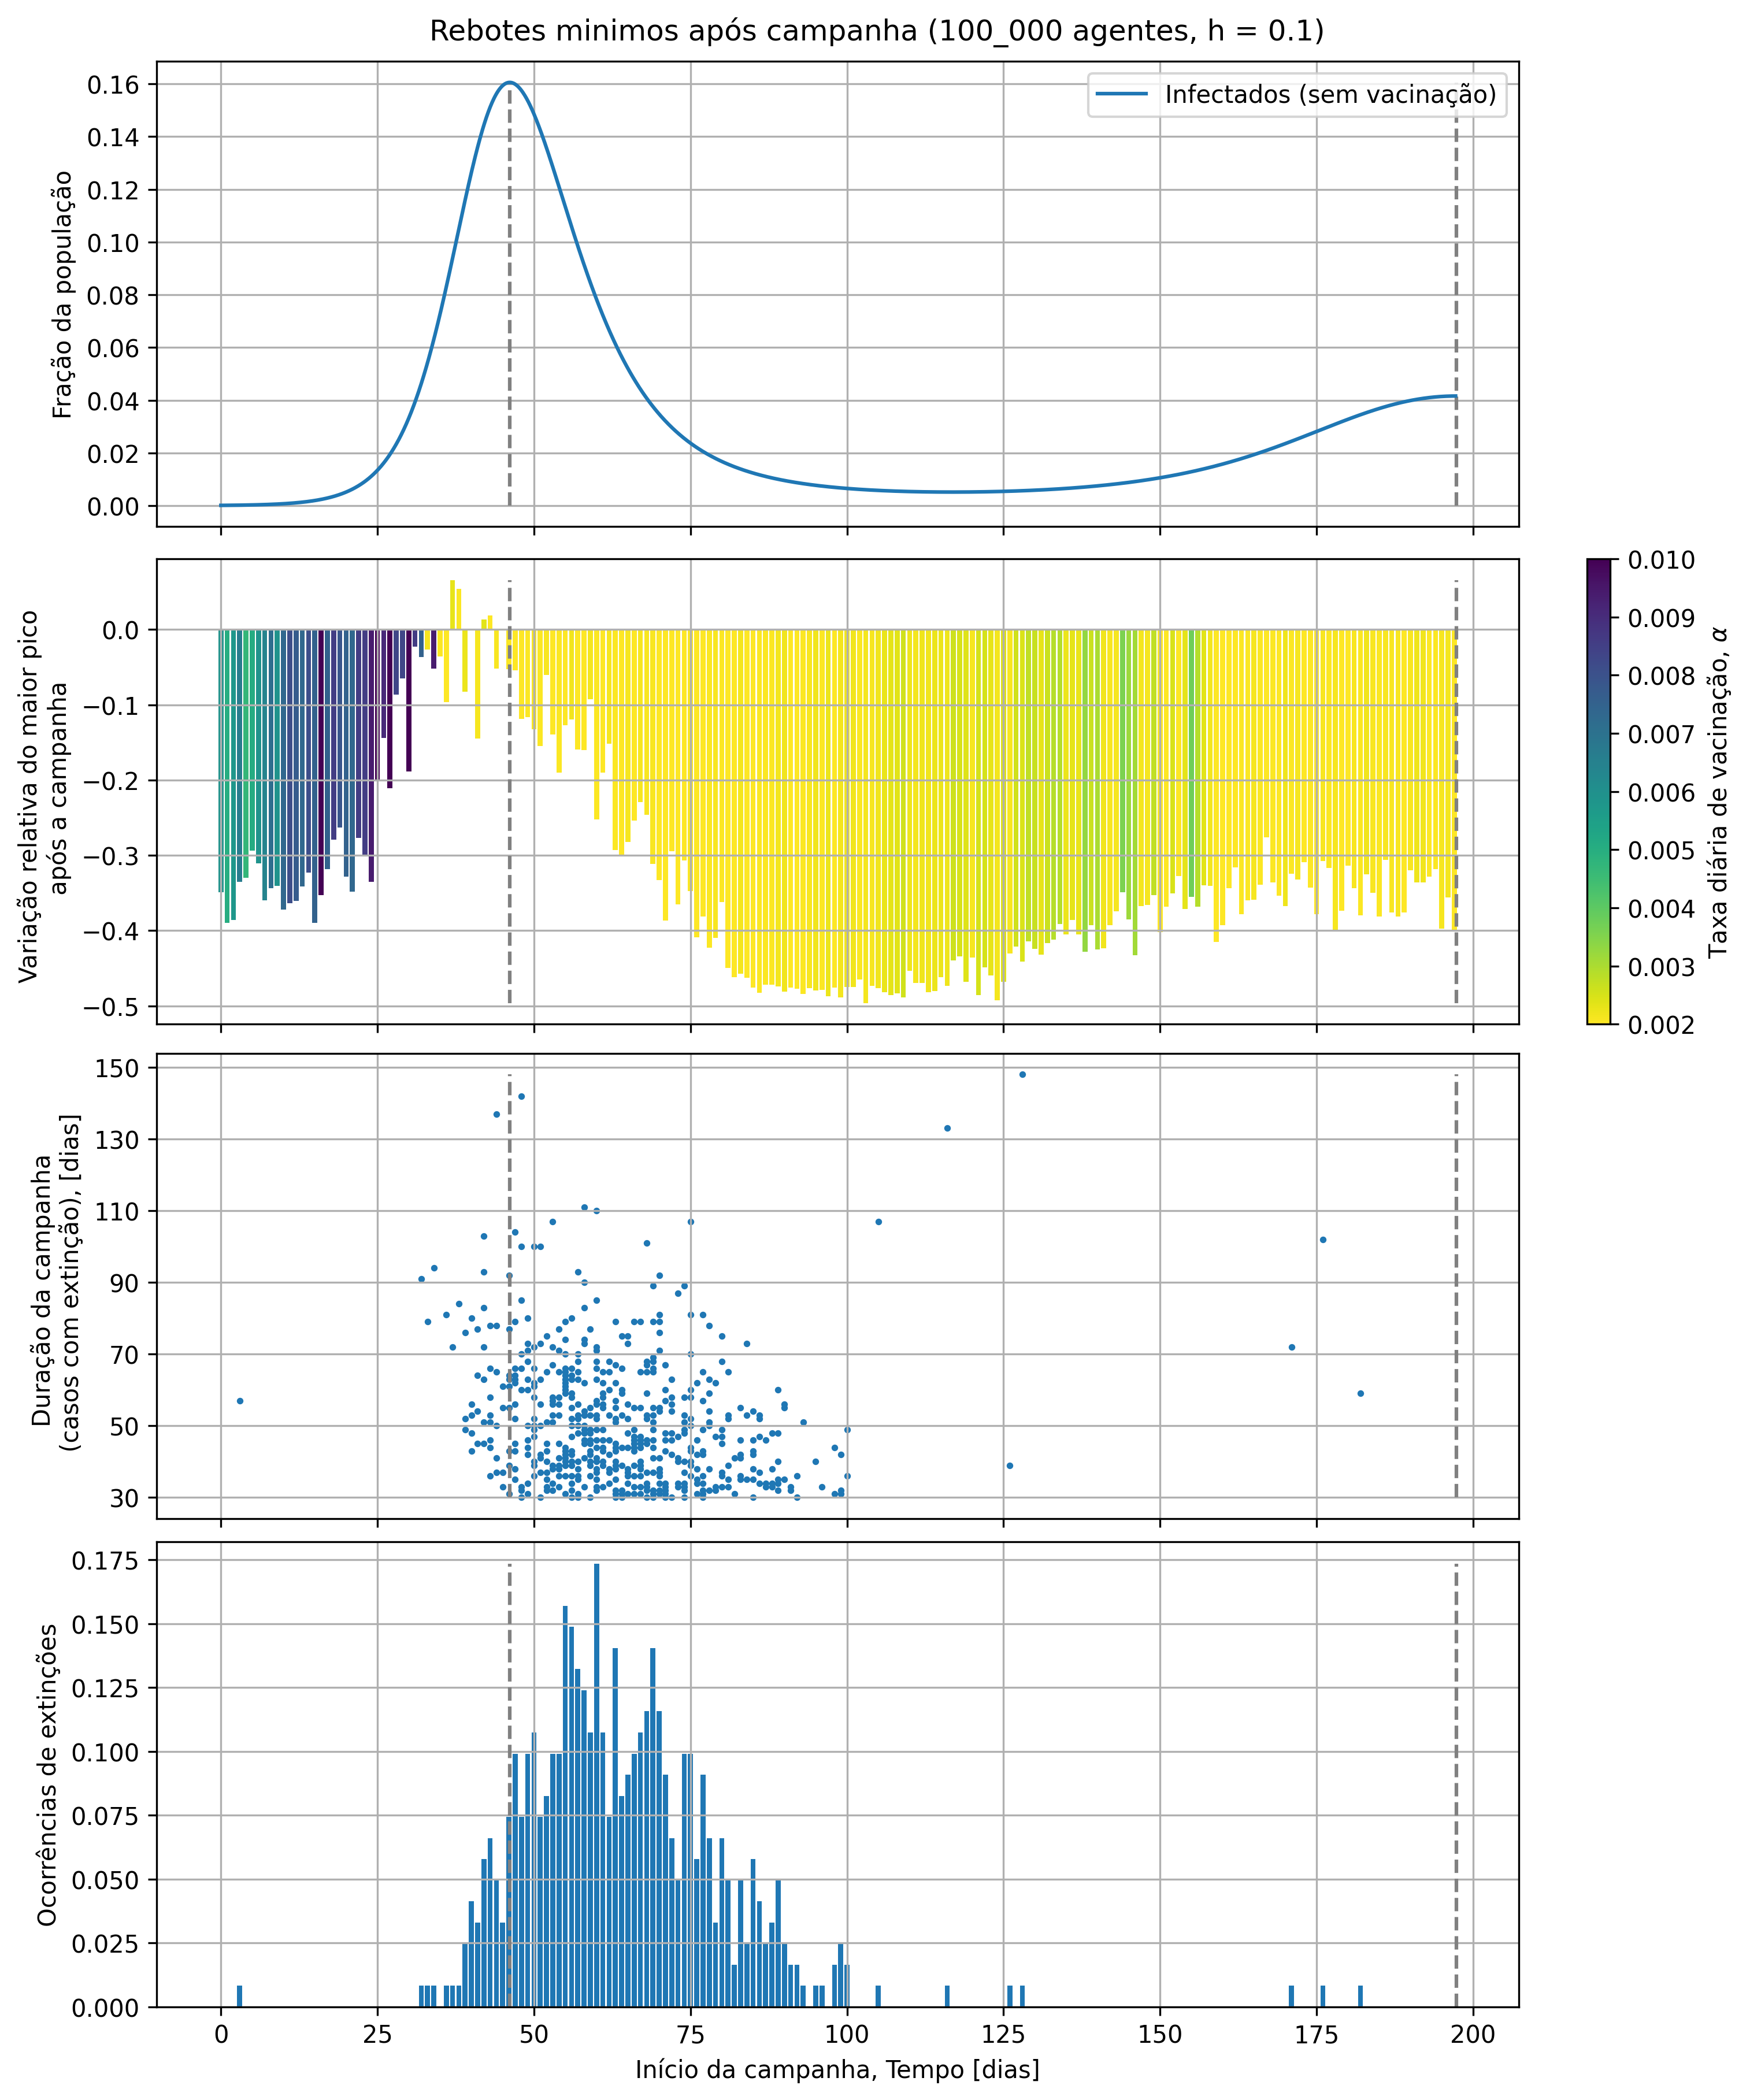

# 7 - Rebote após vacinação em função de $R_{0}$ e $\alpha$

## EDOs

Intensidade rebote x intensidade da vacinação ($\alpha$), supondo recursos fixo = o mínimo para curvar a epidemia


Se após uma campanha de vacinação é possível que ocorra um rebote do número de infectados. A intensidade do rebote deve estar relacionada com a forma como a campanha de vacinação é executada. Uma maior taxa de vacinação deve levar maior acúmulo de removidos ao final da campanha de vacinação, o que a princípio se reflete em um rebote de infectados mais acentuado posteriormente. A extensão temporal da campanha de vacinação também é um fator relevante, pois quanto mais a campanha dura mais ela impacta na proporção de sucetíveis, infectados e removidos.

No artigo, a variação de um pico é analisada mediante a aplicação de campanhas de vacinação com quantidade total fixa para as vacinas, porém a quantidade de vacinas igual a 30% da população parece ser arbitrária. Uma forma alternativa de definir a quantidade total de vacinas é a partir do número de reprodução básico ($R_{0}$), pois se queremos que o número de infectados caia, então

$$ \frac{dI}{dt} = \beta S I - \gamma I < 0 $$
$$ \beta S I < \gamma I $$
$$ S < \frac{\gamma}{\beta} = \frac{1}{R_{0}} $$

Isto é, a fração de infectados diminui quando a fração de sucetíveis é menor que o inverso do número de reprodução básico. Isso significa que, caso vacinássemos uma fração da população correspondente a $1-\frac{1}{R_{0}}$, isso garantiria a extinção da epidemia caso o período de imunidade seja longo o suficiente.

Agora, verificarei o tamanho do rebote (primeiro pico após o fim da campanha de vacinação) para diferentes valores de taxa de vacinação, mas com total de vacinas fixa e igual a $1-\frac{1}{R_{0}}$. De forma análoga à abordagem no artigo, a duração da campanha de vacinação ($D$) e a taxa de vacinação ($\alpha$) se relacionam a partir de

$$ D \alpha = 1 - \frac{1}{R_{0}} $$

Partindo de um sistema com parametros iguais a aqueles utilizados na sessão 1 do artigo, isto é: $S(0)$ = 0.99, $I(0)$ = 0.01, $\beta$ = 1, $\gamma$ = 0.5, $\delta$ = 0.01 e $t_{start}$ = 400, o valor de $\alpha$ será mantido no intervalo [0.001, 0.01], isto é, o máximo de vacinas aplicadas em um único dia deve ser iguala 1% da população, e o mínimo é 0.1% da população.

In [ ]:
S_i, I_i, R_i = 99, 1, 0
beta, gamma, delta = 1, np.arange(0.01, 1, 0.005), 0.01

total_vaccines = 1 - (gamma/beta)
alpha_cte = np.arange(1e-3, 1e-2, 5e-5)
#duration = total_vaccines / alpha_cte

t_end = 1500

t_start = 400
#t_stop = t_start + duration

h = 1e-2
t_i = 0
tt = np.arange(t_i, t_end, h)

N = S_i + I_i + R_i

S_i = S_i/N
I_i = I_i/N
R_i = R_i/N

y0 = S_i, I_i, R_i

before_cond = tt < t_start
after_cond = tt >= t_start

# Gerar simulação para reutilizar dados pré campanha de vacinação
S, I, R = odeint(deriv, y0, tt, args=(beta, 0.5, delta, t_start, 600, 0.008), tfirst=True).T

m_list, t_s_list, a_c_list = [], [], []
rebound_values, rebound_times, I_stop = [], [], []

y0 = S[-1], I[-1], R[-1]

# Loop para iterar sobre cada valor possível de início da campanha de vacinação até um certo pico
for m in tqdm(gamma):

  # Loop para iterar sobre possíveis valores de duração da campanha
  for a_c in alpha_cte:

    S_v = list(S[before_cond])
    I_v = list(I[before_cond])
    R_v = list(R[before_cond])

    # Calcular valores de tempo final da campanha de vacinação
    total_vaccines = 1 - m/beta
    duration = total_vaccines / a_c
    t_s = t_start + duration

    #y0 = S_v[-1], I_v[-1], R_v[-1]

    # Gerar simulação da epidemia com campanha de vacinação
    new_sim = odeint(deriv, y0, tt[after_cond], args=(beta, m, delta, t_start, t_s, a_c), tfirst=True, atol=1e-30).T
    S_v.extend(new_sim[0])
    I_v.extend(new_sim[1])
    R_v.extend(new_sim[2])

    # Transformar listas em arrays e adicionar na lista de candidatos
    S_v, I_v, R_v = np.array(S_v), np.array(I_v), np.array(R_v)

    # Encontrar primeiro pico
    max_condition = (I_v[:-2] < I_v[1:-1]) & (I_v[1:-1] > I_v[2:]) & (tt[1:-1] > t_s)
    max_indexes = np.where(max_condition)[0] + 1
    if len(I_v[max_indexes]) != 0:
      rebound_values.append(I_v[max_indexes][0])
      rebound_times.append(tt[max_indexes][0])
    else:
      rebound_values.append(np.nan)
      rebound_times.append(np.nan)


    I_stop.append(I_v[tt >= t_s][0])
    m_list.append(m)
    t_s_list.append(t_s)
    a_c_list.append(a_c)

    #print('{:.5f},{:.5f},{:.2f},{:.5f}'.format(m, a_c, t_s, rebound_values[-1]))

  #print('gamma = {} -> feito'.format(m))


In [ ]:
df = pd.DataFrame({'gamma': np.array(m_list),
                   'alpha_cte': np.array(a_c_list),
                   't_stop': np.array(t_s_list),
                   'I_rebound': np.array(rebound_values),
                   'I_stop': np.array(I_stop)})
df.to_csv('rebounds.csv', index=False)

Abaixo são importados os dados das simulações e são criados alguns vetores para impressão de vários gráficos. Os vetores com valore de $\gamma$ e $\alpha$ são unidimencionais e tem somente termos únicos. Os vetores com os valores de de infectados durente o rebote e tempo do fim da campanha de vacinação, tem suas dimenções alteradas para que sejam ambos bidimencionais, o que facilina na criação dos gráficos de mapas coloridos.

A criação dos mapas coloridos exige três vetores bidimencionais, um para a a cordenada x, outro para y, e outro para z (associado à cor). Os três devem ter mesmas dimenções, de forma que o valor z[i,j] estará associado às coordenadas x[i,j] e y[i,j] no mapa. O parametro **shading='nearest'** é o que garante que isso seja feito de tal forma, apesar que o método **pcolormesh** seja capaz de interpretar isso automaticamente quando as dimenções de x, y, e z forem iguais. A outra forma com que **pcolormesh** funciona envolve z ter um valor a menos em cada dimenção que x e y, de tal forma que x e y definem os limites dentro do qual o retangulo é pintado para representar z.

A função **np.meshgrid** é utilizada para criar vetores bidimencionais a partir da repetição de vetores unidimencionais, e com ela criamos os vetores x e y. Contudo, da forma como os valores estão escritos no dataframe, onde cada valor de rebote em uma taxa de vacinação e uma taxa de remoção associada, é possível também criar os vetores x e y alterando as dimenções dos vetores *gamma* e *alpha_cte* da mesma forma que foi feito com *I_rebound*. Abaixo está um exemplo de como fazer isso, mas perceba que o vetor *gamma* não está mais no formato apropriado para a iteração que cria o gráfico de linhas.

```
gamma, alpha_cte, t_stop, I_rebound, I_stop = df_rebounds.values.T
shape_row_col = len(np.unique(gamma)), len(np.unique(alpha_cte))

gamma = gamma.reshape(shape_row_col)
alpha_cte = alpha_cte.reshape(shape_row_col)
I_rebound = I_rebound.reshape(shape_row_col)
t_stop = t_stop.reshape(shape_row_col)
```
No bloco que cria os mapas coloridos a atribuição de x e y se torna simplesmente

```
 x, y = alpha_cte, gamma
```





In [ ]:
df_rebounds = pd.read_csv('rebounds.csv')

gamma, alpha_cte, t_stop, I_rebound, I_stop = df_rebounds.values.T
gamma, alpha_cte = np.unique(gamma), np.unique(alpha_cte)
len_gamma, len_alpha_cte = len(gamma), len(alpha_cte)

I_rebound = I_rebound.reshape(len_gamma, len_alpha_cte)
t_stop = t_stop.reshape(len_gamma, len_alpha_cte)
I_stop = I_stop.reshape(len_gamma, len_alpha_cte)

In [ ]:
fig, ax = plt.subplots()

for i in gamma[9::20]:
  ax.plot(df_rebounds[df_rebounds['gamma'] == i]['alpha_cte'],
          df_rebounds[df_rebounds['gamma'] == i]['I_rebound'],
          label = '$\gamma$ = {:.2}'.format(i))

ax.set(xlabel = r'$\alpha$', ylabel='Valor do rebote',
       title = r'$S(0) = 0.99, \ I(0) = 0.01, \ \beta = 1, \ \delta = 0.01, \ t_{start} = 400$')
ax.grid()
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [ ]:
# Gerar vetores bidimencinais para x, y e z
x, y = np.meshgrid(alpha_cte, gamma)
z = I_rebound

fig, ax = plt.subplots()

# Criar mapa
c = ax.pcolormesh(x, y, z,
                  norm = colors.LogNorm(vmin=np.nanmin(z), vmax=np.nanmax(z)),
                  cmap='inferno_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Taxa de remoção, $\gamma$')
#ax.set(ylim=(0.2, 1))
# Criar barra de cor para a leitura do mapa
fig.colorbar(c, ax=ax, label='Rebote (Fração da população)')

plt.show()


fig, ax = plt.subplots()

# Criar mapa recortado

c = ax.pcolormesh(x[100:,:], y[100:,:], z[100:,:], cmap='inferno_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Taxa de remoção, $\gamma$')
#ax.set(ylim=(0.2, 1))
# Criar barra de cor para a leitura do mapa
fig.colorbar(c, ax=ax, label='Rebote (Fração da população)')

plt.show()


z = t_stop - 400

fig, ax = plt.subplots()

c = ax.pcolormesh(x, y, z, cmap='viridis_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Taxa de remoção, $\gamma$')
fig.colorbar(c, ax=ax, label='Duração da campanha de vacinação')

plt.show()

In [ ]:
# Gerar vetores bidimencinais para x, y e z
x, y = np.meshgrid(alpha_cte, 1/gamma)
z = I_rebound

fig, ax = plt.subplots()

# Criar mapa
c = ax.pcolormesh(x, y, z,
                  norm = colors.LogNorm(vmin=np.nanmin(z), vmax=np.nanmax(z)),
                  cmap='inferno_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Número de reprodução básico, $R_{0}$')
ax.set(yscale='log')
# Criar barra de cor para a leitura do mapa
fig.colorbar(c, ax=ax, label='Rebote (Fração da população)')

plt.show()


fig, ax = plt.subplots()

# Criar mapa recortado

c = ax.pcolormesh(x[100:,:], y[100:,:], z[100:,:],
                  cmap='inferno_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Número de reprodução básico, $R_{0}$')
ax.set(yscale='log')
# Criar barra de cor para a leitura do mapa
fig.colorbar(c, ax=ax, label='Rebote (Fração da população)')

plt.show()


z = t_stop - 400

fig, ax = plt.subplots()

c = ax.pcolormesh(x, y, z, cmap='viridis_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Número de reprodução básico, $R_{0}$')
ax.set(yscale='log')
fig.colorbar(c, ax=ax, label='Duração da campanha de vacinação')

plt.show()

In [ ]:
# Gerar vetores bidimencinais para x, y e z
x, y = np.meshgrid(alpha_cte, 1/gamma)
z = np.log10(I_stop)

fig, ax = plt.subplots()

# Criar mapa
c = ax.pcolormesh(x, y, z, cmap='inferno_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Número de reprodução básico, $R_{0}$')
ax.set(yscale='log')
# Criar barra de cor para a leitura do mapa
fig.colorbar(c, ax=ax, label=r'$\log$( I($t_{stop}$) )')

plt.show()


z = t_stop - 400

fig, ax = plt.subplots()

c = ax.pcolormesh(x, y, z, cmap='viridis_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Número de reprodução básico, $R_{0}$')
ax.set(yscale='log')
fig.colorbar(c, ax=ax, label='Duração da campanha de vacinação')

plt.show()

De forma geral, o rebote é mais acentuado quanto maior for o número de reprodução básico, o que é esperado pois um maior valor de $R_{0}$ indica que a recuperação dos infectados é lenta em comparação ao fluxo do surgimento de novos infectados. Em outras palavras, um $R_{0}$ deve ser regletir em um amior acúmulo de infectados.

Por outro lado, maiores rebotes tambémm está associados a maiores taxas de vacinação, especialmente quando $R_{0} < 10$. Isso possivelmente se deve ao maior acúmulo de removidos e futuramente de infectados que é criado em um curto período de tempo.

Nota-se algumas regiões de rebote menos intenso, como faixas que se extendem de regiões de baixo $R_{0}$ e $\alpha$ e se propagam para regiões de maiores $R_{0}$ e $\alpha$. No gráfico de linhas essas regiões são identificadas por mínimos locais nas curvas. Ao meu ver, isso poderia ter um sentido prático da seguinte forma: se estamos enfrentando uma epidemia caracterizada por um dado $R_{0}$, poderiamos buscar tais regiões no intuito de aplicar uma campanha de vacinação com a relação "taxa de vacinação":"rebote de infectados" mais vantajosa. Ainda pode ocorrer da campanha de vacinação levar o número de infectados a valores suficientemente pequenos para extinguir a epidemia.

Até o momento não entendo o surgimento dessas faixas de rebote mínimo. Uma hipótese que tenho é que isto tem relação com o comportamento oscilatório do modelo SIRS, e nos parâmetros utilizados nas simulações faz com as campanhas de vacinação terminem convenientemente em um estado da oscilação que minimize o rebote, um estado mais próximo do estado de equilíbrio sem vacinação. De forma geral, oscilações mais acentuadas e prolongadas ocorrem durante a campanha de vacinação se a taxa de remoção for maior e a taxa de vacinação for menor.

Outra hipótese, é que, se fixamos o valor de $\alpha$ e variamos o $\gamma$, para valores muito pequenos de $\gamma$ o rebote tem valor maior porque o estado estacionário do sistema tem uma fração maior de infectados. Na medida em que aumentamos o $\gamma$ o valor de $I^{*}$ (infectados estacionários) diminui, mas as oscilações ficam mais acentuadas e mais prolongadas. A partir de um certo $\gamma$ é muito provável que a campanha de vacinação termine próxima de um mínimo local de infectados, o que faz com que o rebote seja maior.

Imprimindo um mapa do valor de infectados ao final da campanha de vacinação, percebe-se que aquelas faixas de rebotes mínimos é a fronteira entre duas regiões do mapa, que se diferenciam por uma clara mudança na ordem de grandeza no número de infectados no final da campanha. A região com menor $R_{0}$ (ou maior $\gamma$) tem tal valor de infectados muito menor, provavelmente pelo mesmo motivo apresentado no parágrafo anterior. Isso me parece ter um sentido prático ainda mais interessante, pois se consideramos um $R_{0}$ fixo, podemos encontrar uma taxa de vacinação a partir da qual o número de infectados diminui muito mais durante a vacinação, o que aumenta a chance da epidemia ser extinta pela vacinação. Podemos fazer um raciocínio semelhante considerando que a estrutura disponível para vacinação limita a taxa de vacinação que a campanha é capaz de realizar, em outras palavras, $\alpha$ é fixo. Aqui a busca é por um valor de $R_{0}$ pequeno o suficiente para entrarmos na região de mínimos mais acentuados de infectados, o que na prática significaria a adoção de medidas de prevenção que diminuam a taxa de infecção da doença. É notavel como na região de menor taxa de vacinação um menor $R_{0}$ pode rapidamente diminuir o número de infectados durante a campanha em cerca de 10 ordens de grandeza, e sem que a campanha de vacinação seja das mais prolongadas.

## MBA

In [ ]:
S_i, I_i, R_i = 99000, 1000, 0
beta, gamma, delta = 1, np.arange(0.1, 1, 0.01), 0.01

total_vaccines = 1 - (gamma/beta)
alpha_cte = np.arange(1e-3, 1e-2, 1e-4)
#duration = total_vaccines / alpha_cte

t_end = 1500

t_start = 400
#t_stop = t_start + duration

h = 1e-0
t_i = 0
tt = np.arange(t_i, t_end, h)

N = S_i + I_i + R_i

m_list, t_s_list, a_c_list = [], [], []
rebound_values, rebound_times, I_stop = [], [], []

# Loop para iterar sobre cada valor possível de início da campanha de vacinação até um certo pico
for m in gamma:

  # Loop para iterar sobre possíveis valores de duração da campanha
  for a_c in tqdm(alpha_cte):

    # Calcular valores de tempo final da campanha de vacinação
    total_vaccines = 1 - m/beta
    duration = total_vaccines / a_c
    t_s = t_start + duration

    epi_agents_v = model_agents(N, S_i, I_i, beta, m, delta, t_start, t_s, a_c, h)

    for _ in range(int(t_end/h)):
      epi_agents_v.step()

    # Coletar arrays da simulação e adicionar na lista de candidatos
    tt, S_v, I_v, R_v = get_series(epi_agents_v)

    # Encontrar primeiro pico
    max_condition = (I_v[:-2] < I_v[1:-1]) & (I_v[1:-1] > I_v[2:]) & (tt[1:-1] > t_s)
    max_indexes = np.where(max_condition)[0] + 1
    if len(I_v[max_indexes]) != 0:
      rebound_values.append(max(I_v[max_indexes]))
      rebound_times.append(tt[I_v[max_indexes].argmax()])
    else:
      rebound_values.append(np.nan)
      rebound_times.append(np.nan)


    I_stop.append(I_v[tt >= t_s][0])
    m_list.append(m)
    t_s_list.append(t_s)
    a_c_list.append(a_c)

    #print('{:.5f},{:.5f},{:.2f},{:.5f}'.format(m, a_c, t_s, rebound_values[-1]))

  print('gamma = {} -> feito'.format(m))


In [ ]:
df = pd.DataFrame({'gamma': np.array(m_list),
                   'alpha_cte': np.array(a_c_list),
                   't_stop': np.array(t_s_list),
                   'I_rebound': np.array(rebound_values),
                   'I_stop': np.array(I_stop)})
df.to_csv('rebounds_100000agents.csv', index=False)

In [ ]:
df_rebounds = pd.read_csv('rebounds_100000agents.csv')

gamma, alpha_cte, t_stop, I_rebound, I_stop = df_rebounds.values.T
gamma, alpha_cte = np.unique(gamma), np.unique(alpha_cte)
len_gamma, len_alpha_cte = len(gamma), len(alpha_cte)

I_rebound = I_rebound.reshape(len_gamma, len_alpha_cte)
t_stop = t_stop.reshape(len_gamma, len_alpha_cte)
I_stop = I_stop.reshape(len_gamma, len_alpha_cte)

In [ ]:
fig, ax = plt.subplots()

for i in gamma[9::20]:
  ax.plot(df_rebounds[df_rebounds['gamma'] == i]['alpha_cte'],
          df_rebounds[df_rebounds['gamma'] == i]['I_rebound'],
          label = '$\gamma$ = {:.2}'.format(i))

ax.set(xlabel = r'$\alpha$', ylabel='Valor do rebote',
       title = r'$S(0) = 0.99, \ I(0) = 0.01, \ \beta = 1, \ \delta = 0.01, \ t_{start} = 400$')
ax.grid()
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [ ]:
# Gerar vetores bidimencinais para x, y e z
x, y = np.meshgrid(alpha_cte, gamma)
z = I_rebound

fig, ax = plt.subplots()

# Criar mapa
c = ax.pcolormesh(x, y, z, cmap='inferno_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Taxa de remoção, $\gamma$')
# Criar barra de cor para a leitura do mapa
fig.colorbar(c, ax=ax, label='Rebote (Fração da população)')

plt.show()


z = t_stop - 400

fig, ax = plt.subplots()

c = ax.pcolormesh(x, y, z, cmap='viridis_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Taxa de remoção, $\gamma$')
fig.colorbar(c, ax=ax, label='Duração da campanha de vacinação')

plt.show()

In [ ]:
# Gerar vetores bidimencinais para x, y e z
x, y = np.meshgrid(alpha_cte, 1/gamma)
z = I_rebound

fig, ax = plt.subplots()

# Criar mapa
c = ax.pcolormesh(x, y, z, cmap='inferno_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Número de reprodução básico, $R_{0}$')
ax.set(yscale='log')
# Criar barra de cor para a leitura do mapa
fig.colorbar(c, ax=ax, label='Rebote (Fração da população)')

plt.show()


z = t_stop - 400

fig, ax = plt.subplots()

c = ax.pcolormesh(x, y, z, cmap='viridis_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Número de reprodução básico, $R_{0}$')
ax.set(yscale='log')
fig.colorbar(c, ax=ax, label='Duração da campanha de vacinação')

plt.show()

In [ ]:
# Gerar vetores bidimencinais para x, y e z
x, y = np.meshgrid(alpha_cte, 1/gamma)
z = np.log10(I_stop)

fig, ax = plt.subplots()

# Criar mapa
c = ax.pcolormesh(x, y, z, cmap='inferno_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Número de reprodução básico, $R_{0}$')
ax.set(yscale='log')
# Criar barra de cor para a leitura do mapa
fig.colorbar(c, ax=ax, label=r'$\log$( I($t_{stop}$) )')

plt.show()


z = t_stop - 400

fig, ax = plt.subplots()

c = ax.pcolormesh(x, y, z, cmap='viridis_r', shading='nearest')
ax.set(xlabel = r'Taxa vacinação, $\alpha$', ylabel = r'Número de reprodução básico, $R_{0}$')
ax.set(yscale='log')
fig.colorbar(c, ax=ax, label='Duração da campanha de vacinação')

plt.show()

## ODE(campanha com duração fixa)

In [ ]:
sims_teste = np.load('euler_h1.npz')
tt = np.arange(np.shape(sims_teste['infected'])[1], step=1)
ext = np.apply_along_axis(identify_ext, 1, sims_teste['infected'])
#rebounds, rebound_indexes = find_rebound_vec(sims_teste['infected'], tt, t_stop, 'ode', 21)

In [ ]:
condition = (sims_teste['parameters'][:,:3].round(8) == np.array([0.1, 2, 0.004])).all(axis=1)
ext_param = sims_teste['parameters'][condition]
ext_param
plot_series = sims_teste['infected'][condition]

In [ ]:
print(ext_param)
plot_series

In [ ]:
#conditoin_plot = (sims_teste['parameters'][:,:3] == np.array([1.2, 2, 0.002])).all(axis=1)


fig, ax = plt.subplots()
for i in plot_series:
    ax.plot(tt, i)
    ax.set(yscale='log')

In [ ]:
px.line(x=tt, y=plot_series[-1])

In [ ]:
sims = load_sim('euler_h1.npz', exclude_removed=True)

In [ ]:
h = 1
tt = np.arange(np.shape(sims[2])[1], step=1)

In [ ]:
rebounds, rebound_indexes = find_rebound_vec(sims[2], tt, t_stop, 'ode', 21)

In [ ]:
graph_rebound_colormaps(sims, rebounds, rebound_indexes, 'alpha_cte', 'R_0', 'beta', 'delta', save = True)

In [ ]:
graph_rebound_colormaps(sims, rebounds, rebound_indexes, 'alpha_cte', 'delta', 'beta', 'R_0', save = True)

In [ ]:
graph_rebound_colormaps(sims, rebounds, rebound_indexes, 'alpha_cte', 'delta', 'R_0', 'beta', save = True)

## MBA (campanha com duração fixa)

In [ ]:
S_i, I_i, R_i = 99990, 10, 0

beta, R_0, delta = np.linspace(0.1, 1.2, 23), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)
#beta, R_0, delta = np.array([0.1]), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)
#beta, R_0, delta = np.array([0.1]), np.array([0.5]), np.array([0.01])

#t_start, t_stop, alpha = np.array([0.0]), np.array([0.0]), np.array([0.00])
t_start, t_stop, alpha = np.array([400.0]), np.array([600.0]), np.linspace(0.0005, 0.01, 20)

sample_size = 1

t_end = 1250

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                   for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sims = load_sim('100000agents_h01.npz', exclude_removed=True)

In [ ]:
beta, R_0, delta, t_start, t_stop, alpha_cte = sims[0].T[:-1]
gamma = beta/R_0
tt = np.arange(np.shape(sims[2])[1])

In [ ]:
h = 1e-1
tt = np.arange(np.shape(sims[2])[1]) * h

In [ ]:
above_alpha_er_lim = alpha_cte >  (1 - 1/R_0)*delta 
t_ext = np.apply_along_axis(get_ext_time, 1, sims[2], *[tt])
above_alpha_er_lim_and_maintained = above_alpha_er_lim & np.isnan(t_ext)
above_alpha_er_lim_and_maintained

In [ ]:
fig, ax = plt.subplots()
for test_index in np.arange(50,60):
    ax.plot(tt, sims[1][above_alpha_er_lim_and_maintained][test_index], c='g')
    ax.plot(tt, sims[2][above_alpha_er_lim_and_maintained][test_index], c='r')
    #ax.plot(tt, sims[3][above_alpha_er_lim_and_maintained][test_index])
ax.set(yscale='log')

In [ ]:
redo_sims_parameters = [above_alpha_er_lim_and_maintained]

In [ ]:
I_stat = stationary(beta, gamma, delta)[1]
#I_stat = np.where(I_stat < 0, 0, I_stat)
I_stat

In [ ]:
stationary(beta[0], gamma[0], delta[0])

In [ ]:
#rebounds = np.apply_along_axis(find_rebound, 1, sims[2], *[tt, 600, 'agents', 11])
#rebounds, rebound_indexes = rebounds.T
window_size = 201
rebounds, rebound_indexes = find_rebound_vec(sims[2], tt, t_stop, 'agents', window_size, beta = beta, gamma = gamma, delta = delta)

In [ ]:
reb_stat_dif = rebounds - I_stat

In [ ]:
len(np.load('100000agents_h01_beta3_R02_nsample10.npz')['parameters'])

In [ ]:
graph_rebound_colormaps(sims, rebounds, rebound_indexes, 'alpha_cte', 'R_0', 'beta', 'delta', save=False)

In [ ]:
graph_rebound_colormaps(sims, rebounds, rebound_indexes, 'alpha_cte', 'delta', 'beta', 'R_0', save=True, erradication_limits=True)

In [ ]:
graph_rebound_colormaps(sims, rebounds, rebound_indexes, 'alpha_cte', 'delta', 'R_0', 'beta', save=True, erradication_limits=True)

In [ ]:
graph_rebound_colormaps(sims, rebounds, rebound_indexes, 'alpha_cte', 'delta', 'beta', 'R_0', save=True, relative_to_stationary=True, erradication_limits=True, colorbarscale='log')

In [ ]:
graph_rebound_colormaps(sims, rebounds, rebound_indexes, 'alpha_cte', 'delta', 'R_0', 'beta', relative_to_stationary=True)

In [ ]:
graph_rebound_colormaps(sims, rebounds, rebound_indexes, 'alpha_cte', 'delta', 'R_0', 'beta', relative_to_stationary=True, colorbarscale='log')

In [ ]:
graph_rebound_animation(sims, h, rebounds, rebound_indexes, mov_ave_window_size = window_size, name = 'rebounds')

### Gráficos ternários de rebote

In [ ]:
def graph_tern_rebound(sims, rebounds, h, rightparam, leftparam, topparam, fixedparam, erradication_limit = False, save = False):
    
    # Criar lista com nome dos parametros e dicionário com parametros originais
    keys = ['beta', 'R_0', 'delta', 't_start', 't_stop', 'alpha_cte', 'n_sample']
    n_keys = len(keys)
    params = {keys[i]: sims[0][:,i].round(10) for i in range(n_keys)}
    params_norm = {keys[i]: params[keys[i]]/max(params[keys[i]]) for i in range(n_keys)}
    alpha_er = params['delta']*(1-1/params['R_0'])/max(params['alpha_cte'])

    symbol_list = ['$\\beta$', '$R_{0}$', '$\\delta$', '$t_{start}$', '$t_{stop}$', '$\\alpha_{cte}$', '$n$']
    label_list = ['$\\beta/\\beta_{max}$', '$R_{0}/R_{0 \ max}$', '$\\delta/\\delta_{max}$', 
                  '$t_{start}/t_{start \ max}$', '$t_{stop}/t_{stop max}$', '$\\alpha_{cte}/\\alpha_{cte max}$', '$n/n_{max}$']
    symbols = {keys[i]: symbol_list[i] for i in range(n_keys)}
    labels = {keys[i]: label_list[i] for i in range(n_keys)}

    fixedparam_uniques = np.unique(params[fixedparam])
    n_fixedparam = len(fixedparam_uniques)

    tt = np.arange(len(sims[2][0]), step = h)
    t_ext = np.apply_along_axis(get_ext_time, 1, sims[2], *[tt])
    condlist = [t_ext<sims[0][:,3], t_ext>sims[0][:,4], np.isnan(t_ext)]
    choicelist = [-1, 1, np.nan]
    t_ext_class = np.select(condlist, choicelist, 0)

    norm_t_ext = colors.BoundaryNorm(np.linspace(-1, 1, 4), 3)  
    cmap_t_ext = colors.ListedColormap(['green', 'cyan', 'blue'])

    now = datetime.now()
    time_string = now.strftime("%d-%m-%Y_%Hh%Mm")
    dir_name = 'rebound_ternary_graph_{}'.format(time_string)

    if save:
        os.mkdir(dir_name)

    for i in range(n_fixedparam):

        current_fixedparam_value = fixedparam_uniques[i]
        cut_condition = params[fixedparam] == current_fixedparam_value
        
        fig = plt.figure(figsize=(12, 5), layout='constrained')    
        ax = fig.add_subplot(projection='ternary')
        
        top, left, right, reb = params_norm[topparam][cut_condition], params_norm[leftparam][cut_condition], params_norm[rightparam][cut_condition], rebounds[cut_condition]
        a_er = alpha_er[cut_condition]

        t_ext_class_cut = t_ext_class[cut_condition]
        t_ext_condition_before = t_ext_class_cut < 0
        t_ext_condition_after = t_ext_class_cut > 0
        t_ext_condition_while = t_ext_class_cut == 0
        
        vmin = np.nanmin(reb)
        vmax = np.nanmax(reb)

        c_ext = ax.scatter(top[t_ext_condition_before], left[t_ext_condition_before], right[t_ext_condition_before], s=8, alpha=1/2, marker='^', color = "green", edgecolors='black', linewidths=0.1)
        c_ext = ax.scatter(top[t_ext_condition_while], left[t_ext_condition_while], right[t_ext_condition_while], s=8, alpha=1/2, marker='P', color = "cyan", edgecolors='black', linewidths=0.1)
        c_ext = ax.scatter(top[t_ext_condition_after], left[t_ext_condition_after], right[t_ext_condition_after], s=8, alpha=1/2, marker='s', color = "blue", edgecolors='black', linewidths=0.1)
        cs = ax.scatter(top, left, right, c=reb, vmin=vmin, vmax=vmax, cmap='inferno_r', s=8, alpha=1/2, edgecolors='black', linewidths=0.1)
        
        if erradication_limit:
            ax.scatter(top, left, a_er, color='black', s=4, marker='*', linewidths=0.1)
        
        ax.set_title(r"{} = {}".format(symbols[fixedparam], current_fixedparam_value))
        ax.set(tlabel=r'{}'.format(labels[topparam]), 
               llabel=r'{}'.format(labels[leftparam]), 
               rlabel=r'{}'.format(labels[rightparam]))
        ax.taxis.set_ticks_position('tick1')
        ax.laxis.set_ticks_position('tick1')
        ax.raxis.set_ticks_position('tick1')
        ax.taxis.set_label_position('tick1')
        ax.laxis.set_label_position('tick1')
        ax.raxis.set_label_position('tick1')
    
        ax.grid()
        
        cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
        colorbar = fig.colorbar(cs, cax=cax)
        colorbar.set_label('Rebote (em fração da população)', rotation=270, va='baseline')

        if erradication_limit:
            fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='^', color='green', label=r'Extinção ($t_{ext} < t_{start}$)', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='P', color='cyan', label=r'Extinção ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='s', color='blue', label=r'Extinção ($t_{ext} > t_{stop}$)', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='*', color='black', label=r'Limite para $\alpha_{er}$', markersize=10)],
                       bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=2, borderaxespad=0)

        else:
            fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='^', color='green', label=r'Extinção ($t_{ext} < t_{start}$)', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='P', color='cyan', label=r'Extinção ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                                plt.Line2D([0], [0], linestyle='', marker='s', color='blue', label=r'Extinção ($t_{ext} > t_{stop}$)', markersize=10)],
                       bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=3, borderaxespad=0)
    
        name_graph = '{}/rebounds_{}{:.4f}_{}.jpg'.format(dir_name, fixedparam, 
                                                         current_fixedparam_value, time_string)
    
        if save:
                plt.savefig(name_graph, dpi=600, format = 'jpg', bbox_inches='tight')
        
        plt.show()

In [ ]:
def graph_tern_rebound_joint(sims, rebounds, h, rightparam, leftparam, topparam, fixedparam, 
                             joint_shape, language = 'pt', erradication_limit = False, save = False):
    
    # Criar lista com nome dos parametros e dicionário com parametros originais
    keys = ['beta', 'R_0', 'delta', 't_start', 't_stop', 'alpha_cte', 'n_sample']
    n_keys = len(keys)
    params = {keys[i]: sims[0][:,i].round(10) for i in range(n_keys)}
    params_norm = {keys[i]: params[keys[i]]/max(params[keys[i]]) for i in range(n_keys)}
    alpha_er = params['delta']*(1-1/params['R_0'])/max(params['alpha_cte'])

    symbol_list = ['$\\beta$', '$R_{0}$', '$\\delta$', '$t_{start}$', '$t_{stop}$', '$\\alpha_{cte}$', '$n$']
    label_list = ['$\\beta/\\beta_{max}$', '$R_{0}/R_{0 \ max}$', '$\\delta/\\delta_{max}$', 
                  '$t_{start}/t_{start \ max}$', '$t_{stop}/t_{stop max}$', '$\\alpha_{cte}/\\alpha_{cte max}$', '$n/n_{max}$']
    symbols = {keys[i]: symbol_list[i] for i in range(n_keys)}
    labels = {keys[i]: label_list[i] for i in range(n_keys)}

    fixedparam_uniques = np.unique(params[fixedparam])
    n_fixedparam = len(fixedparam_uniques)

    tt = np.arange(len(sims[2][0]), step = h)
    t_ext = np.apply_along_axis(get_ext_time, 1, sims[2], *[tt])
    condlist = [t_ext<sims[0][:,3], t_ext>sims[0][:,4], np.isnan(t_ext)]
    choicelist = [-1, 1, np.nan]
    t_ext_class = np.select(condlist, choicelist, 0)

    norm_t_ext = colors.BoundaryNorm(np.linspace(-1, 1, 4), 3)  
    cmap_t_ext = colors.ListedColormap(['green', 'cyan', 'blue'])

    now = datetime.now()
    time_string = now.strftime("%d-%m-%Y_%Hh%Mm")
    
    figsize = joint_shape[1]*4, joint_shape[0]*4 + 2
    fig = plt.figure(figsize=figsize, layout='constrained')

    vmin = np.nanmin(rebounds)
    vmax = np.nanmax(rebounds)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    axs = []
            
    if joint_shape[1] >= 2:
        ncols_legend = 4
        colorbar_aspect = joint_shape[1]*20
    else:
        ncols_legend = 2

    legend_labels = {'pt': {'colorbar_label': 'Rebote (em fração da população)',
                             'extinction': 'Extinção',
                             'lim_to': 'Limite para'},
                      'en': {'colorbar_label': r'Rebound - $I^{*}$',
                             'extinction': 'Extinction',
                             'lim_to': 'Limit to'}}

    for i in range(n_fixedparam):
    
        current_fixedparam_value = fixedparam_uniques[i]
        cut_condition = params[fixedparam] == current_fixedparam_value
            
        ax = fig.add_subplot(joint_shape[0], joint_shape[1], i+1, projection='ternary')
        
        top, left, right, reb = params_norm[topparam][cut_condition], params_norm[leftparam][cut_condition], params_norm[rightparam][cut_condition], rebounds[cut_condition]
        a_er = alpha_er[cut_condition]
    
        t_ext_class_cut = t_ext_class[cut_condition]
        t_ext_condition_before = t_ext_class_cut < 0
        t_ext_condition_after = t_ext_class_cut > 0
        t_ext_condition_while = t_ext_class_cut == 0

        print(len(t_ext_class_cut))
        print('Ext before = {}, {}%'.format(np.sum(t_ext_condition_before), round(100*np.sum(t_ext_condition_before)/len(t_ext_class_cut), 3)))
        print('Ext after = {}, {}%'.format(np.sum(t_ext_condition_after), round(100*np.sum(t_ext_condition_after)/len(t_ext_class_cut), 3)))
        print('Ext while = {}, {}%'.format(np.sum(t_ext_condition_while), round(100*np.sum(t_ext_condition_while)/len(t_ext_class_cut), 3)))
    
        c_ext = ax.scatter(top[t_ext_condition_before], left[t_ext_condition_before], right[t_ext_condition_before], s=8, alpha=1/2, marker='^', color = "green", edgecolors='black', linewidths=0.1)
        c_ext = ax.scatter(top[t_ext_condition_while], left[t_ext_condition_while], right[t_ext_condition_while], s=8, alpha=1/2, marker='P', color = "cyan", edgecolors='black', linewidths=0.1)
        c_ext = ax.scatter(top[t_ext_condition_after], left[t_ext_condition_after], right[t_ext_condition_after], s=8, alpha=1/2, marker='s', color = "blue", edgecolors='black', linewidths=0.1)
        cs = ax.scatter(top, left, right, c=reb, vmin=vmin, vmax=vmax, cmap='inferno_r', s=8, alpha=1/2, edgecolors='black', linewidths=0.1)
        
        if erradication_limit:
            ax.scatter(top, left, a_er, color='black', s=4, marker='*', linewidths=0.1)
        
        ax.set_title(r"{} = {}".format(symbols[fixedparam], current_fixedparam_value))
        ax.set(tlabel=r'{}'.format(labels[topparam]), 
               llabel=r'{}'.format(labels[leftparam]), 
               rlabel=r'{}'.format(labels[rightparam]))
        ax.taxis.set_ticks_position('tick1')
        ax.laxis.set_ticks_position('tick1')
        ax.raxis.set_ticks_position('tick1')
        ax.taxis.set_label_position('tick1')
        ax.laxis.set_label_position('tick1')
        ax.raxis.set_label_position('tick1')
    
        ax.grid()

        axs.append(ax)

        ax.annotate(
            chr(97+i)+')', xy=(0., 1.), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top', fontfamily='serif')
    
    #cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
    colorbar = fig.colorbar(cs, ax=axs, location='top', aspect = colorbar_aspect)
    colorbar.set_label(legend_labels[language]['colorbar_label'])
        

    if erradication_limit:
        fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='^', color='green', label=legend_labels[language]['extinction']+r' ($t_{ext} < t_{start}$)', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='P', color='cyan', label=legend_labels[language]['extinction']+r' ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='s', color='blue', label=legend_labels[language]['extinction']+r' ($t_{ext} > t_{stop}$)', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='*', color='black', label=legend_labels[language]['lim_to']+r' $\alpha_{er}$', markersize=10)],
                   bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=ncols_legend, borderaxespad=0)

    else:
        fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='^', color='green', label=legend_labels[language]['extinction']+r' ($t_{ext} < t_{start}$)', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='P', color='cyan', label=legend_labels[language]['extinction']+r' ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                            plt.Line2D([0], [0], linestyle='', marker='s', color='blue', label=legend_labels[language]['extinction']+r' ($t_{ext} > t_{stop}$)', markersize=10)],
                   bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=3, borderaxespad=0)

    name_graph = 'rebounds_{}{:.4f}_{}.jpg'.format(fixedparam, 
                                                     current_fixedparam_value, time_string)

    if save:
            plt.savefig(name_graph, dpi=600, format = 'jpg', bbox_inches='tight')
    
    plt.show()

In [ ]:
graph_tern_rebound_joint(sims, reb_stat_dif, h, 'alpha_cte', 'delta', 'beta', 'R_0', joint_shape=(1, 2), language='en', erradication_limit=True, save=True)

In [ ]:
graph_tern_rebound(sims, rebounds, h, 'alpha_cte', 'delta', 'beta', 'R_0', erradication_limit=True, save=True)

In [ ]:
condition_alpha = sims[0][:,5] > 0.005
condition_R_0 = sims[0][:,1] == 2
condition_beta = sims[0][:,0] < 0.5
condition_delta = sims[0][:,2] < 0.02
condition_rebound = rebounds < 0.05

condition_small = condition_alpha & condition_beta & condition_delta & condition_rebound & condition_R_0

condition_alpha = sims[0][:,5] < 0.005
condition_R_0 = sims[0][:,1] == 2
condition_beta = sims[0][:,0] < 0.5
condition_delta = sims[0][:,2] > 0.02
condition_rebound = rebounds > 0.2

condition_big = condition_alpha & condition_beta & condition_delta & condition_rebound & condition_R_0

#sims[0][condition_alpha & condition_beta & condition_delta & condition_rebound & condition_R_0]

In [ ]:
ind = 0

reb_ind_small = int(rebound_indexes[condition_small][ind])
reb_ind_big = int(rebound_indexes[condition_big][ind])

param_data_small = sims[0][condition_small][ind]
inf_data_small = sims[2][condition_small][ind]
param_data_big = sims[0][condition_big][ind]
inf_data_big = sims[2][condition_big][ind]

#fig, ax = plt.subplots(3, sharex=True, layout='constrained')
mosaic_ids = np.array([['a'], ['bi'], ['bii']])

fig, ax = plt.subplot_mosaic(mosaic_ids, figsize = (6, 5), sharex=True, layout='constrained')

ode_param = param_data_small[:-1]
ode_param[1] = ode_param[0]/ode_param[1]
ode_param[-1] = 0

sim_ode = SIRS_v(1, 0.9999, 1e-4, *ode_param, 0.1, 1250)

ax['bi'].plot(sim_ode[0], sim_ode[2], color='black')
ax['bii'].plot(sim_ode[0], sim_ode[2], color='black')

ax['a'].plot(tt, inf_data_big, color='r')
ax['a'].plot(tt[reb_ind_big], inf_data_big[reb_ind_big], 'o')

ax['bi'].plot(tt, inf_data_small, color='r')
ax['bii'].plot(tt, inf_data_small, color='r')
ax['bii'].set(yscale='log')
ax['bi'].plot(tt[reb_ind_small], inf_data_small[reb_ind_small], 'o')
ax['bii'].plot(tt[reb_ind_small], inf_data_small[reb_ind_small], 'o')

#for a in ax:
    #a.grid()
    #a.fill_between(tt, 0, max(inf_data_small), where=((tt < 600) & (tt > 400)), color='0.85', zorder = 1)

ax['a'].fill_between(tt, 0, max(inf_data_big), where=((tt < 600) & (tt > 400)), color='0.85', zorder = 1)
ax['bi'].fill_between(tt, 0, max(inf_data_small), where=((tt < 600) & (tt > 400)), color='0.85', zorder = 1)
ax['bii'].fill_between(tt, 0, max(inf_data_small), where=((tt < 600) & (tt > 400)), color='0.85', zorder = 1)

for label, a in ax.items():
     a.grid()
     a.annotate(
            label,
            xy=(1, 0), xycoords='axes fraction',
            xytext=(-2, 2), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))


ax['a'].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0,
             title='$\\beta = {:.2f}$\n$\\delta = {:.3f}$\n$\\alpha = {:.4f}$'.format(*sims[0][condition_big][ind][[0,2,5]]))

ax['bi'].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0,
             title='$\\beta = {:.2f}$\n$\\delta = {:.3f}$\n$\\alpha = {:.4f}$'.format(*sims[0][condition_small][ind][[0,2,5]]))

fig.legend(handles=[plt.Line2D([0], [0], linestyle='-', color='red', label='MBA (com vacina)'),
                    plt.Line2D([0], [0], linestyle='-', color='black', label='EDO (sem vacina)'),
                    plt.Line2D([0], [0], linestyle='', marker='o', color='tab:blue', label='Rebote')],
           bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=3, borderaxespad=0,
           title = r'$R_{{0}} = {}, \ h = {}$'.format(2.0, 0.1), title_fontsize=10)

fig.supxlabel('Tempo, t')
fig.supylabel('Fração de infectados')
plt.savefig('failed_rebound_identification3', dpi=200, bbox_inches='tight')

In [ ]:
condition2 = (sims[0] == [0.4, 2.0, 0.01, 400.0, 600.0, 0.004, 0.0]).all(axis=1)
condition3 = (sims[0] == [0.4, 5.0, 0.01, 400.0, 600.0, 0.004, 0.0]).all(axis=1)

In [ ]:
fig, ax = plt.subplots(figsize = (5, 3), layout='constrained')

ax.plot(tt, sims[2][condition2].reshape(np.shape(sims[2][condition2])[1]), color='red', label='$R_{{0}} = 2.0$')
ax.plot(tt, sims[2][condition3].reshape(np.shape(sims[2][condition3])[1]), color='darkred', label='$R_{{0}} = 5.0$')
ax.fill_between(tt, 0, max(sims[2][condition3].reshape(np.shape(sims[2][condition3])[1])), where=((tt < 600) & (tt > 400)), color='0.85', zorder = 1)
ax.set(xlabel='Tempo, t', ylabel='Fração de infectados')
ax.grid()
ax.legend()

plt.savefig('rebound_by_R_0', dpi=200, bbox_inches='tight')

### Gráficos ternários de correlação

In [ ]:
#euler = np.load('euler_h1.npz')
#agents = np.load('100000agents_h1.npz')
euler = np.load('euler_h01.npz')
agents = np.load('100000agents_h01.npz')
h = 1e-1

In [ ]:
serie_name = ['susceptible', 'infected', 'removed']
r, p = {}, {}

for name in serie_name:
    try:
        del euler_array, agents_array
    except:
        pass
    euler_array, agents_array = euler[name], agents[name]
    n_sims = len(euler_array)
    r[name], p[name] = np.empty(n_sims), np.empty(n_sims)
    
    for i in tqdm(range(n_sims)):
        
        r[name][i], p[name][i] = pearsonr(euler_array[i], agents_array[i])

del euler_array, agents_array

In [ ]:
graph_tern_series_correl_vac_joint(agents, r['infected'], h, 'alpha_cte', 'delta', 'beta', 'R_0', joint_shape=(1, 2),
                             serie_name = 'infected', language='en', erradication_limit = True, save = True)

In [ ]:
graph_tern_series_correl_vac(agents, r['susceptible'], h, 'alpha_cte', 'delta', 'beta', 'R_0', 
                             serie_name = 'susceptible', erradication_limit = True, save = True)

In [ ]:
graph_tern_series_correl_vac(agents, r['infected'], h, 'alpha_cte', 'delta', 'beta', 'R_0', 
                             serie_name = 'infected', erradication_limit = True, save = True)

In [ ]:
graph_tern_series_correl_vac(agents, r['removed'], h, 'alpha_cte', 'delta', 'beta', 'R_0', 
                             serie_name = 'removed', erradication_limit = True, save = True)

In [ ]:
tt = np.arange(len(agents['infected'][0])) * h
t_ext = np.apply_along_axis(get_ext_time, 1, agents['infected'], *[tt])
t_ext = np.where((t_ext > 0) & (t_ext < 1250), t_ext, np.nan)
condlist = [t_ext<agents['parameters'][:,3], t_ext>agents['parameters'][:,4], np.isnan(t_ext)]
choicelist = [-1.0, 1.0, np.nan]
t_ext_class = np.select(condlist, choicelist, 0.0)

In [ ]:
fix_R_0 = 2
condition_R_0 = agents['parameters'][:,1] == fix_R_0
high_R_0 = 5
high_R_0_condition = agents['parameters'][:,1] == high_R_0
fix_delta = 0.01
condition_delta = agents['parameters'][:,2] == fix_delta
high_R_0_delta = 0.004
high_R_0_condition_delta = agents['parameters'][:,2] == high_R_0_delta


condition_before = t_ext_class < 0
condition_after = t_ext_class > 0
condition_while = t_ext_class == 0
condition_maintenance = np.isnan(t_ext_class)

condition_high_correl = r['infected'] >= 0.9
condition_low_correl = r['infected'] <= 0.7

ext_before_condition = condition_R_0 & condition_before & condition_delta
ext_while_condition = condition_R_0 & condition_while & condition_delta
ext_after_condition = condition_R_0 & condition_after & condition_delta
high_correl_condition = condition_R_0 & condition_maintenance & condition_high_correl & condition_delta
low_correl_condition = condition_R_0 & condition_maintenance & condition_low_correl & condition_delta
low_correl_high_R_0_condition = high_R_0_condition & condition_maintenance & condition_low_correl & high_R_0_condition_delta

condition = [ext_before_condition, ext_while_condition, ext_after_condition,
            low_correl_condition, high_correl_condition, low_correl_high_R_0_condition]

print(agents['parameters'][ext_before_condition][0])
print(agents['parameters'][ext_while_condition][0])
print(agents['parameters'][ext_after_condition][0])
print(agents['parameters'][low_correl_condition][0])
print(agents['parameters'][high_correl_condition][0])
print(agents['parameters'][low_correl_high_R_0_condition][0])

In [ ]:
R_0_fixed_cases = len(r['infected'][condition_R_0])
n_mantenance_cases = len(r['infected'][condition_maintenance & condition_R_0])
n_mantenance_high_correl_cases = len(r['infected'][condition_maintenance & condition_high_correl & condition_R_0])

print(R_0_fixed_cases)
print(R_0_fixed_cases-n_mantenance_cases)
print(n_mantenance_cases)
print(n_mantenance_high_correl_cases)
print(n_mantenance_cases/R_0_fixed_cases)
print(n_mantenance_high_correl_cases/R_0_fixed_cases)
print(n_mantenance_high_correl_cases/n_mantenance_cases)

In [ ]:
r['infected'][low_correl_condition]

In [ ]:
R_0_fixed_cases = len(r['infected'][high_R_0_condition])
n_mantenance_cases = len(r['infected'][condition_maintenance & high_R_0_condition])
n_mantenance_high_correl_cases = len(r['infected'][condition_maintenance & condition_high_correl & high_R_0_condition])

print(R_0_fixed_cases)
print(R_0_fixed_cases-n_mantenance_cases)
print(n_mantenance_cases)
print(n_mantenance_high_correl_cases)
print(n_mantenance_cases/R_0_fixed_cases)
print(n_mantenance_high_correl_cases/R_0_fixed_cases)
print(n_mantenance_high_correl_cases/n_mantenance_cases)

In [ ]:
plt.hist(r['infected'][condition_maintenance & high_R_0_condition], bins=100)

In [ ]:
print(agents['susceptible'][low_correl_high_R_0_condition][0, 5000])
print(agents['infected'][low_correl_high_R_0_condition][0, 5000])
print(agents['removed'][low_correl_high_R_0_condition][0, 5000])

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))

ax.plot(tt, agents['susceptible'][low_correl_high_R_0_condition][0], color='g', label='Suscetíveis')
ax.plot(tt, agents['infected'][low_correl_high_R_0_condition][0], color='r', label='Infectados')
ax.plot(tt, agents['removed'][low_correl_high_R_0_condition][0], color='b', label='Removidos')
ax.fill_between(tt, 0, 1, where=((tt < 600) & (tt > 400)), color='0.85', zorder = 1)
ax.set(yscale='log')
ax.grid()
ax.legend()
ax.set_xlabel('Tempo, t')
ax.set_ylabel('Fração da população')

plt.savefig('low_correl_case_vac_h01', dpi=200, bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(1,2)

ax[0].plot(tt, agents['susceptible'][low_correl_high_R_0_condition][0])
ax[0].plot(tt, agents['infected'][low_correl_high_R_0_condition][0])
ax[0].plot(tt, agents['removed'][low_correl_high_R_0_condition][0])
ax[1].plot(tt, agents['susceptible'][low_correl_high_R_0_condition][0])
ax[1].plot(tt, agents['infected'][low_correl_high_R_0_condition][0])
ax[1].plot(tt, agents['removed'][low_correl_high_R_0_condition][0])
ax[1].set(yscale='log')

for a in ax:
    a.grid()

fig.supxlabel('Tempo, t')
fig.supylabel('Fração de infectados')

In [ ]:
euler_array, agents_array = euler['infected'], agents['infected']

letter = ['a', 'b', 'c', 'd', 'e', 'f']
mosaic_ids = np.array([['ai', 'aii'], ['bi', 'bii'], ['ci', 'cii'], ['d', 'd'], ['e', 'e'], ['f', 'f']])

fig, ax = plt.subplot_mosaic(mosaic_ids, figsize = (6, 8), layout='constrained')
#fig.suptitle(r'$R_{{0}} = {}, \ \delta = {}$'.format(fix_R_0, fix_delta))

ax['ai'].sharex(ax['bi'])
ax['bi'].sharex(ax['ci'])
ax['aii'].sharex(ax['bii'])
ax['bii'].sharex(ax['cii'])
ax['d'].sharex(ax['e'])
ax['f'].sharex(ax['f'])

for i in range(len(condition)):
    ax[mosaic_ids[i, 0]].plot(tt, euler_array[condition[i]][0], color='black')
    ax[mosaic_ids[i, 0]].plot(tt, agents_array[condition[i]][0], color='red')
    ax[mosaic_ids[i, 0]].fill_between(tt, 0, max(agents_array[condition[i]][0]), where=(tt < agents['parameters'][condition[i]][0,4]) & (tt > agents['parameters'][condition[i]][0,3]), color='0.85', zorder = 1)
    ax[mosaic_ids[i, 0]].grid()
    #ax[mosaic_ids[i, 0]].legend(loc = 'upper center', 
    #                            title=r'$\beta = {:.2f}, \alpha = {:.4f}$'.format(agents['parameters'][condition[i]][0, 0], agents['parameters'][condition[i]][0, 5]))

    if mosaic_ids[i, 0][0] in ['a', 'b', 'd', 'e']:
        ax[mosaic_ids[i, 0]].tick_params(labelbottom=False)
        ax[mosaic_ids[i, 1]].tick_params(labelbottom=False)
    
    if mosaic_ids[i, 0][0] in letter[:3]: 
        ax[mosaic_ids[i, 1]].plot(tt, euler_array[condition[i]][0], color='black')
        ax[mosaic_ids[i, 1]].plot(tt, agents_array[condition[i]][0], color='red')
        ax[mosaic_ids[i, 1]].fill_between(tt, 0, max(agents_array[condition[i]][0]), where=(tt < agents['parameters'][condition[i]][0,4]) & (tt > agents['parameters'][condition[i]][0,3]), color='0.85', zorder = 1)
        ax[mosaic_ids[i, 1]].set_yscale('log')
        ax[mosaic_ids[i, 1]].set_yticks(np.array([1e-1, 1e-3, 1e-5]))
        ax[mosaic_ids[i, 1]].grid()
        ax[mosaic_ids[i, 1]].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0,
                                    title='$\\beta = {:.2f}$\n$\\alpha = {:.4f}$'.format(agents['parameters'][condition[i]][0, 0], agents['parameters'][condition[i]][0, 5]))

    if mosaic_ids[i, 0][0] in letter[3:]:

        if mosaic_ids[i, 0][0] == 'f':
            ax[mosaic_ids[i, 1]].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,
                                    title='$R_{{0}} = {:.1f}$\n$\\delta = {:.3f}$\n$\\beta = {:.2f}$\n$\\alpha = {:.4f}$'.format(agents['parameters'][condition[i]][0, 1], agents['parameters'][condition[i]][0, 2],
                                                                                                                                   agents['parameters'][condition[i]][0, 0], agents['parameters'][condition[i]][0, 5]))
        else:
            ax[mosaic_ids[i, 1]].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,
                                    title='$\\beta = {:.2f}$\n$\\alpha = {:.4f}$'.format(agents['parameters'][condition[i]][0, 0], agents['parameters'][condition[i]][0, 5]))

ax[letter[-1]].set_xlabel('Tempo')
ax['ai'].set_title('Escala linear')
ax['aii'].set_title('Escala log.')

for label, a in ax.items():
        
    if label[-2:] == 'ii':
        a.annotate(
            label,
            xy=(1, 0), xycoords='axes fraction',
            xytext=(-2, 2), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))

    elif label in letter[3:]:
        a.annotate(
            label,
            xy=(1, 1), xycoords='axes fraction',
            xytext=(-1.1, -0.5), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))
        
    else:
        a.annotate(
            label,
            xy=(1, 1), xycoords='axes fraction',
            xytext=(-1.5, -0.5), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))

fig.legend(handles=[plt.Line2D([0], [0], linestyle='-', color='red', label='MBA'),
                    plt.Line2D([0], [0], linestyle='-', color='black', label='EDO')],
           bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=2, borderaxespad=0, 
           title = r'$R_{{0}} = {}, \ \delta = {}$'.format(fix_R_0, fix_delta), title_fontsize=12)
fig.supylabel('Fração de infectados', fontsize=10)
plt.savefig('different_infected_cases_vac2_h01', dpi=200, bbox_inches='tight')

del euler_array, agents_array

Aqui vou realizar algumas simulações extras para verificar se a diminuiçção do tamanho do passo modifica dos resultados das simulações não terminavam em extinção mesmo estando além do limite de erradicação.

In [ ]:
above_alpha_er_lim = alpha_cte >  (1 - 1/R_0)*delta 
t_ext = np.apply_along_axis(get_ext_time, 1, sims[2], *[tt])
above_alpha_er_lim_and_maintained = above_alpha_er_lim & np.isnan(t_ext)
above_alpha_er_lim_and_maintained

In [ ]:
sim_new = func_sim(N, S_i, I_i, sims[0][above_alpha_er_lim_and_maintained][50:54], 1e-2, t_end, 'agents')

## MBA (campanha com duração variável)

In [ ]:
#sims = load_sim('100000agents_h1_tstart0_200.npz', exclude_removed=True)
sims = np.load('100000agents_h01_tstart0_200.npz')
#sims2 = np.load('100000agents_h1_tstart0_200_morealpha.npz')
sims_no_vac = np.load('no_vac_euler_h01.npz')

In [ ]:
rep_param_indexes = [get_index_of_sequence(sims_no_vac['parameters'][:,:3].round(8), param) for param in sims['parameters'][:,:3].round(8)]

In [ ]:
infected_ode = sims_no_vac['infected'][rep_param_indexes]
infected_ode = infected_ode.reshape(np.shape(infected_ode)[::2])

In [ ]:
S_i, I_i, R_i = 99990, 10, 0
N = S_i + I_i + R_i

h, t_end = 1e-1, 1250

In [ ]:
select_case_param = 0.10, 1.5, 0.004, 160, 160 + 0.6/0.002, 0.002
select_case_condition = np.all(sims['parameters'][:,:-1].round(3) == select_case_param, axis=1)

select_case_agents = sims['infected'][select_case_condition][0]
select_case_ode = infected_ode[select_case_condition][0]

In [ ]:
agents_case_integral = simpson(select_case_agents[select_case_agents != 0], dx=h)
ode_case_integral = simpson(select_case_ode[select_case_agents != 0], dx=h)
case_integrals_difference = (ode_case_integral - agents_case_integral)/ode_case_integral

In [ ]:
tt = np.arange(len(select_case_agents)) * h

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(tt, select_case_ode, color='k', label='EDO (sem vacinação)')
ax.plot(tt, select_case_agents, color='r', label='MBA (com vacinação)')
ax.fill_between(tt, 0, max(select_case_ode), where=(tt < select_case_param[4]) & (tt > select_case_param[3]), color='0.85', zorder = 1)
ax.fill_between(tt, select_case_agents, select_case_ode, where = select_case_agents != 0, 
                color='greenyellow', label='$\\int I_{{EDO}} - I_{{MBA}} \\ dt, \\ \\sigma = {:.2f}$'.format(case_integrals_difference))
ax.annotate('Extinção', xy=(tt[select_case_agents == 0][0], 0), xytext=(tt[select_case_agents == 0][0] + 60, 0.007),
            arrowprops=dict(facecolor='black', shrink=0.001, headwidth=10))

ax.set(xlabel='Tempo, t', ylabel='Fração de Infectados, I')
ax.grid()
ax.legend()
plt.savefig('integral_diference_example', dpi=200, bbox_inches='tight')

In [ ]:
graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, rows = ['simple_bar', 'detail_bar'], columns = ['beta', 'R_0', 'delta'],
                         R_0_greater_than=1, break_at_extiction=True, language='en',
                         save_name = 'integral_differences_h01_positive_odenovac_cutR0_breakatextinction_withparams_violin_bar_violin_detail_col123_en.jpg')

graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, rows = ['simple_bar', 'detail_bar'], columns = ['t_start', 'v_tot', 'alpha'],
                         R_0_greater_than=1, break_at_extiction=True, language='en',
                         save_name = 'integral_differences_h01_positive_odenovac_cutR0_breakatextinction_withparams_violin_bar_violin_detail_col456_en.jpg')


In [ ]:
graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, rows = ['integral'], columns=['beta', 'R_0', 'delta'], 
                         R_0_greater_than=1, break_at_extiction=True, language='en', width_scale=2,
                         save_name = 'integral_differences_h01_positive_odenovac_cutR0_breakatextinction_withparams_violin_bar_violin_col123_en.jpg')

graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, rows = ['integral'], columns=['t_start', 'v_tot', 'alpha'], 
                         R_0_greater_than=1, break_at_extiction=True, language='en', width_scale=2,
                         save_name = 'integral_differences_h01_positive_odenovac_cutR0_breakatextinction_withparams_violin_bar_violin_col456_en.jpg')

In [ ]:
graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, rows = ['integral'], R_0_greater_than=1, break_at_extiction=True, language='en',
                         save_name = 'integral_differences_h01_positive_odenovac_cutR0_breakatextinction_withparams_violin_bar_violin_en.jpg')

graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, rows = ['integral', 'simple_bar'], R_0_greater_than=1, break_at_extiction=True, language='en',
                         save_name = 'integral_differences_h01_positive_odenovac_cutR0_breakatextinction_withparams_violin_bar_violin_simple_en.jpg')

graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, rows = ['integral', 'detail_bar'], R_0_greater_than=1, break_at_extiction=True, language='en',
                         save_name = 'integral_differences_h01_positive_odenovac_cutR0_breakatextinction_withparams_violin_bar_violin_detail_en.jpg')
'''
graph_ext_per_parameter3(sims, infected_ode, h, 
                         relative=True, R_0_greater_than=1, break_at_extiction=False, 
                         save_name = 'integral_differences_h01_positive_odenovac_cut_R0_withparams_sep_violin_bar.jpg')
'''

In [ ]:
graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, R_0_greater_than=1, break_at_extiction=True, 
                         save_name = 'integral_differences_h01_positive_odenovac_cutR0_breakatextinction_withparams_sep_scatter.jpg')

graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, R_0_greater_than=1, break_at_extiction=False, 
                         save_name = 'integral_differences_h01_positive_odenovac_cut_R0_withparams_sep_scatter.jpg')

graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, R_0_greater_than=0, break_at_extiction=True, 
                         save_name = 'integral_differences_h01_positive_odenovac_breakatextinction_withparams_sep_scatter.jpg')

graph_ext_per_parameter(sims, infected_ode, h, 
                         relative=True, R_0_greater_than=0, break_at_extiction=False, 
                         save_name = 'integral_differences_h01_positive_odenovac_withparams_sep_scatter.jpg')

In [ ]:
graph_integral_diference_animation(sims, h, infected_ode)

In [ ]:
euler = np.load('euler_h01_tstart0_200.npz')
agents = np.load('100000agents_h01_tstart0_200.npz')
h = 1e-1

serie_name = ['susceptible', 'infected', 'removed']
r, p = {}, {}

for name in serie_name:
    try:
        del euler_array, agents_array
    except:
        pass
    euler_array, agents_array = euler[name], agents[name]
    n_sims = len(euler_array)
    r[name], p[name] = np.empty(n_sims), np.empty(n_sims)
    
    for i in tqdm(range(n_sims)):
        
        r[name][i], p[name][i] = pearsonr(euler_array[i], agents_array[i])

del euler_array, agents_array

In [ ]:
ext = np.apply_along_axis(identify_ext, 1, agents['infected'])
ext_euler = np.apply_along_axis(identify_ext, 1, euler['infected'])

In [ ]:
fig, ax = plt.subplots()
ax.hist(r['infected'][ext == 0], bins=50)
ax.set(yscale='log', xlabel='Pearson correlation, $r$', ylabel='Frequency')
ax.grid()
#plt.savefig('infected_correl_hist_h01_tstart0_200', dpi=300, bbox_inches='tight')

In [ ]:
print('extinção, {}, {:.2f}%'.format(sum(ext==1), 100*(sum(ext==1)/len(ext))))
print('manutenção: {}, {:.2f}%'.format(sum(ext==0), 100*sum(ext==0)/len(ext)))
print('manutenções e r >= 0.95: {}, {:.2f}% dos casos com manutenção'.format(sum((ext==0) & (r['infected'] >= 0.9)), 100*sum((ext==0) & (r['infected'] >= 0.9))/sum(ext==0)))
print('manutenções e r >= 0.95: {}, {:.2f}% de todos os casos'.format(sum((ext==0) & (r['infected'] >= 0.9)), 100*sum((ext==0) & (r['infected'] >= 0.9))/len(ext==0)))

In [ ]:
v_tot = (agents['parameters'][:,4] - agents['parameters'][:,3])*agents['parameters'][:,5]
unique_parameters = [np.unique(agents['parameters'][:,i]) for i in range(len(agents['parameters'].T)-1)]
unique_parameters[4] = np.unique(v_tot.round(3))

In [ ]:
unique_parameters

In [ ]:
params_names = ['beta', 'R_0', 'delta', 't_start', 'v_tot', 'alpha']

n_bins = 50
bins = np.linspace(min(r['infected'][(ext == 0)]), max(r['infected'][(ext == 0)]), n_bins)

# Criar dicionário de vetores para guardar informações para o os mapas de cor das frequências de valores de coeficiente de correlação
x = {params_names[i]: np.empty((len(unique_parameters[i]), n_bins-1)) for i in range(len(unique_parameters))}
y = {params_names[i]: np.empty((len(unique_parameters[i]), n_bins-1)) for i in range(len(unique_parameters))}
z = {params_names[i]: np.empty((len(unique_parameters[i]), n_bins-1)) for i in range(len(unique_parameters))}

statistic_r = {params_names[i]: {'unique_value': unique_parameters[i], 
                                 'mean': np.empty(len(unique_parameters[i])), 
                                 'std': np.empty(len(unique_parameters[i]))} for i in range(len(unique_parameters))}

for j in range(len(x.keys())):
    # Escolher parametro de referência
    param = params_names[j]

    # Loop sobre cada valor único do parametro de referência
    for i in range(len(unique_parameters[j])):
        # Criar vetor com valores repetidos do parametro de referência
        x[param][i] = np.full(n_bins-1, unique_parameters[j][i])

        # Obter valore de frequência e intervalore valores correspondentes de coeficiente de correlação
        if param == 'v_tot':
            #z[param][i], y_add = np.histogram(r['infected'][(ext == 0) & (v_tot == unique_parameters[j][i])], bins=bins)    
            r_no_extinct = r['infected'][(ext == 0) & (v_tot == unique_parameters[j][i])]
        else:
            #z[param][i], y_add = np.histogram(r['infected'][(ext == 0) & (agents['parameters'][:,j] == unique_parameters[j][i])], bins=bins)
            r_no_extinct = r['infected'][(ext == 0) & (agents['parameters'][:,j] == unique_parameters[j][i])]

        z[param][i], y_add = np.histogram(r_no_extinct, bins=bins)    

        # Recalcular valores correspondentes de coeficiente de correlação para centralizar valores no mapa de cor
        y[param][i] = y_add[:-1] + (y_add[1] - y_add[0])/2

        # 
        statistic_r[param]['mean'][i] = np.mean(r_no_extinct)
        statistic_r[param]['std'][i] = np.std(r_no_extinct)
        #statistic_r[param]['std'][i] = np.std(r_no_extinct)/np.sqrt(len(r_no_extinct)-1)

In [ ]:
statistic_r['beta']

In [ ]:
n_row, n_column = 3,2
xlabel = ['\\beta', 'R_{0}', '\\delta', 't_{start}', 'V_{total}', '\\alpha']

fig, ax = plt.subplots(n_row, n_column, figsize=(5,6),
                       layout = 'constrained', sharey=True)

z_max = np.max([np.max(z[params_names[i]]) for i in range(n_row*n_column)])
norm = colors.LogNorm(vmin = 1, vmax = z_max)

for i in range(n_row * n_column):
    index = np.unravel_index(i, (n_row, n_column))
    c = ax[index].pcolormesh(x[params_names[i]], y[params_names[i]], z[params_names[i]], 
                             norm = norm, cmap='viridis_r', shading='nearest')
    ax[index].errorbar(statistic_r[params_names[i]]['unique_value'], 
                           statistic_r[params_names[i]]['mean'], 
                           statistic_r[params_names[i]]['std']*2, 
                           marker='o', ls=':', markersize=4, color='tab:red')
    ax[index].set(xlabel=r'${}$'.format(xlabel[i]), yticks = np.linspace(-0.1, 0.9, 6),
                  xticks = np.linspace(unique_parameters[i][0], unique_parameters[i][-1], 3))

    

fig.supylabel('Pearson correlation, $r$')
fig.supxlabel('Parameter')
fig.colorbar(c, ax = ax, label = 'Frequency', fraction=0.5)

#plt.savefig('infected_correl_colormaps_h01_tstart0_200', dpi=300, bbox_inches='tight')

In [ ]:
n_row, n_column = 3,2
xlabel = ['\\beta', 'R_{0}', '\\delta', 't_{start}', 'V_{total}', '\\alpha']

fig, ax = plt.subplots(n_row, n_column, figsize=(5,6),
                       layout = 'constrained', sharey=True)

z_max = np.max([np.max(z[params_names[i]]) for i in range(n_row*n_column)])
norm = colors.LogNorm(vmin = 1, vmax = z_max)

for i in range(n_row * n_column):
    index = np.unravel_index(i, (n_row, n_column))
    ax[index].errorbar(statistic_r[params_names[i]]['unique_value'], 
                           statistic_r[params_names[i]]['mean'], 
                           statistic_r[params_names[i]]['std']*2, 
                           marker='o', markersize=4)
    ax[index].set(xlabel=r'${}$'.format(xlabel[i]), yticks = np.linspace(0.7, 1.2, 6),
                  xticks = np.linspace(unique_parameters[i][0], unique_parameters[i][-1], 3))
    ax[index].grid(axis='y')

    
fig.supylabel('Pearson correlation, $r$')
fig.supxlabel('Parameter')

#plt.savefig('infected_correl_means_h01_tstart0_200', dpi=300, bbox_inches='tight')

Abaixo comparei as séries de infectados COM vacinação via MBA com médias de 10 séries de agentes SEM vacinação via MBA

In [ ]:
sims_no_vac = np.load('100000agents_h1_nsample10_mean_no_vac.npz')

In [ ]:
rep_param_indexes = [get_index_of_sequence(sims_no_vac['parameters'][:,:3].round(8), param) for param in sims['parameters'][:,:3].round(8)]

In [ ]:
infected_no_vac_mean = sims_no_vac['infected'][rep_param_indexes]
infected_no_vac_mean = infected_no_vac_mean.reshape(np.shape(infected_no_vac_mean)[::2])

In [ ]:
#infected_no_vac_mean = np.mean(sims_no_vac[1][rep_param_indexes], axis = 1)
#infected_no_vac_mean

In [ ]:
graph_ext_per_parameter2(sims, infected_no_vac_mean, h, 
                         relative=True, R_0_greater_than=0, break_at_extiction=True, 
                         save_name = 'integral_differences_10meannovac_breakatextinction.jpg')

graph_ext_per_parameter2(sims, infected_no_vac_mean, h, 
                         relative=True, R_0_greater_than=0, break_at_extiction=False, 
                         save_name = 'integral_differences_10meannovac.jpg')

In [ ]:
graph_ext_per_parameter(sims_cutted, infected_cutted, h)

# 8 - Simulações sem vacinação

## Segundo pico (sem vacinação)

### Gerar simulações

In [ ]:
S_i, I_i, R_i = 99990, 10, 0

beta, R_0, delta = np.linspace(0.1, 1.2, 23), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)
t_start, t_stop, alpha = np.array([0.0]), np.array([0.0]), np.array([0.00])

sample_size = 1

t_end = 1250

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                   for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')

save_sim(sim, '100000agents_h1_no_vac', 'npz')

### Carregar dados

In [ ]:
df_simulation_no_vac = pd.read_csv('~/Downloads/IC/IC - Dados/no_vac_100000agents_h1_gpu2.csv', sep=',')
df_simulation_no_vac

In [ ]:
sim = load_sim('~/Downloads/IC/IC - Dados/no_vac_100000agents_h1_gpu2.csv', 'csv')
sim

In [ ]:
beta, gamma, delta = sim[0][:,0], sim[0][:,1], sim[0][:,2]
infected = sim[2]

### Encontrar picos

In [ ]:
def peaks_by_find_peaks(simulations, peak_order):

  peak_index = []
  peak_height = []

  for k in range(np.shape(simulations)[0]):
    peaks, properties = find_peaks(simulations[k], height = (None, None), prominence = (0.005, None))
    if len(peaks) >= 2:
      peak_index.append(peaks[peak_order-1])
      peak_height.append(properties['peak_heights'][peak_order-1])
    else:
      peak_index.append(np.nan)
      peak_height.append(np.nan)

  peak_index = np.array(peak_index)
  peak_height = np.array(peak_height)

  return peak_index, peak_height

In [ ]:
def peaks_by_mov_average(simulations, peak_order, window_size):
  simulations_movave = np.array([moving_average(sim, window_size) for sim in simulations])

  persist_cases = simulations[:,-1] != 0
  n_extintions = sum(~persist_cases)

  # Método de três pontos para encontrar os picos
  greater_than_last = (simulations_movave[:,:-2] < simulations_movave[:,1:-1])
  greater_than_next = (simulations_movave[:,1:-1] >= simulations_movave[:,2:])
  persist_condition = persist_cases[:, None]
  lower_limit = simulations_movave[:,1:-1] >= stationary(beta, gamma, delta)[1][:, None]
  peak_location = np.where(greater_than_last & greater_than_next & persist_condition & lower_limit)

  # argmax: encontrar o indice dos primeiros maiores valomax_values_v_indexesres depois do fim da campanha
  peak_index = []
  peak_height = []

  for i in range(len(simulations)):
    try:
      # Encontrar posição do pico da simulação i
      desired_peak_index = peak_location[1][peak_location[0] == i][peak_order - 1]
      # Corrigir indice para se adequar que não é média móvel
      index = desired_peak_index + int(np.floor(window_size/2))

      #guardar valores do indice e da altura do pico
      peak_index.append(index)
      peak_height.append(simulations[i, index])
    except:
      peak_index.append(np.nan)
      peak_height.append(np.nan)

  return np.array(peak_index), np.array(peak_height)


In [ ]:
second_peak_index, second_peak_height = peaks_by_mov_average(infected, 2, 11)

clear_condition = second_peak_height < 1e-3
second_peak_index[clear_condition] = np.full(sum(clear_condition), np.nan)
second_peak_height[clear_condition] = np.full(sum(clear_condition), np.nan)

In [ ]:
second_peak_index, second_peak_height = peaks_by_find_peaks(infected, 2)

In [ ]:
plt.plot(np.arange(10,1240 + h/2, h), moving_average(infected[second_peak_height < 1e-3][1], 21))

### Gráficos $R_{0}$ vs $\delta$ ($\beta$ fixo)

In [ ]:
# Gerar vetores bidimencinais para x, y e z
n_R_0, n_delta = len(np.unique(beta))*len(np.unique(gamma)), len(np.unique(delta))
R_0 = beta/gamma

x = delta.reshape(n_R_0, n_delta)
y = R_0.reshape(n_R_0, n_delta)
z = second_peak_height.reshape(n_R_0, n_delta)

graphs_colormap(x, y, z,
                r'Taxa de perda de imunidade, $\delta$', 
                r'Número de reprodução básico, $R_{0}$', 
                r'Segundo pico (fração da população)', 
                'linear', 'log')

In [ ]:
# Gerar vetores bidimencinais para x, y e z
n_beta, n_gamma, n_delta = len(np.unique(beta)), len(np.unique(gamma)), len(np.unique(delta))
R_0 = beta/gamma

gamma_delta_comb = n_gamma*n_delta

for i in range(n_beta):
  x = delta[i*gamma_delta_comb:(i+1)*gamma_delta_comb].reshape(n_gamma, n_delta)
  y = R_0[i*gamma_delta_comb:(i+1)*gamma_delta_comb].reshape(n_gamma, n_delta)
  z = second_peak_height[i*gamma_delta_comb:(i+1)*gamma_delta_comb].reshape(n_gamma, n_delta)

  print(beta[i*gamma_delta_comb])
  graphs_colormap(x, y, z,
                  r'Taxa de perda de imunidade, $\delta$', 
                  r'Número de reprodução básico, $R_{0}$', 
                  r'Segundo pico (fração da população)', 
                  'linear', 'log')

In [ ]:
# Gerar vetores bidimencinais para x, y e z
n_beta, n_gamma, n_delta = len(np.unique(beta)), len(np.unique(gamma)), len(np.unique(delta))
R_0 = beta/gamma

I_stat = stationary(beta, gamma, delta)[1]

gamma_delta_comb = n_gamma*n_delta

n_row, n_column = 5, 5

fig, ax = plt.subplots(n_row,n_column, figsize = (n_column*2.5, n_row*5/3),
                       sharex=True, sharey='row', layout='constrained')

norm = colors.LogNorm(vmin=np.nanmin(second_peak_height), vmax=np.nanmax(second_peak_height))

for i in range(n_beta):
  x = delta[i*gamma_delta_comb:(i+1)*gamma_delta_comb].reshape(n_gamma, n_delta)
  y = R_0[i*gamma_delta_comb:(i+1)*gamma_delta_comb].reshape(n_gamma, n_delta)
  z = second_peak_height[i*gamma_delta_comb:(i+1)*gamma_delta_comb].reshape(n_gamma, n_delta)

  ax_index = np.unravel_index(i, (n_row, n_column))
  # Criar mapa
  c = ax[ax_index].pcolormesh(x, y, z,
                    norm = norm,
                    cmap='inferno_r', shading='nearest')
  ax[ax_index].set(#xlabel = r'$\delta$',
                   #ylabel = r'$R_{0}$',
                   xticks=np.linspace(min(delta),max(delta),4))
  ax[ax_index].set_title(r'$\beta = {:.2f}$'.format(beta[i*gamma_delta_comb]), fontsize = 10)
  ax[ax_index].set(yscale='log')
  # Criar barra de cor para a leitura do mapa

fig.supxlabel(r'Taxa de perda de imunidade, $\delta$')
fig.supylabel(r'Número de reprodução básico, $R_{0}$')
fig.colorbar(c, ax=ax, label=r'Segundo pico (Fração da população)', fraction=0.05)

#plt.savefig('second_peak_relative_diference_no_vac_colormap_mosaic1_2.jpg', dpi = 600, format = 'jpg', bbox_inches="tight")
plt.show()

In [ ]:
# Gerar vetores bidimencinais para x, y e z
n_beta, n_gamma, n_delta = len(np.unique(beta)), len(np.unique(gamma)), len(np.unique(delta))
R_0 = beta/gamma

I_stat = stationary(beta, gamma, delta)[1]
second_peak_relative_height = abs(second_peak_height-I_stat)/I_stat

gamma_delta_comb = n_gamma*n_delta

n_row, n_column = 5, 5

fig, ax = plt.subplots(n_row,n_column, figsize = (n_column*2.5, n_row*5/3),
                       sharex=True, sharey='row', layout='constrained')

norm = colors.LogNorm(vmin=np.nanmin(second_peak_relative_height), vmax=np.nanmax(second_peak_relative_height))

for i in range(n_beta):
  x = delta[i*gamma_delta_comb:(i+1)*gamma_delta_comb].reshape(n_gamma, n_delta)
  y = R_0[i*gamma_delta_comb:(i+1)*gamma_delta_comb].reshape(n_gamma, n_delta)
  z = second_peak_relative_height[i*gamma_delta_comb:(i+1)*gamma_delta_comb].reshape(n_gamma, n_delta)

  ax_index = np.unravel_index(i, (n_row, n_column))
  # Criar mapa
  c = ax[ax_index].pcolormesh(x, y, z,
                    norm = norm,
                    cmap='inferno_r', shading='nearest')
  ax[ax_index].set(#xlabel = r'$\delta$',
                   #ylabel = r'$R_{0}$',
                   xticks=np.linspace(min(delta),max(delta),4))
  ax[ax_index].set_title(r'$\beta = {:.2f}$'.format(beta[i*gamma_delta_comb]), fontsize = 10)
  ax[ax_index].set(yscale='log')
  # Criar barra de cor para a leitura do mapa

fig.supxlabel(r'Taxa de perda de imunidade, $\delta$')
fig.supylabel(r'Número de reprodução básico, $R_{0}$')
fig.colorbar(c, ax=ax, label=r'Diferença relativa do segundo pico (|I-I$_{est}$|/I$_{est}$)', fraction=0.05)

#plt.savefig('second_peak_relative_diference_no_vac_colormap_mosaic1_2.jpg', dpi = 600, format = 'jpg', bbox_inches="tight")
plt.show()

In [ ]:
n_seq, seq_size = np.shape(infected)
tt = np.arange(seq_size)

beta_selected = np.unique(beta)[::4]
gamma_selected = np.unique(gamma)[::4]
delta_selected = np.unique(delta)[::4]

beta_size = len(beta_selected)
gamma_size = len(gamma_selected)
delta_size = len(delta_selected)

fig, ax = plt.subplots(gamma_size,delta_size,
                       figsize=(delta_size*3,gamma_size*3),
                       sharex='col', sharey='row')

for i in range(gamma_size):
  for j in range(delta_size):
    index = (beta == beta_selected[4]) & (gamma == gamma_selected[i]) & (delta == delta_selected[j])
    tt_edo, S_edo, I_edo, R_edo = SIRS_v(100000, 99990, 10, beta_selected[4], gamma_selected[i], delta_selected[j], 0, 0, 0, 1, 1250)
    ax[i,j].plot(tt_edo, I_edo, color='black', label = 'EDO')
    ax[i,j].plot(tt, infected[index][0],
                 label = r'$R_{{0}} = {:.1f}$'.format(beta_selected[4]/gamma_selected[i]) + '\n' + 
                         r'$\delta = {:.3f}$'.format(delta_selected[j]),
                 color = 'r')
    try:
      s_p_index = int(second_peak_index[index].item())
      s_p_height = second_peak_height[index]
      ax[i,j].scatter(tt[s_p_index], s_p_height)
    except:
      pass
    ax[i,j].grid()
    ax[i,j].legend()

#plt.savefig('mosaic_no_vac_data1_h1.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")

plt.show()

### Gráficos $R_{0}$ vs $\frac{\delta}{\gamma}$ ($\gamma$ fixo)

Para facilitar os recortes necessários para imprimir vários gráficos a partir dos mesmos vetores, mas com $\gamma$ fixo, reordenamos os vetores. A função *np.lexsort* retorna um array de indices correspondentes ao ordenamento dos arrays inseridos como parâmetro, com prioridade da direita para a aesquerda, ou seja, o ordenamento é feito primeiro em relação a gamma, depois a beta e depois delta.

In [ ]:
gamma_first_ind = np.lexsort((delta, beta, gamma)) 
beta, gamma, delta = beta[gamma_first_ind], gamma[gamma_first_ind], delta[gamma_first_ind]
infected, second_peak_height, second_peak_index = infected[gamma_first_ind], second_peak_height[gamma_first_ind], second_peak_index[gamma_first_ind]

In [ ]:
n_beta, n_gamma, n_delta = len(np.unique(beta)), len(np.unique(gamma)), len(np.unique(delta))
R_0 = beta/gamma
rates_ratio = delta/gamma

beta_delta_comb = n_beta*n_delta

In [ ]:
for i in range(n_gamma):
    
  first_ind, last_ind = i*beta_delta_comb, (i+1)*beta_delta_comb
    
  x = rates_ratio[first_ind:last_ind].reshape(n_beta, n_delta)
  y = R_0[first_ind:last_ind].reshape(n_beta, n_delta)
  z = second_peak_height[first_ind:last_ind].reshape(n_beta, n_delta)

  print(gamma[i*beta_delta_comb])
  graphs_colormap(x, y, z,
                  r'Razão entre taxas, $\frac{\delta}{\gamma}$', 
                  r'Número de reprodução básico, $R_{0}$', 
                  r'Segundo pico (fração da população)', 
                  'linear', 'log')

In [ ]:
n_row, n_column = 6, 5

fig, ax = plt.subplots(n_row,n_column, figsize = (n_column*2.5, n_row*5/3),
                       sharey='row', layout='constrained')

norm = colors.LogNorm(vmin=np.nanmin(second_peak_height), vmax=np.nanmax(second_peak_height))

for i in range(n_gamma):
  first_ind, last_ind = i*beta_delta_comb, (i+1)*beta_delta_comb
    
  x = rates_ratio[first_ind:last_ind].reshape(n_beta, n_delta)
  y = R_0[first_ind:last_ind].reshape(n_beta, n_delta)
  z = second_peak_height[first_ind:last_ind].reshape(n_beta, n_delta)

  ax_index = np.unravel_index(i, (n_row, n_column))
  # Criar mapa
  c = ax[ax_index].pcolormesh(x, y, z,
                    norm = norm,
                    cmap='inferno_r', shading='nearest')
  
  ax[ax_index].set_title(r'$\gamma = {:.2f}$'.format(gamma[i*beta_delta_comb]), fontsize = 10)
  ax[ax_index].set(yscale='log')
  # Criar barra de cor para a leitura do mapa

fig.supxlabel(r'Razão entre taxas, $\frac{\delta}{\gamma}$')
fig.supylabel(r'Número de reprodução básico, $R_{0}$')
fig.colorbar(c, ax=ax, label=r'Segundo pico (Fração da população)', fraction=0.05)

#plt.savefig('second_peak_relative_diference_no_vac_colormap_mosaic1_2.jpg', dpi = 600, format = 'jpg', bbox_inches="tight")
plt.show()

In [ ]:
I_stat = stationary(beta, gamma, delta)[1]
second_peak_relative_height = abs(second_peak_height-I_stat)/I_stat

n_row, n_column = 6, 5

fig, ax = plt.subplots(n_row,n_column, figsize = (n_column*2.5, n_row*5/3),
                       sharey='row', layout='constrained')

norm = colors.LogNorm(vmin=np.nanmin(second_peak_relative_height), vmax=np.nanmax(second_peak_relative_height))

for i in range(n_gamma):
  first_ind, last_ind = i*beta_delta_comb, (i+1)*beta_delta_comb
    
  x = rates_ratio[first_ind:last_ind].reshape(n_beta, n_delta)
  y = R_0[first_ind:last_ind].reshape(n_beta, n_delta)
  z = second_peak_relative_height[first_ind:last_ind].reshape(n_beta, n_delta)


  ax_index = np.unravel_index(i, (n_row, n_column))
  # Criar mapa
  c = ax[ax_index].pcolormesh(x, y, z,
                    norm = norm,
                    cmap='inferno_r', shading='nearest')
  ax[ax_index].set_title(r'$\gamma = {:.2f}$'.format(gamma[i*beta_delta_comb]), fontsize = 10)
  ax[ax_index].set(yscale='log')
  # Criar barra de cor para a leitura do mapa

fig.supxlabel(r'Razão entre taxas, $\frac{\delta}{\gamma}$')
fig.supylabel(r'Número de reprodução básico, $R_{0}$')
fig.colorbar(c, ax=ax, label=r'Diferença relativa do segundo pico (|I-I$^{*}$|/I$^{*}$)', fraction=0.05)

#plt.savefig('second_peak_relative_diference_no_vac_colormap_mosaic1_2.jpg', dpi = 600, format = 'jpg', bbox_inches="tight")
plt.show()

In [ ]:
n_seq, seq_size = np.shape(infected)
tt = np.arange(seq_size)

beta_selected = np.unique(beta)[::4]
gamma_selected = np.unique(gamma)[::4]
delta_selected = np.unique(delta)[::4]

beta_size = len(beta_selected)
gamma_size = len(gamma_selected)
delta_size = len(delta_selected)

gamma_fixed = gamma_selected[2]

fig, ax = plt.subplots(beta_size,delta_size,
                       figsize=(delta_size*3,beta_size*3),
                       sharex='col', sharey='row', layout='constrained')

fig.suptitle(r'Séries temporais de frações de infectados ($\gamma$ = {:.3f})'.format(gamma_fixed), 
             fontsize=16)

for i in range(beta_size):
  for j in range(delta_size):
    index = (beta == beta_selected[i]) & (gamma == gamma_fixed) & (delta == delta_selected[j])
    tt_edo, S_edo, I_edo, R_edo = SIRS_v(100000, 99990, 10, beta_selected[i], gamma_fixed, delta_selected[j], 0, 0, 0, 1, 1250)
    ax[i,j].plot(tt_edo, I_edo, color='black', label = 'EDO')
    ax[i,j].plot(tt, infected[index][0],
                 label = r'$R_{{0}} = {:.1f}$'.format(beta_selected[i]/gamma_fixed) + '\n' +
                         r'$\frac{{\delta}}{{\gamma}} = {:.3f}$'.format(delta_selected[j]/gamma_fixed),
                 color = 'r')
    try:
      s_p_index = int(second_peak_index[index].item())
      s_p_height = second_peak_height[index]
      ax[i,j].scatter(tt[s_p_index], s_p_height)
    except:
      pass
    ax[i,j].grid()
    ax[i,j].legend()

#plt.savefig('mosaic_no_vac_data1_h1.jpg', dpi = 300, format = 'jpg', bbox_inches="tight")

plt.show()

### Gráficos ternários

In [ ]:
no_vac_euler = np.load('no_vac_euler_h01.npz')
#no_vac_agents = load_sim('100000agents_h1_nsample10_no_vac.npz')
#select_sample_condition = no_vac_agents[0][:,-1] == 0
#sims = [data[select_sample_condition] for data in no_vac_agents]

#sims = load_sim('100000agents_h01_no_vac.npz')
no_vac_agents = np.load('100000agents_h01_no_vac.npz')

In [ ]:
r_sus, p_sus = pearsonr(no_vac_euler['susceptible'].T, no_vac_agents['susceptible'].T)
r_inf, p_inf = pearsonr(no_vac_euler['infected'].T, no_vac_agents['infected'].T)
r_rem, p_rem = pearsonr(no_vac_euler['removed'].T, no_vac_agents['removed'].T)

In [ ]:
r_sus, p_sus = pearsonr(no_vac_euler['susceptible'].T, sims[1].T)
r_inf, p_inf = pearsonr(no_vac_euler['infected'].T, sims[2].T)
r_rem, p_rem = pearsonr(no_vac_euler['removed'].T, sims[3].T)

In [ ]:
sims = load_sim('100000agents_h01_no_vac.npz')

In [ ]:
graph_tern_series_correl(sims, r_sus, 'R_0', 'delta', 'beta', save_name = 'suceptible_h01')
graph_tern_series_correl(sims, r_inf, 'R_0', 'delta', 'beta', save_name = 'infected_h01')
graph_tern_series_correl(sims, r_rem, 'R_0', 'delta', 'beta', save_name = 'removed_h01')

In [ ]:
print('casos com extinção: {}'.format(np.sum(np.apply_along_axis(identify_ext, 1, sims[2]) == 1)))

print('casos com R_0 <= 0: {}'.format(np.sum((sims[0][:,1] <= 1))))

print('casos com extinção e R_0 <= 1: {}'.format(np.sum((np.apply_along_axis(identify_ext, 1, sims[2]) == 1) & (sims[0][:,1] <= 1))))

print('casos sem extinção e r >= 0.9: {}'.format(np.sum((np.apply_along_axis(identify_ext, 1, sims[2]) == 0) & (r_inf >= 0.9))))

fig, ax = plt.subplots()
ax.hist(r_inf[np.apply_along_axis(identify_ext, 1, sims[2]) != 1], bins=20)
ax.set(xlabel='Correlação')


In [ ]:
sum(maintenance_case_condition)

In [ ]:
maintenance_case_condition = (sims[0][:,1] == 0.5) & (sims[2][:,-1] != 0)
selected_beta, selected_R_0, selected_delta = sims[0][maintenance_case_condition][0, :3]

for i in range(len(sims[0][maintenance_case_condition])):
    selected_beta, selected_R_0, selected_delta = sims[0][maintenance_case_condition][i, :3]

selected_beta, selected_R_0, selected_delta = sims[0][maintenance_case_condition][38, :3]

bad_case = (sims[0][:,0] == selected_beta) & (sims[0][:,1] == selected_R_0) & (sims[0][:,2] == selected_delta)
another_R_0 = 2
good_case = (sims[0][:,0] == selected_beta) & (sims[0][:,1] == another_R_0) & (sims[0][:,2] == selected_delta)
ext_R_0 = 1.5
ext_case = (sims[0][:,0] == selected_beta) & (sims[0][:,1] == ext_R_0) & (sims[0][:,2] == selected_delta)

fig, ax = plt.subplots(3, figsize = (5, 5), sharex=True, layout='tight')

h = 1e-1
tt = np.arange(len(sims[2][0])) * h

ax[0].plot(tt, no_vac_euler['infected'][bad_case].T, color='black')
ax[0].plot(tt, sims[2][bad_case].T, color='r')
ax[0].legend(title = '$R_{{0}}$ = {}'.format(selected_R_0))
ax[2].plot(tt, no_vac_euler['infected'][good_case].T, color='black')
ax[2].plot(tt, sims[2][good_case].T, color='r')
ax[2].legend(title = '$R_{{0}}$ = {}'.format(another_R_0))
ax[1].plot(tt, no_vac_euler['infected'][ext_case].T, color='black')
ax[1].plot(tt, sims[2][ext_case].T, color='r')
ax[1].legend(title = '$R_{{0}}$ = {}'.format(ext_R_0))

for a in ax:
    a.grid()

ax[2].set_xlabel('Tempo')
fig.supylabel('Fração de infectados', fontsize=10)
#fig.suptitle(r'$\beta = {}, \quad \delta = {}$'.format(selected_beta, selected_delta), fontsize = 12, y = 0.95)
fig.legend(handles=[plt.Line2D([0], [0], linestyle='-', color='red', label='MBA'),
                    plt.Line2D([0], [0], linestyle='-', color='black', label='EDO')],
           bbox_to_anchor=(0., 1.0, 1., .102), loc='lower center', ncols=2, borderaxespad=0, 
           title = r'$\beta = {}, \ \delta = {}$'.format(selected_beta, selected_delta), title_fontsize=12)

plt.savefig('little_R_0_maintenance2', dpi=300, bbox_inches='tight')

In [ ]:
S_i, I_i, R_i = 99990, 10, 0

t_end = 1250

h = 1e-0

N = S_i + I_i + R_i

bad_case_params = sims[0][bad_case]
bad_case_params = np.tile(bad_case_params, (100, 1))

ext_case_params = sims[0][ext_case]
ext_case_params = np.tile(ext_case_params, (100, 1))

nsample_index = np.arange(100)

bad_case_params[:,-1] = nsample_index
ext_case_params[:,-1] = nsample_index

In [ ]:
sim = func_sim(N, S_i, I_i, bad_case_params, h, t_end, 'agents')
np.savez_compressed('100000agents_h1_no_vac_nsample100_bad_case',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])
del sim

sim = func_sim(N, S_i, I_i, ext_case_params, h, t_end, 'agents')
np.savez_compressed('100000agents_h1_no_vac_nsample100_ext_case',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])
del sim

In [ ]:
bad_case_sims = np.load('100000agents_h1_no_vac_nsample100_bad_case.npz')
ext_case_sims = np.load('100000agents_h1_no_vac_nsample100_ext_case.npz')

frac_ext_bad_case = sum(np.apply_along_axis(identify_ext, 1, bad_case_sims['infected']))/len(bad_case_sims['parameters'])
frac_ext_ext_case = sum(np.apply_along_axis(identify_ext, 1, ext_case_sims['infected']))/len(ext_case_sims['parameters'])

print(frac_ext_bad_case)
print(frac_ext_ext_case)

In [ ]:
1.2*0.00073*0.9972

In [ ]:
print(bad_case_sims['parameters'][88])
print(bad_case_sims['susceptible'][88, :9])
print(bad_case_sims['infected'][88, :9])
print(bad_case_sims['removed'][88, :9])
plt.plot(np.arange(1251), bad_case_sims['infected'][88])

In [ ]:
both_case_sims = np.load('100000agents_h01_no_vac_nsample100.npz')
condition_bad = both_case_sims['parameters'][:,1] == 0.5
condition_ext = both_case_sims['parameters'][:,1] == 1.5

frac_ext_bad_case = sum(np.apply_along_axis(identify_ext, 1, both_case_sims['infected'][condition_bad]))/len(both_case_sims['parameters'][condition_bad])
frac_ext_ext_case = sum(np.apply_along_axis(identify_ext, 1, both_case_sims['infected'][condition_ext]))/len(both_case_sims['parameters'][condition_ext])

print(frac_ext_bad_case)
print(frac_ext_ext_case)

In [ ]:
(1.2*0.0001*0.9999 - 2.4*0.0001)*0.1*1e5

In [ ]:
both_case_sims['infected'][condition_bad][88,:20]

In [ ]:
plt.plot(tt, both_case_sims['infected'][condition_bad][88])

# 9 - Gerando dados

## numpy.apply_along_axis

Tendo um array em que cada linha é um conjunto de parâmetros epidêmicos, a seguinte função pode ser utilizada para simular epidemias com o modelo de agentes se aplicamos como argumento da função uma combinação dos parâmetros epidêmicos. A função **numpy.apply_along_axis** é utilizada para aplicar de uma vez só a função a todas as linhas de um array com várias combinações de parâmetros, e assim fazer várias simulações.

CONTUDO, isso não leva a uma melhora de desempenho, ao menos se comparada a um loop for simples, então acabei não levando esta opção a diante. Ao menos este método possibilitou criar um código bastante limpo.

In [ ]:
from itertools import product

In [ ]:
def func_sim_agents(a):
  beta, R_0, delta = a
  gamma = beta/R_0
  #epi_agents_v = model_agents(N, S_i, I_i, beta, gamma, delta, t_start, t_stop, alpha, h)
  epi_agents_v = model_agents(N, S_i, I_i, beta, gamma, delta, 0, 0, 0, h)

  for _ in range(int(t_end/h)):
    epi_agents_v.step()

  # Coletar arrays da simulação e adicionar na lista
  tt, S, I, R = get_series(epi_agents_v)
  return S, I, R

In [ ]:
beta, R_0, delta = np.linspace(0.1, 1.2, 23), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)

S_i, I_i, R_i = 99990, 10, 0
sample_size = 1

t_end = 1250

h = 1e-0

N = S_i + I_i + R_i

In [ ]:
p = np.array(list(product(beta, R_0, delta)))

In [ ]:
sim = np.apply_along_axis(func_sim_agents, 1, p)

## Programação oritentada a objeto + Numba

In [ ]:
S_i, I_i, R_i = 99990, 10, 0

t_end = 1250

h = 1e-1

N = S_i + I_i + R_i

params = sims_no_vac['parameters']

In [ ]:

sim = func_sim(N, S_i, I_i, params, h, t_end, 'euler')
np.savez_compressed('no_vac_euler_h01',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])
del sim

In [ ]:
S_i, I_i, R_i = 99000, 1000, 0

#beta, R_0, delta = np.linspace(0.1, 1.2, 23), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)
#beta, R_0, delta = np.linspace(0.1, 1.2, 23), np.array([5.0]), np.linspace(0.002, 0.05, 25)
beta, R_0, delta = np.array([1.0]), np.array([2]), np.array([0.01])

t_start, t_stop, alpha = np.array([400.0]), np.array([600.0]), np.array([0.008])
#t_start, t_stop, alpha = np.array([400.0]), np.array([600.0]), np.linspace(0.0005, 0.01, 20)

sample_size = 5

t_end = 1250

h = 1e-2

N = S_i + I_i + R_i

params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                   for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('100000agents_h001_beta1_R02_delta01_nsample5',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

del sim

In [ ]:
np.load('100000agents_h01_no_vac_nsample100.npz')['parameters']

In [ ]:
sim = join_sims(['100000agents_h01_no_vac1.npz', '100000agents_h01_no_vac2.npz'], ['parameters', 'susceptible', 'infected', 'removed'])
np.savez_compressed('100000agents_h01_no_vac',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

del sim

In [ ]:
#loaded = np.load('100000agents_h1.npz')

In [ ]:
# Definir parâmetros para a simulação sem vacinação
S_i, I_i, R_i = 99990, 10, 0
beta, gamma, delta = 0.4, 0.2, 0.01

t_end, h = 450, 1e-0

N = S_i + I_i + R_i

tt, S, I, R = SIRS_v(N, S_i, I_i, beta, gamma, delta, 0, 0, 0, h, t_end)

# Encontrar valor dos picos de infectados
max_values_condition = (I[:-2] < I[1:-1]) & (I[1:-1] > I[2:])
max_values_indexes = np.where(max_values_condition)[0] + 1
max_values = I[max_values_indexes]
max_values_times = tt[max_values_indexes]


# Definir parâmetros referentes à vacinação
t_start = np.arange(0, max_values_times[1], 1)
total_vaccines = 0.3
camp_duration = np.linspace(30, 150, 121)
sample_size = 5

params = np.array([[beta, beta/gamma, delta, t_sa, t_sa+d, total_vaccines/d, n] 
                   for t_sa in t_start for d in camp_duration for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('100000agents_h1_more5samples_to_session2',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

In [ ]:
len(params)

In [ ]:
np.linspace(0.002, 0.02, 10)

In [ ]:
np.linspace(0.002, 0.05, 25)

In [ ]:
12*10*10*5*6*9

In [ ]:
np.linspace(0.0055, 0.001, 10)

In [ ]:
S_i, I_i, R_i = 99990, 10, 0

#beta, R_0, delta = np.linspace(0.1, 1.2, 12), np.linspace(1, 10, 10), np.linspace(0.002, 0.02, 10)
beta, R_0, delta = np.linspace(0.1, 1.1, 6), np.linspace(1.5, 4, 6), np.linspace(0.004, 0.02, 5)
#beta, R_0, delta = np.array([0.1]), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)
#beta, R_0, delta = np.array([0.1]), np.array([0.5]), np.array([0.01])

#t_start, t_stop, alpha = np.array([0.0]), np.array([0.0]), np.array([0.00])
total_vaccines = np.linspace(0.2, 1.2, 6)
#t_start, alpha = np.linspace(0, 200, 6), np.linspace(0.001, 0.005, 9)
t_start, alpha = np.linspace(0, 200, 6), np.linspace(0.002, 0.01, 5)

sample_size = 1

t_end = 1250

h = 1e-1

N = S_i + I_i + R_i

params = np.array([[b, r_0, d, t_sa, t_sa+(tot_v/a), a, n] 
                   for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for tot_v in total_vaccines for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'euler')
np.savez_compressed('euler_h01_tstart0_200',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

Mais valores de $\alpha$

In [ ]:
S_i, I_i, R_i = 99990, 10, 0

beta, R_0, delta = np.linspace(0.1, 1.2, 12), np.linspace(1, 10, 10), np.linspace(0.002, 0.02, 10)
#beta, R_0, delta = np.array([0.1]), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)
#beta, R_0, delta = np.array([0.1]), np.array([0.5]), np.array([0.01])

#t_start, t_stop, alpha = np.array([0.0]), np.array([0.0]), np.array([0.00])
total_vaccines = np.linspace(0.2, 1, 5)
t_start, alpha = np.linspace(0, 200, 6), np.linspace(0.0055, 0.001, 10)

sample_size = 1

t_end = 1250

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[b, r_0, d, t_sa, t_sa+(tot_v/a), a, n] 
                   for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for tot_v in total_vaccines for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('100000agents_h1_tstart0_200_morealpha',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

In [ ]:
del sim

Para N = 10000

In [ ]:
S_i, I_i, R_i = 9999, 1, 0

beta, R_0, delta = np.linspace(0.1, 1.2, 12), np.linspace(1, 10, 10), np.linspace(0.002, 0.02, 10)
#beta, R_0, delta = np.array([0.1]), np.linspace(0.5, 15, 30), np.linspace(0.002, 0.05, 25)
#beta, R_0, delta = np.array([0.1]), np.array([0.5]), np.array([0.01])

t_start, t_stop, alpha = np.array([0.0]), np.array([0.0]), np.array([0.00])
total_vaccines = np.linspace(0.2, 1, 5)
t_start, alpha = np.linspace(0, 200, 6), np.linspace(0.001, 0.005, 9)

sample_size = 1

t_end = 1250

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[b, r_0, d, t_sa, t_sa+(tot_v/a), a, n] 
                   for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for tot_v in total_vaccines for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')

In [ ]:
np.shape(sim[1])

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('100000agents_h1_tstart0_200',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

## Simulações para estatística extinções no primeiro vale

In [ ]:
n_N = 26

N_linspace = np.linspace(1e4, 1e6, n_N, dtype="int")
N_geomspace = np.geomspace(1e2, 1e5, n_N, dtype="int")

I_i, R_i = 10, 0

beta, R_0, delta = np.array([0.4]), np.array([2]), np.array([0.01])
t_start, t_stop, alpha = np.array([400.0]), np.array([600.0]), np.array([0.008])

sample_size = 100

t_end = 400

h = 5e-2

In [ ]:
sims_total_linspace = {'parameters': np.empty((n_N*sample_size, 7)), 
                       'susceptible': np.empty((n_N*sample_size, int(t_end/h) + 1)),
                       'infected': np.empty((n_N*sample_size, int(t_end/h) + 1)), 
                       'removed': np.empty((n_N*sample_size, int(t_end/h) + 1)),
                       'population': np.repeat(N_linspace, sample_size)}

sims_total_geomspace = {'parameters': np.empty((n_N*sample_size, 7)), 
                       'susceptible': np.empty((n_N*sample_size, int(t_end/h) + 1)),
                       'infected': np.empty((n_N*sample_size, int(t_end/h) + 1)), 
                       'removed': np.empty((n_N*sample_size, int(t_end/h) + 1)),
                       'population': np.repeat(N_geomspace, sample_size)}

keys = list(sims_total_linspace.keys())

                        
for i in tqdm(range(n_N)):
    N_l = N_linspace[i] 
    S_i_l = N_l - I_i - R_i

    N_g = N_geomspace[i] 
    S_i_g = N_g - I_i - R_i
    
    params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                       for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size)],
                        dtype = np.float64)
    
    #sim_l = func_sim(N_l, S_i_l, I_i, params, h, t_end, 'agents')
    sim_g = func_sim(N_g, S_i_g, I_i, params, h, t_end, 'agents')

    for j in range(4):
        #sims_total_linspace[keys[j]][i*sample_size:(i+1)*sample_size,:] = sim_l[j]
        sims_total_geomspace[keys[j]][i*sample_size:(i+1)*sample_size,:] = sim_g[j]

    #del sim_l
    del sim_g


In [ ]:
np.savez_compressed('1e4_1e6agents_h1_nsample100_linearscale',
                    parameters = sims_total_linspace['parameters'], susceptible = sims_total_linspace['susceptible'],
                    infected = sims_total_linspace['infected'], removed = sims_total_linspace['removed'], 
                    population = sims_total_linspace['population'])

In [ ]:
np.savez_compressed('1e3_1e5agents_h05_beta04_nsample100_geomscale',
                    parameters = sims_total_geomspace['parameters'], susceptible = sims_total_geomspace['susceptible'],
                    infected = sims_total_geomspace['infected'], removed = sims_total_geomspace['removed'], 
                    population = sims_total_geomspace['population'])

In [ ]:
N_euler = N_geomspace
sample_size_euler = 1

sims_total_euler = {'parameters': np.empty((n_N*sample_size_euler, 7)), 
                       'susceptible': np.empty((n_N*sample_size_euler, int(t_end/h) + 1)),
                       'infected': np.empty((n_N*sample_size_euler, int(t_end/h) + 1)), 
                       'removed': np.empty((n_N*sample_size_euler, int(t_end/h) + 1)),
                       'population': np.repeat(N_geomspace, sample_size_euler)}

keys = list(sims_total_linspace.keys())

for i in tqdm(range(n_N)):

    N_e = N_euler[i] 
    S_i_e = N_e - I_i - R_i
    
    params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                       for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size_euler)],
                        dtype = np.float64)
    
    sim_e = func_sim(N_e, S_i_e, I_i, params, h, t_end, 'euler')

    for j in range(4):
        sims_total_euler[keys[j]][i*sample_size_euler:(i+1)*sample_size_euler,:] = sim_e[j]

    del sim_e

In [ ]:
tt = np.arange(len(sims_total_linspace['infected'][0])) * h
t_ext_linspace = np.apply_along_axis(get_ext_time, 1, sims_total_linspace['infected'], *[tt])
t_ext_geomspace = np.apply_along_axis(get_ext_time, 1, sims_total_geomspace['infected'], *[tt])

sample_size = 100
ext_frac_linspace = np.sum(~np.isnan(t_ext_linspace).reshape(n_N, sample_size), 1)/sample_size
ext_frac_geomspace = np.sum(~np.isnan(t_ext_geomspace).reshape(n_N, sample_size), 1)/sample_size

In [ ]:
tt = np.arange(len(sims_total_euler['infected'][0])) * h
valley_depth, valley_index = np.apply_along_axis(three_point_valley_and_index, 1, sims_total_euler['infected'], *[tt, 0]).T
valley_index = valley_index.astype('int')
valley_time = tt[valley_index]

print(valley_depth, valley_time)

In [ ]:
plt.hist(t_ext_geomspace, bins=50)

In [ ]:
fig, ax = plt.subplot_mosaic([['a', 'b'], ['a', 'c']], 
                             layout='constrained')

ax['a'].plot(N_geomspace, ext_frac_geomspace, 'o-')
ax['b'].plot(N_geomspace, valley_depth, 'o-', color='tab:orange')
ax['c'].plot(N_geomspace, valley_time, 'o-', color='tab:green')

ax['a'].set(xscale='log', yticks=np.linspace(0,1,11), ylabel='Fração de extinções (MBA)')
ax['b'].set(ylabel='$I_{{vale}}$ (EDO)')
ax['b'].sharex(ax['c'])
ax['b'].tick_params(labelbottom=False)
ax['c'].set(ylabel='$t_{{vale}}$ (EDO)')

for l in ['a', 'b', 'c']:
    ax[l].set(xscale='log')
    ax[l].grid()

for label, a in ax.items():
        
    if label == 'c':
        a.annotate(
            label,
            xy=(1, 0), xycoords='axes fraction',
            xytext=(-2, 2), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))

    else:
        a.annotate(
            label,
            xy=(1, 1), xycoords='axes fraction',
            xytext=(-1.5, -0.5), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))
        

fig.supxlabel('População, N')
plt.savefig('Extinction_per_population2', dpi=600, bbox_inches='tight')

In [ ]:
# Importar dados
'''
sims_total_geomspace_h1 = np.load('1e3_1e7agents_h1_nsample100_geomscale.npz')
sims_total_geomspace_h01 = np.load('1e3_2e6agents_h01_nsample100_geomscale.npz')
sims_total_geomspace_h02 = np.load('1e3_2e6agents_h02_nsample100_geomscale.npz')
sims_total_geomspace_h005 = np.load('1e3_2e6agents_h005_nsample100_geomscale.npz')
'''
sims_total_geomspace_h1 = np.load('1e3_1e5agents_h1_beta04_nsample100_geomscale.npz')
sims_total_geomspace_h01 = np.load('1e3_1e5agents_h02_beta04_nsample100_geomscale.npz')
sims_total_geomspace_h02 = np.load('1e3_1e5agents_h01_beta04_nsample100_geomscale.npz')
sims_total_geomspace_h005 = np.load('1e3_1e5agents_h005_beta04_nsample100_geomscale.npz')

sample_size = 100

# Obter valores únicos de população
N_geomspace_h1 = np.unique(sims_total_geomspace_h1['population'])
N_geomspace_h01 = np.unique(sims_total_geomspace_h01['population'])
N_geomspace_h02 = np.unique(sims_total_geomspace_h02['population'])
N_geomspace_h005 = np.unique(sims_total_geomspace_h005['population'])

# Obter quantidade de valores únicos de população
n_N_h1 = len(N_geomspace_h1)
n_N_h01 = len(N_geomspace_h01)
n_N_h02 = len(N_geomspace_h02)
n_N_h005 = len(N_geomspace_h005)

# Criar séries temporais correspondentes a cada valor de passo de tempo
tt_h1 = np.arange(len(sims_total_geomspace_h1['infected'][0])) * 1.0
tt_h01 = np.arange(len(sims_total_geomspace_h01['infected'][0])) * 0.1
tt_h02 = np.arange(len(sims_total_geomspace_h02['infected'][0])) * 0.2
tt_h005 = np.arange(len(sims_total_geomspace_h005['infected'][0])) * 0.05

# Identificar instante de tempo de extinção de cada simulação
t_ext_geomspace_h1 = np.apply_along_axis(get_ext_time, 1, sims_total_geomspace_h1['infected'], *[tt_h1])
t_ext_geomspace_h01 = np.apply_along_axis(get_ext_time, 1, sims_total_geomspace_h01['infected'], *[tt_h01])
t_ext_geomspace_h02 = np.apply_along_axis(get_ext_time, 1, sims_total_geomspace_h02['infected'], *[tt_h02])
t_ext_geomspace_h005 = np.apply_along_axis(get_ext_time, 1, sims_total_geomspace_h005['infected'], *[tt_h005])

# Obter fração de extinções 
ext_frac_geomspace_h1 = np.sum(~np.isnan(t_ext_geomspace_h1).reshape(n_N_h1, sample_size), 1)/sample_size
ext_frac_geomspace_h01 = np.sum(~np.isnan(t_ext_geomspace_h01).reshape(n_N_h01, sample_size), 1)/sample_size
ext_frac_geomspace_h02 = np.sum(~np.isnan(t_ext_geomspace_h02).reshape(n_N_h02, sample_size), 1)/sample_size
ext_frac_geomspace_h005 = np.sum(~np.isnan(t_ext_geomspace_h005).reshape(n_N_h005, sample_size), 1)/sample_size

N_euler_h1 = N_geomspace_h1
N_euler_h01 = N_geomspace_h01
N_euler_h02 = N_geomspace_h02
N_euler_h005 = N_geomspace_h005

sample_size_euler = 1

sims_total_euler_h1 = {'parameters': np.empty((n_N_h1*sample_size_euler, 7)), 
                       'susceptible': np.empty((n_N_h1*sample_size_euler, int(t_end/1) + 1)),
                       'infected': np.empty((n_N_h1*sample_size_euler, int(t_end/1) + 1)), 
                       'removed': np.empty((n_N_h1*sample_size_euler, int(t_end/1) + 1)),
                       'population': np.repeat(N_geomspace_h1, sample_size_euler)}

sims_total_euler_h01 = {'parameters': np.empty((n_N_h01*sample_size_euler, 7)), 
                       'susceptible': np.empty((n_N_h01*sample_size_euler, int(t_end/0.1) + 1)),
                       'infected': np.empty((n_N_h01*sample_size_euler, int(t_end/0.1) + 1)), 
                       'removed': np.empty((n_N_h01*sample_size_euler, int(t_end/0.1) + 1)),
                       'population': np.repeat(N_geomspace_h01, sample_size_euler)}

sims_total_euler_h02 = {'parameters': np.empty((n_N_h02*sample_size_euler, 7)), 
                       'susceptible': np.empty((n_N_h02*sample_size_euler, int(t_end/0.2) + 1)),
                       'infected': np.empty((n_N_h02*sample_size_euler, int(t_end/0.2) + 1)), 
                       'removed': np.empty((n_N_h02*sample_size_euler, int(t_end/0.2) + 1)),
                       'population': np.repeat(N_geomspace_h02, sample_size_euler)}

sims_total_euler_h005 = {'parameters': np.empty((n_N_h005*sample_size_euler, 7)), 
                       'susceptible': np.empty((n_N_h005*sample_size_euler, int(t_end/0.05) + 1)),
                       'infected': np.empty((n_N_h005*sample_size_euler, int(t_end/0.05) + 1)), 
                       'removed': np.empty((n_N_h005*sample_size_euler, int(t_end/0.05) + 1)),
                       'population': np.repeat(N_geomspace_h005, sample_size_euler)}

keys = list(sims_total_geomspace_h1.keys())

beta, R_0, delta, t_start, t_stop, alpha = [np.unique(sims_total_geomspace_h1['parameters'][:, i]) for i in range(len(sims_total_geomspace_h1['parameters'][0][:6]))]

for i in tqdm(range(n_N_h1)):

    N_e = N_euler_h1[i] 
    S_i_e = N_e - I_i - R_i
    
    params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                       for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size_euler)],
                        dtype = np.float64)
    
    sim_e = func_sim(N_e, S_i_e, I_i, params, 1, t_end, 'euler')

    for j in range(4):
        sims_total_euler_h1[keys[j]][i*sample_size_euler:(i+1)*sample_size_euler,:] = sim_e[j]

    del sim_e

for i in tqdm(range(n_N_h01)):

    N_e = N_euler_h01[i] 
    S_i_e = N_e - I_i - R_i
    
    params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                       for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size_euler)],
                        dtype = np.float64)
    
    sim_e = func_sim(N_e, S_i_e, I_i, params, 0.1, t_end, 'euler')

    for j in range(4):
        sims_total_euler_h01[keys[j]][i*sample_size_euler:(i+1)*sample_size_euler,:] = sim_e[j]

    del sim_e

for i in tqdm(range(n_N_h02)):

    N_e = N_euler_h02[i] 
    S_i_e = N_e - I_i - R_i
    
    params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                       for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size_euler)],
                        dtype = np.float64)
    
    sim_e = func_sim(N_e, S_i_e, I_i, params, 0.2, t_end, 'euler')

    for j in range(4):
        sims_total_euler_h02[keys[j]][i*sample_size_euler:(i+1)*sample_size_euler,:] = sim_e[j]

    del sim_e

for i in tqdm(range(n_N_h005)):

    N_e = N_euler_h005[i] 
    S_i_e = N_e - I_i - R_i
    
    params = np.array([[b, r_0, d, t_sa, t_so, a, n] 
                       for b in beta for r_0 in R_0 for d in delta for t_sa in t_start for t_so in t_stop for a in alpha for n in range(sample_size_euler)],
                        dtype = np.float64)
    
    sim_e = func_sim(N_e, S_i_e, I_i, params, 0.05, t_end, 'euler')

    for j in range(4):
        sims_total_euler_h005[keys[j]][i*sample_size_euler:(i+1)*sample_size_euler,:] = sim_e[j]

    del sim_e

valley_depth_h1, valley_index_h1 = np.apply_along_axis(three_point_valley_and_index, 1, sims_total_euler_h1['infected'], *[tt_h1, 0]).T
valley_index_h1 = valley_index_h1.astype('int')
valley_time_h1 = tt_h1[valley_index_h1]

valley_depth_h01, valley_index_h01 = np.apply_along_axis(three_point_valley_and_index, 1, sims_total_euler_h01['infected'], *[tt_h01, 0]).T
valley_index_h01 = valley_index_h01.astype('int')
valley_time_h01 = tt_h01[valley_index_h01]

valley_depth_h02, valley_index_h02 = np.apply_along_axis(three_point_valley_and_index, 1, sims_total_euler_h02['infected'], *[tt_h02, 0]).T
valley_index_h02 = valley_index_h02.astype('int')
valley_time_h02 = tt_h02[valley_index_h02]

valley_depth_h005, valley_index_h005 = np.apply_along_axis(three_point_valley_and_index, 1, sims_total_euler_h005['infected'], *[tt_h005, 0]).T
valley_index_h005 = valley_index_h005.astype('int')
valley_time_h005 = tt_h005[valley_index_h005]

In [ ]:
t_start

In [ ]:
fig, ax = plt.subplot_mosaic([['a', 'b'], ['a', 'c']], 
                             layout='constrained')

ax['a'].plot(N_geomspace_h1, ext_frac_geomspace_h1, 'o-', ms=5)
ax['a'].plot(N_geomspace_h02, ext_frac_geomspace_h02, 'o-', ms=5)
ax['a'].plot(N_geomspace_h01, ext_frac_geomspace_h01, 'o-', ms=5)
ax['a'].plot(N_geomspace_h005, ext_frac_geomspace_h005, 'o-', ms=5)
ax['b'].plot(N_geomspace_h1, valley_depth_h1, 'o-', ms=5)
ax['b'].plot(N_geomspace_h02, valley_depth_h02, 'o-', ms=5)
ax['b'].plot(N_geomspace_h01, valley_depth_h01, 'o-', ms=5)
ax['b'].plot(N_geomspace_h005, valley_depth_h005, 'o-', ms=5)
ax['c'].plot(N_geomspace_h1, valley_time_h1, 'o-', ms=5)
ax['c'].plot(N_geomspace_h02, valley_time_h02, 'o-', ms=5)
ax['c'].plot(N_geomspace_h01, valley_time_h01, 'o-', ms=5)
ax['c'].plot(N_geomspace_h005, valley_time_h005, 'o-', ms=5)

ax['b'].sharex(ax['c'])
ax['b'].tick_params(labelbottom=False)

'''
# Texto em português
ax['a'].set(yticks=np.linspace(0,1,11), ylabel='Fração de extinções (MBA)')
ax['b'].set(ylabel='$I_{{vale}}$ (EDO)')
ax['c'].set(ylabel='$t_{{vale}}$ (EDO)')
fig.supxlabel('População, N')
'''

# Texto em inglês
ax['a'].set(yticks=np.linspace(0,1,11), ylabel='Fraction of extinctions (ABM)')
ax['b'].set(ylabel='$I_{{min}}$ (ODE)')
ax['c'].set(ylabel='$t_{{min}}$ (ODE)')
fig.supxlabel('Pupulation size, N')


for l in ['a', 'b', 'c']:
    ax[l].set(xscale='log')
    ax[l].grid()

for label, a in ax.items():
        
    if label == 'c':
        a.annotate(
            label,
            xy=(1, 0), xycoords='axes fraction',
            xytext=(-2, 2), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))

    else:
        a.annotate(
            label,
            xy=(1, 1), xycoords='axes fraction',
            xytext=(-1.5, -0.5), textcoords='offset fontsize',
            fontsize='medium', verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))
        

fig.legend(handles=[plt.Line2D([0], [0], linestyle='-', marker='o', color='tab:red', label='$h = 0.05$'),
                    plt.Line2D([0], [0], linestyle='-', marker='o', color='tab:green', label='$h = 0.1$'),
                    plt.Line2D([0], [0], linestyle='-', marker='o', color='tab:orange', label='$h = 0.2$'),
                    plt.Line2D([0], [0], linestyle='-', marker='o', color='tab:blue', label='$h = 1$')],
           bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=4, borderaxespad=0)

plt.savefig('Extinction_per_population_beta04_english', dpi=300, bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots()

ax.plot(N_geomspace, ext_frac_geomspace, 'o-', color='blue')
ax.set(xscale='log', xlabel='Tamanho da população, N', ylabel = "Fração de extinções")
ax.grid()

In [ ]:
fig, ax = plt.subplots()

for i in range(len(sims_total_euler_h005['infected'])):
    ax.plot(tt_h005, sims_total_euler_h005['infected'][i])
ax.set(yscale='log')
#ax.plot(tt, sims_total_linspace['infected'][0])

## Simulações do Germano

In [ ]:
S_i, I_i, R_i = 99999, 1, 0

gamma, R_0, delta = np.linspace(0.05, 0.2, 4), np.linspace(1.2, 3, 10), np.linspace(0.002, 0.01, 5)

total_vaccines = np.linspace(0.2, 1, 5)
t_start, alpha = np.linspace(20, 140, 7), np.linspace(0.01, 0.1, 10)

sample_size = 5

t_end = 750

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[r_0*g, r_0, d, t_sa, t_sa+(tot_v/a), a, n] 
                   for g in gamma for r_0 in R_0 for d in delta for t_sa in t_start for tot_v in total_vaccines for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('100000agents_h1_germano',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

In [ ]:
del sim

In [ ]:
S_i, I_i, R_i = 9999, 1, 0

gamma, R_0, delta = np.linspace(0.05, 0.2, 4), np.linspace(1.2, 3, 10), np.linspace(0.002, 0.01, 5)

total_vaccines = np.linspace(0.2, 1, 5)
t_start, alpha = np.linspace(20, 140, 7), np.linspace(0.01, 0.1, 10)

sample_size = 5

t_end = 750

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[r_0*g, r_0, d, t_sa, t_sa+(tot_v/a), a, n] 
                   for g in gamma for r_0 in R_0 for d in delta for t_sa in t_start for tot_v in total_vaccines for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('10000agents_h1_germano',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

### Parametros fixos

In [ ]:
S_i, I_i, R_i = 9999, 1, 0

gamma, R_0, delta = np.array([0.1]), np.linspace(1.1, 15, 140), np.array([0.005])

total_vaccines = np.linspace(0.2, 1.5, 66)
t_start, alpha = np.array([80.0]), np.array([0.01])

sample_size = 5

t_end = 750

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[r_0*g, r_0, d, t_sa, t_sa+(tot_v/a), a, n] 
                   for g in gamma for r_0 in R_0 for d in delta for t_sa in t_start for tot_v in total_vaccines for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('1e4agents_h1_fixed_parameters_germano',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

del sim

In [ ]:
S_i, I_i, R_i = 99999, 1, 0

gamma, R_0, delta = np.array([0.1]), np.linspace(1.1, 15, 140), np.array([0.005])

total_vaccines = np.linspace(0.2, 1.5, 66)
t_start, alpha = np.array([80.0]), np.array([0.01])

sample_size = 5

t_end = 750

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[r_0*g, r_0, d, t_sa, t_sa+(tot_v/a), a, n] 
                   for g in gamma for r_0 in R_0 for d in delta for t_sa in t_start for tot_v in total_vaccines for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('1e5agents_h1_fixed_parameters_germano',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

del sim

In [ ]:
S_i, I_i, R_i = 999999, 1, 0

gamma, R_0, delta = np.array([0.1]), np.linspace(1.1, 15, 140), np.array([0.005])

total_vaccines = np.linspace(0.2, 1.5, 66)
t_start, alpha = np.array([80.0]), np.array([0.01])

sample_size = 5

t_end = 750

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[r_0*g, r_0, d, t_sa, t_sa+(tot_v/a), a, n] 
                   for g in gamma for r_0 in R_0 for d in delta for t_sa in t_start for tot_v in total_vaccines for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('1e6agents_h1_fixed_parameters_germano',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

del sim

In [ ]:
S_i, I_i, R_i = 9999999, 1, 0

gamma, R_0, delta = np.array([0.1]), np.linspace(1.1, 15, 140), np.array([0.005])

total_vaccines = np.linspace(0.2, 1.5, 66)
t_start, alpha = np.array([80.0]), np.array([0.01])

sample_size = 5

t_end = 750

h = 1e-0

N = S_i + I_i + R_i

params = np.array([[r_0*g, r_0, d, t_sa, t_sa+(tot_v/a), a, n] 
                   for g in gamma for r_0 in R_0 for d in delta for t_sa in t_start for tot_v in total_vaccines for a in alpha for n in range(sample_size)],
                    dtype = np.float64)

In [ ]:
sim = func_sim(N, S_i, I_i, params, h, t_end, 'agents')
np.savez_compressed('1e7agents_h1_fixed_parameters_germano',
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])
del sim

## Probabilidade de extinção (Germano)

In [ ]:
sims_100000 = load_sim('1e5agents_h1_fixed_parameters_germano.npz', exclude_removed=True)
sims_10000 = load_sim('1e4agents_h1_fixed_parameters_germano.npz', exclude_removed=True)

In [ ]:
ext_100000 = np.apply_along_axis(identify_ext, 1, sims_100000[2])
ext_10000 = np.apply_along_axis(identify_ext, 1, sims_10000[2])

In [ ]:
n_sims = len(ext_100000)

In [ ]:
prob_ext_100000 = np.sum(ext_100000.reshape(int(n_sims/5), 5), axis = 1)/5
prob_ext_10000 = np.sum(ext_10000.reshape(int(n_sims/5), 5), axis = 1)/5

In [ ]:
len(np.vstack((sims_10000[0][::5], sims_100000[0][::5])))

In [ ]:
array_params = np.vstack((sims_10000[0][::5], sims_100000[0][::5]))
array_prob_ext = np.hstack((prob_ext_10000, prob_ext_100000))
N_array = np.hstack((np.full(int(n_sims/5), 10000), np.full(int(n_sims/5), 100000)))

In [ ]:
N_array

In [ ]:
df = pd.DataFrame({'gamma': array_params[:,0]/array_params[:,1],
                  'R_0': array_params[:,1],
                  'delta': array_params[:,2],
                  't_start': array_params[:,3],
                  'v_tot': (array_params[:,4] - array_params[:,3]) * array_params[:,5],
                  'alpha': array_params[:,5],
                  'N': N_array,
                  'prob_ext': array_prob_ext})

In [ ]:
df.to_csv('fixed_parameters_prob_ext_germano.csv', index=False)  

# 10 - Miscelaneas

In [ ]:
sims = np.load('euler_h01.npz')
select_beta, select_R_0, select_delta = 0.4, 2, 0.01
condition = (sims['parameters'][:,:3] == [select_beta, select_R_0, select_delta]).all(axis = 1)

t_end = 1250
h = 1e-1
tt = np.linspace(0, 1250, int(1250/h) + 1)

In [ ]:
sims['parameters'][condition][9]

In [ ]:
data = sims['infected'][condition]

fig, ax = plt.subplots(2, sharex=True, layout='constrained')
'''
for i in range(sum(condition)):
    ax.plot(tt, data[i])
'''
ax[0].plot(tt, data[5], color='red')
ax[1].plot(tt, data[5], color='red')
ax[1].set(yscale='log')

for a in ax:
    a.grid()
    a.fill_between(tt, 0, max(data[5]), where=(tt < sims['parameters'][condition][0,4]) & (tt > sims['parameters'][condition][0,3]), color='0.85', zorder = 1)

fig.supylabel('Fração de infectados')
fig.supxlabel('Tempo, t')

plt.savefig('pass_valley_example', dpi=200, bbox_inches="tight")

In [ ]:
min(data[5][(tt > 100) & (tt < 200)])

In [ ]:
sims = np.load('100000agents_h01.npz')
select_beta, select_R_0, select_delta = 0.1, 2, 0.01
condition = (sims['parameters'][:,:3] == [select_beta, select_R_0, select_delta]).all(axis = 1)

t_end = 1250
h = 1e-1
tt = np.linspace(0, 1250, int(1250/h) + 1)

Criar gráfico da conclusão

In [ ]:
sims_ode = SIRS_v(1, 0.99, 0.01, 1, 0.5, 0.01, 400, 600, 0.008, 0.01, 1250)

In [ ]:
sims = np.load('100000agents_h001_beta1_R02_delta01_nsample5.npz')
tt = np.arange(len(sims['infected'][0])) * h

In [ ]:
fig, ax = plt.subplots(3, figsize=(6,6), 
                       layout='constrained', sharex=True)

for a  in ax:
    a.plot(tt, sims_ode[2], color='black', label='EDO')
    for i in range(len(sims['infected'])):
        a.plot(tt, sims['infected'][i], label='MBA {}'.format(i+1))
    a.fill_between(tt, 0, max(sims_ode[2]), where=(tt < 600) & (tt > 400), color='0.85', zorder = 1)
    a.grid()
    
ax[0].legend()
ax[1].set(yscale='log')
ax[2].set(yscale='log', ylim=5e-6)
fig.supylabel('Fração de infectados', fontsize=14)
fig.supxlabel('Tempo, t', fontsize=14)
plt.savefig('imagem_conclusao', dpi=300, bbox_inches='tight')

In [ ]:
sims = join_sims(['100000agents_h01_beta3_R02_nsample50.npz', '100000agents_h01_beta3_R02_nsample50more.npz'], ['parameters', 'susceptible', 'infected', 'removed'])
np.savez_compressed('100000agents_h01_beta3_R02_nsample100.npz',
                    parameters = sims[0], susceptible = sims[1],
                    infected = sims[2], removed = sims[3])

In [ ]:
sims = np.load('100000agents_h01_beta3_R02_nsample100.npz')
beta, R_0, delta, t_start, t_stop, alpha_cte = sims['parameters'].T[:-1]
# Calcular V_tot
v_tot = ((sims['parameters'][:,4] - sims['parameters'][:,3])*sims['parameters'][:,5]).round(2)
print(np.unique(v_tot))

ext_cases = np.apply_along_axis(identify_ext, 1, sims['infected'])
ext_times = np.apply_along_axis(get_ext_time, 1, sims['infected'], *[np.arange(len(sims['infected'][0]))*0.1])

for a in sims['parameters'].T:
    print(np.unique(a))

In [ ]:
select_condition = (v_tot == 0.2) & (delta == 0.00556) & (t_start == 200)
ext_cases_selected = ext_cases[select_condition]
ext_times_selected = ext_times[select_condition]
alpha_cte_selected = alpha_cte[select_condition]

count_maint = []
count_early = []
count_during = []
count_late = []

alpha_unique = np.unique(alpha_cte)

bins = np.array((alpha_unique-(alpha_unique[1] - alpha_unique[0])/2).tolist() + [alpha_unique[-1] + (alpha_unique[1] - alpha_unique[0])/2]).round(6)

count_maint, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 0)], bins=bins)
count_early, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 1) & (ext_times < sims['parameters'][:,3])], bins=bins)
count_during, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 1) & (ext_times >= sims['parameters'][:,3]) & (ext_times <= sims['parameters'][:,4])], bins=bins)
count_late, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 1) & (ext_times > sims['parameters'][:,4])], bins=bins)

nsample = (len(alpha_cte_selected)/len(alpha_unique))
count_maint = count_maint / nsample
count_early = count_early / nsample
count_during = count_during / nsample
count_late = count_late / nsample

In [ ]:
fig, ax = plt.subplots()

width = bins[1] - bins[0]

bottom = np.zeros_like(alpha_unique)
ax.bar(alpha_unique, count_maint, color='red', width=width, edgecolor='grey', label='Maint +')
bottom += count_maint

ax.bar(alpha_unique, count_early, color='green', width=width, edgecolor='grey', bottom=bottom, label='Early ext')
bottom += count_early

ax.bar(alpha_unique, count_during, color='cyan', width=width, edgecolor='grey', bottom=bottom, label='During camp')
bottom += count_during

ax.bar(alpha_unique, count_late, color='blueviolet', width=width, edgecolor='grey', bottom=bottom, label='Late ext')

ax.set(xticks=alpha_unique, xlabel=r'$\alpha$', ylabel='Frequency')
ax.grid(axis='y')

In [ ]:
iterate_params = [[d, t, v] for d in np.unique(delta) for t in np.unique(t_start) for v in np.unique(v_tot)]

for d, t, v in iterate_params:
    print(d, t, v)
    select_condition = (delta == d) & (t_start == t) & (v_tot == v)
    ext_cases_selected = ext_cases[select_condition]
    ext_times_selected = ext_times[select_condition]
    alpha_cte_selected = alpha_cte[select_condition]
    
    count_maint = []
    count_early = []
    count_during = []
    count_late = []
    
    alpha_unique = np.unique(alpha_cte)
    
    bins = np.array((alpha_unique-(alpha_unique[1] - alpha_unique[0])/2).tolist() + [alpha_unique[-1] + (alpha_unique[1] - alpha_unique[0])/2]).round(6)
    
    count_maint, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 0)], bins=bins)
    count_early, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 1) & (ext_times < sims['parameters'][:,3])], bins=bins)
    count_during, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 1) & (ext_times >= sims['parameters'][:,3]) & (ext_times <= sims['parameters'][:,4])], bins=bins)
    count_late, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 1) & (ext_times > sims['parameters'][:,4])], bins=bins)

    #print(ext_times[select_condition & (ext_cases == 1)])
    #print(sims['parameters'][:,4][select_condition & (ext_cases == 1)])
    #print((ext_times[select_condition & (ext_cases == 1)] - sims['parameters'][:,4][select_condition & (ext_cases == 1)]).round(1))
    
    nsample = (len(alpha_cte_selected)/len(alpha_unique))
    count_maint = count_maint / nsample
    count_early = count_early / nsample
    count_during = count_during / nsample
    count_late = count_late / nsample
    
    fig, ax = plt.subplots()
    
    width = bins[1] - bins[0]
    
    bottom = np.zeros_like(alpha_unique)
    ax.bar(alpha_unique, count_maint, color='red', width=width, edgecolor='grey', label='Maint +')
    bottom += count_maint
    
    ax.bar(alpha_unique, count_early, color='green', width=width, edgecolor='grey', bottom=bottom, label='Early ext')
    bottom += count_early
    
    ax.bar(alpha_unique, count_during, color='cyan', width=width, edgecolor='grey', bottom=bottom, label='During camp')
    bottom += count_during
    
    ax.bar(alpha_unique, count_late, color='blueviolet', width=width, edgecolor='grey', bottom=bottom, label='Late ext')
    
    ax.set(xticks=alpha_unique, xlabel=r'$\alpha$', ylabel='Frequency')
    ax.grid(axis='y')

    plt.show()

In [ ]:
iterate_params = [[d, t, v] for d in np.unique(delta) for t in np.unique(t_start) for v in np.unique(v_tot)]

fig_dim = len(np.unique(delta))*len(np.unique(t_start)), len(np.unique(v_tot))
fig, ax = plt.subplots(*fig_dim, figsize=(10, 10), sharex=True, sharey=True, layout='constrained')

for i, (d, t, v) in enumerate(iterate_params):
    #print(i, d, t, v)
    select_condition = (delta == d) & (t_start == t) & (v_tot == v)
    ext_cases_selected = ext_cases[select_condition]
    ext_times_selected = ext_times[select_condition]
    alpha_cte_selected = alpha_cte[select_condition]
    
    count_maint = []
    count_early = []
    count_during = []
    count_late = []
    
    alpha_unique = np.unique(alpha_cte)
    
    bins = np.array((alpha_unique-(alpha_unique[1] - alpha_unique[0])/2).tolist() + [alpha_unique[-1] + (alpha_unique[1] - alpha_unique[0])/2]).round(6)
    
    count_maint, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 0)], bins=bins)
    count_early, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 1) & (ext_times < sims['parameters'][:,3])], bins=bins)
    count_during, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 1) & (ext_times >= sims['parameters'][:,3]) & (ext_times <= sims['parameters'][:,4])], bins=bins)
    count_late, _ = np.histogram(sims['parameters'][:, 5][select_condition & (ext_cases == 1) & (ext_times > sims['parameters'][:,4])], bins=bins)

    #print(ext_times[select_condition & (ext_cases == 1)])
    #print(sims['parameters'][:,4][select_condition & (ext_cases == 1)])
    #print((ext_times[select_condition & (ext_cases == 1)] - sims['parameters'][:,4][select_condition & (ext_cases == 1)]).round(1))
    
    nsample = (len(alpha_cte_selected)/len(alpha_unique))
    count_maint = count_maint / nsample
    count_early = count_early / nsample
    count_during = count_during / nsample
    count_late = count_late / nsample
    
    width = bins[1] - bins[0]

    ax_index = np.unravel_index(i, fig_dim)
    bottom = np.zeros_like(alpha_unique)
    ax[ax_index].bar(alpha_unique, count_maint, color='red', width=width, edgecolor='grey', label='Maint +')
    bottom += count_maint
    
    ax[ax_index].bar(alpha_unique, count_early, color='green', width=width, edgecolor='grey', bottom=bottom, label='Early ext')
    bottom += count_early
    
    ax[ax_index].bar(alpha_unique, count_during, color='cyan', width=width, edgecolor='grey', bottom=bottom, label='During camp')
    bottom += count_during
    
    ax[ax_index].bar(alpha_unique, count_late, color='blueviolet', width=width, edgecolor='grey', bottom=bottom, label='Late ext')
    
    #ax[ax_index].set(xlabel=r'$\alpha$', ylabel='Frequency')
    ax[ax_index].set_title(r'$\delta={}, t_{{start}}={}, V_{{tot}}={}$'.format(d,t,v), fontsize=10)
    ax[ax_index].grid(axis='y')

for a in ax.flat:
    a.label_outer()

fig.supxlabel(r'Vaccination rate, $\alpha$')
fig.supylabel(r'Extinction frequency')

fig.legend(handles=[plt.Line2D([0], [0], linestyle='', marker='o', color='green', label='Extinction'+r' ($t_{ext} < t_{start}$)', markersize=10),
                    plt.Line2D([0], [0], linestyle='', marker='o', color='cyan', label='Extinction'+r' ($t_{ext} \in [t_{start}, t_{stop}$])', markersize=10),
                    plt.Line2D([0], [0], linestyle='', marker='o', color='blueviolet', label=r'Extinction ($t_{ext} > t_{stop}$)', markersize=10),
                    plt.Line2D([0], [0], linestyle='', marker='o', color='red', label='Maintenance', markersize=10)], 
                   bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center', ncols=4, borderaxespad=0)

fig.savefig('ext_frequency', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
d, t, v, a = 0.00556, 100, 0.2, 0.003

fig, ax = plt.subplots(figsize = (10,4))

for I in sims['infected'][(delta == d) & (t_start == t) & (v_tot == v) & (alpha_cte == a)]:
    ax.plot(np.arange(len(I)) * 0.1, I)

ax.plot(*SIRS_v(1, 0.9999, 0.0001, 0.3, 0.15, d, t, t+v/a, a, 0.1, 1250)[::2], c='black', label='ODE')

ax.axvline(x = t)
ax.axvline(x = t+v/a)
ax.set(yscale='log')
ax.legend()
ax.grid()